# `Machine Learning project (group SEA, 13) -  Alkemy AI Productivity`
### **What happens to margins when AI enters business workflows?**

## Import of the libraries 

In [50]:
import os
import warnings
from itertools import zip_longest
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import mannwhitneyu 
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import shap
from IPython.display import display, Markdown
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor

## Upload of the dataset

In [3]:
HERE = os.path.abspath('')      
DATA_DIR = os.path.join(HERE, "data")
PATH = os.path.join(DATA_DIR, "ai_productivity_dataset_final.csv")

In [6]:
df_productivity = pd.read_csv(PATH)

## `First EDA`

### Dataset Overview and Descriptive Statistics
The dataset contains **3,248 observations** and **34 variables**, each observation representing a single task performed within a business workflow. The unit of analysis is at the task level, enabling a granular assessment of operational performance.
#### Data Types
Based on the info and exploratory steps executed, the 34 columns are categorized as follows:
- **15 Numerical variables** (e.g., `task_complexity_score`, `hours_spent`, `revenue`, `profit`)
- **18 Categorical variables** (e.g., `task_id`, `client`, `seniority`, `task_type`)
- **1 Boolean variable** (`ai_assisted`)                    

The variables encompass multiple dimensions of the workflow:
- **Operational efficiency**: `hours_spent` (mean: 13.06, max: 263.6), `billable_hours`, `sla_days` (mean: 5.01)
- **AI adoption**: `ai_usage_pct` (ranging from 0% to 93%), `ai_assisted`
- **Quality and process performance**: `revisions` (mean: 3.0), `errors` (mean: 1.01, max: 7), `rework_hours` (mean: 2.44, max: 57.5)
- **Economic outcomes**: `revenue` (mean: 1,120), `cost` (mean: 771), `profit`
---
### Descriptive Statistics Highlights
The summary statistics provide initial insights into the distribution and variability of key variables:
#### 1) Profit and Economic Outcomes
The average **profit** is approximately 349, while the median is lower (around 255), indicating a right-skewed distribution. The presence of strongly negative values (minimum ≈ -8510) suggests that some tasks generate substantial losses, while others are highly lucrative (maximum ≈ 14006). A high standard deviation (≈ 888) reflects significant variability in profitability across tasks. Similarly, **revenue** is heavily right-skewed with a maximum of nearly 15,000 compared to a mean of 1,120.
#### 2) AI Usage
The average **AI usage** is approximately 36% (`ai_usage_pct`), missing in some records, with existing values ranging strictly from 0% to 93%. This continuous spectrum indicates that AI is not uniformly adopted across tasks but varies significantly in intensity. This enables the analysis of non-linear relationships and the identification of potential threshold effects.
#### 3) Time and Efficiency
The average **time spent** per task is roughly 13 hours, with a median of about 11 hours. Extreme outliers are present (maximum ≈ 263 hours), suggesting the existence of highly complex or delayed tasks. In addition, ~40% of the recorded tasks incurred an **SLA breach** (mean `sla_breach`: 0.398).
#### 4) Rework and Quality Performance
The average **rework time** is approximately 2.4 hours, but severely right-skewed with a maximum value exceeding 57 hours. This suggests that a small subset of tasks generates disproportionately high levels of rework, severely impacting efficiency. Task complexity scores and brief quality scores both hover around a mean of 3 on a 1-5 scale, indicating moderate difficulty and baseline quality on average.

---
### Data Quality Considerations
Several variables contain missing values. In 3,248 total rows, columns like `ai_usage_pct` (3,104 non-null), `rework_hours` (3,176 non-null), `billable_hours` (3,166 non-null), `outcome_score` (3,115 non-null), and `brief_quality_score` (3,179 non-null) show gaps. Rather than being solely technical issues, these missing entries may reflect real-world data collection limitations, unrecorded workflows, or process inefficiencies requiring careful imputation.

---
### Implications for Further Analysis
This descriptive phase highlights the following key directions:
1. **Heterogeneous Profitability**: The extreme variability in profit and rework hours motivates investigating exactly which conditions (e.g., `client_tier`, `task_type`) lead to losses versus high margins.
2. **AI Impact on Efficiency**: AI usage is recorded as a continuous percentage, allowing for deeply exploring its linear or non-linear effects on completion time (`hours_spent`) and quality (`errors`, `rework_hours`).
3. **Quality Instability**: Rework and SLA breaches are concentrated in specific tasks, representing clear points of leverage for process optimization.

In [7]:
print("Dataset shape:", df_productivity.shape)

Dataset shape: (3248, 34)


In [8]:
df_productivity["scope_change_flag"].unique()

array([0, 1])

In [9]:
df_productivity[("legacy_ai_flag")].unique()

<StringArray>
['true', 'false', 'unknown']
Length: 3, dtype: str

In [10]:
print("--- INFO ---")
df_productivity.info()

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 3248 entries, 0 to 3247
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   task_id                3248 non-null   str    
 1   client                 3248 non-null   str    
 2   project_id             3248 non-null   str    
 3   client_tier            3248 non-null   str    
 4   team                   3248 non-null   str    
 5   task_type              3248 non-null   str    
 6   seniority              3248 non-null   str    
 7   task_complexity_score  3248 non-null   int64  
 8   brief_quality_score    3179 non-null   float64
 9   deadline_pressure      3248 non-null   str    
 10  scope_change_flag      3248 non-null   int64  
 11  pricing_model          3248 non-null   str    
 12  created_at             3248 non-null   str    
 13  delivered_at           3210 non-null   str    
 14  sla_days               3212 non-null   float64
 15  sl

In [11]:
num_cols = df_productivity.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_productivity.select_dtypes(include=['object', 'string']).columns.tolist()
bool_cols = df_productivity.select_dtypes(include=['bool', 'boolean']).columns.tolist()

# Create a Markdown table layout
md_text = f"""
| 🔢 Numerical ({len(num_cols)}) | 🔠 Categorical ({len(cat_cols)}) | 🔘 Boolean ({len(bool_cols)}) |
| :--- | :--- | :--- |
"""

# Zip all THREE lists together
for num, cat, b_col in zip_longest(num_cols, cat_cols, bool_cols, fillvalue=""):
    md_text += f"| {num} | {cat} | {b_col} |\n"

# Display the table
print("Columns Types:")
display(Markdown(md_text))

Columns Types:



| 🔢 Numerical (15) | 🔠 Categorical (18) | 🔘 Boolean (1) |
| :--- | :--- | :--- |
| task_complexity_score | task_id | ai_assisted |
| brief_quality_score | client |  |
| scope_change_flag | project_id |  |
| sla_days | client_tier |  |
| sla_breach | team |  |
| hours_spent | task_type |  |
| billable_hours | seniority |  |
| ai_usage_pct | deadline_pressure |  |
| revisions | pricing_model |  |
| errors | created_at |  |
| rework_hours | delivered_at |  |
| outcome_score | created_by |  |
| revenue | updated_at |  |
| cost | task_status |  |
| profit | workflow_stage |  |
|  | jira_ticket |  |
|  | legacy_ai_flag |  |
|  | content_version |  |


In [12]:
print("--- DESCRIPTIVE STATISTICS  ---")
df_productivity.describe()

--- DESCRIPTIVE STATISTICS  ---


,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
count,3248.000000,3179.000000,3248.000000,3212.000000,3248.000000,3248.00000,3166.000000,3104.000000,3248.000000,3248.000000,3176.000000,3115.000000,3248.000000,3248.000000,3248.000000
mean,2.868842,3.183391,0.139163,5.012765,0.398091,13.05551,8.431563,0.361717,3.007697,1.014163,2.437543,68.856918,1120.571260,771.308146,349.263114
std,1.196459,1.211712,0.346169,2.520330,0.489580,11.55750,4.783216,0.199391,1.804829,1.042868,2.911421,12.642211,841.649433,584.269354,888.072715
min,1.000000,1.000000,0.000000,2.000000,0.000000,0.02000,-1.900000,0.000000,0.000000,0.000000,0.000000,9.000000,45.000000,77.850000,-8510.549511
25%,2.000000,2.000000,0.000000,3.000000,0.000000,7.91000,5.080000,0.200000,2.000000,0.000000,1.110000,60.870000,646.312500,440.805000,-2.610000
50%,3.000000,3.000000,0.000000,5.000000,0.000000,11.11500,7.535000,0.340000,3.000000,1.000000,1.810000,69.400000,966.430000,649.065000,254.645000
75%,4.000000,4.000000,0.000000,7.000000,1.000000,15.34500,10.687500,0.500000,4.000000,2.000000,2.950000,77.610000,1364.700000,941.145000,590.400000
max,5.000000,5.000000,1.000000,10.000000,1.000000,263.60018,47.020000,0.930000,11.000000,7.000000,57.517012,100.000000,14927.204324,9409.639511,14006.644324


#### Variables' Distribution

#### 1) Numerical variables:

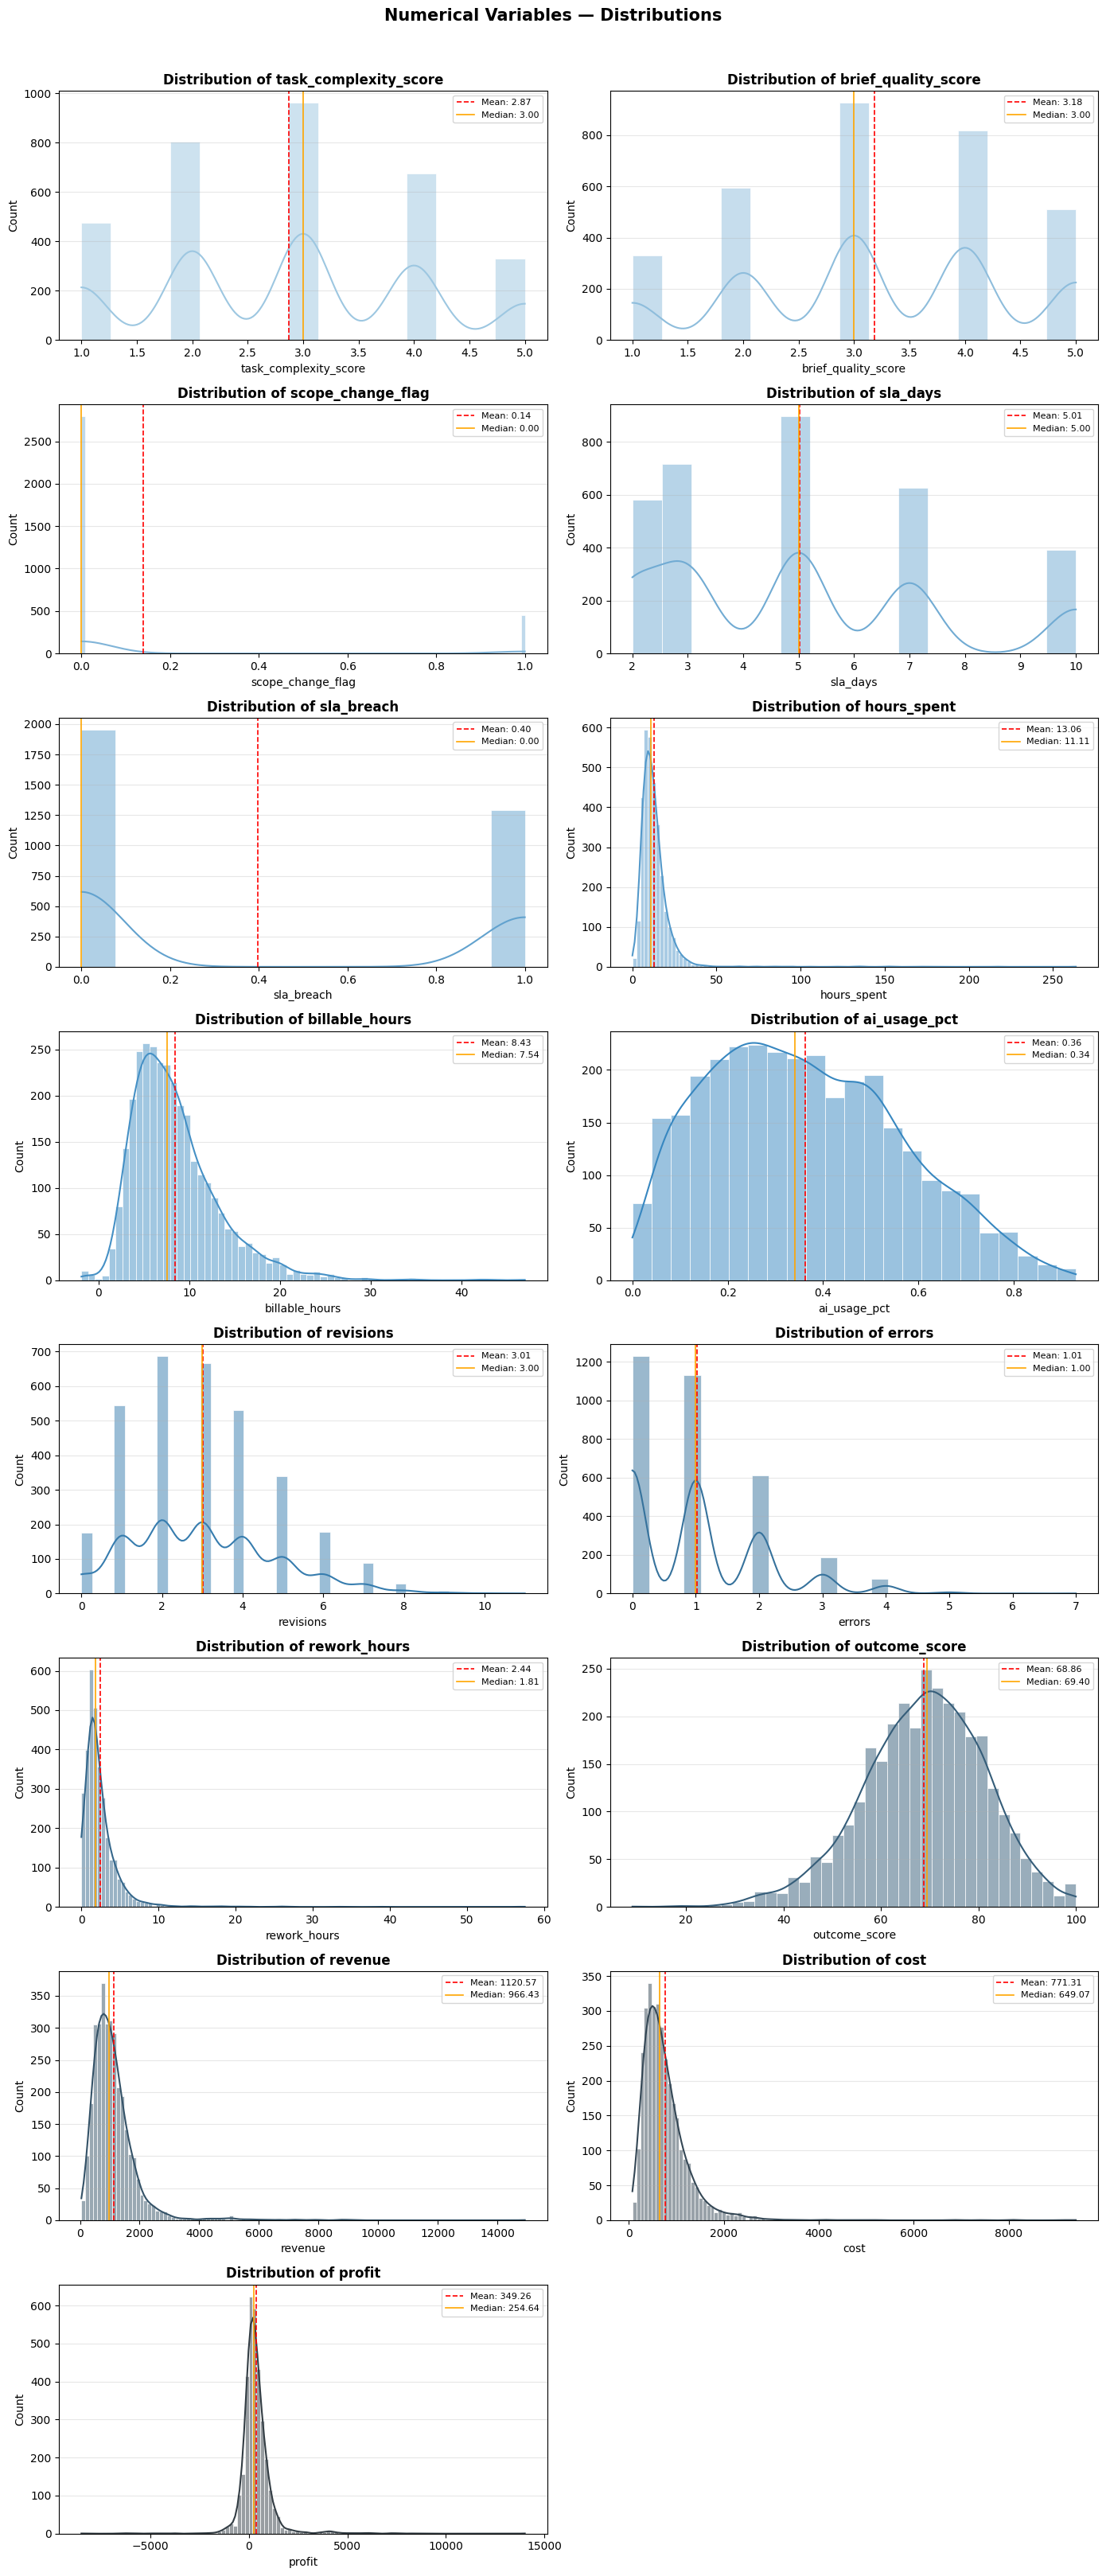

In [13]:
n_cols = 2
n_rows = (len(num_cols) + 1) // 2 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

palette = sns.color_palette("Blues_d", len(num_cols))  # Gradient palette

for i, col in enumerate(num_cols):
    ax = axes[i]
    
    sns.histplot(
        df_productivity[col],
        kde=True,
        color=palette[i],
        ax=ax,
        edgecolor='white',
        linewidth=0.5
    )
    
    # Vertical lines for mean and median
    mean_val = df_productivity[col].mean()
    median_val = df_productivity[col].median()
    ax.axvline(mean_val,   color='red',    linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='orange', linestyle='-',  linewidth=1.2, label=f'Median: {median_val:.2f}')
    
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

# Hide any unused axes (when len(num_cols) is odd)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Variables — Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()


#### 2) Categorical & Boolean Variables

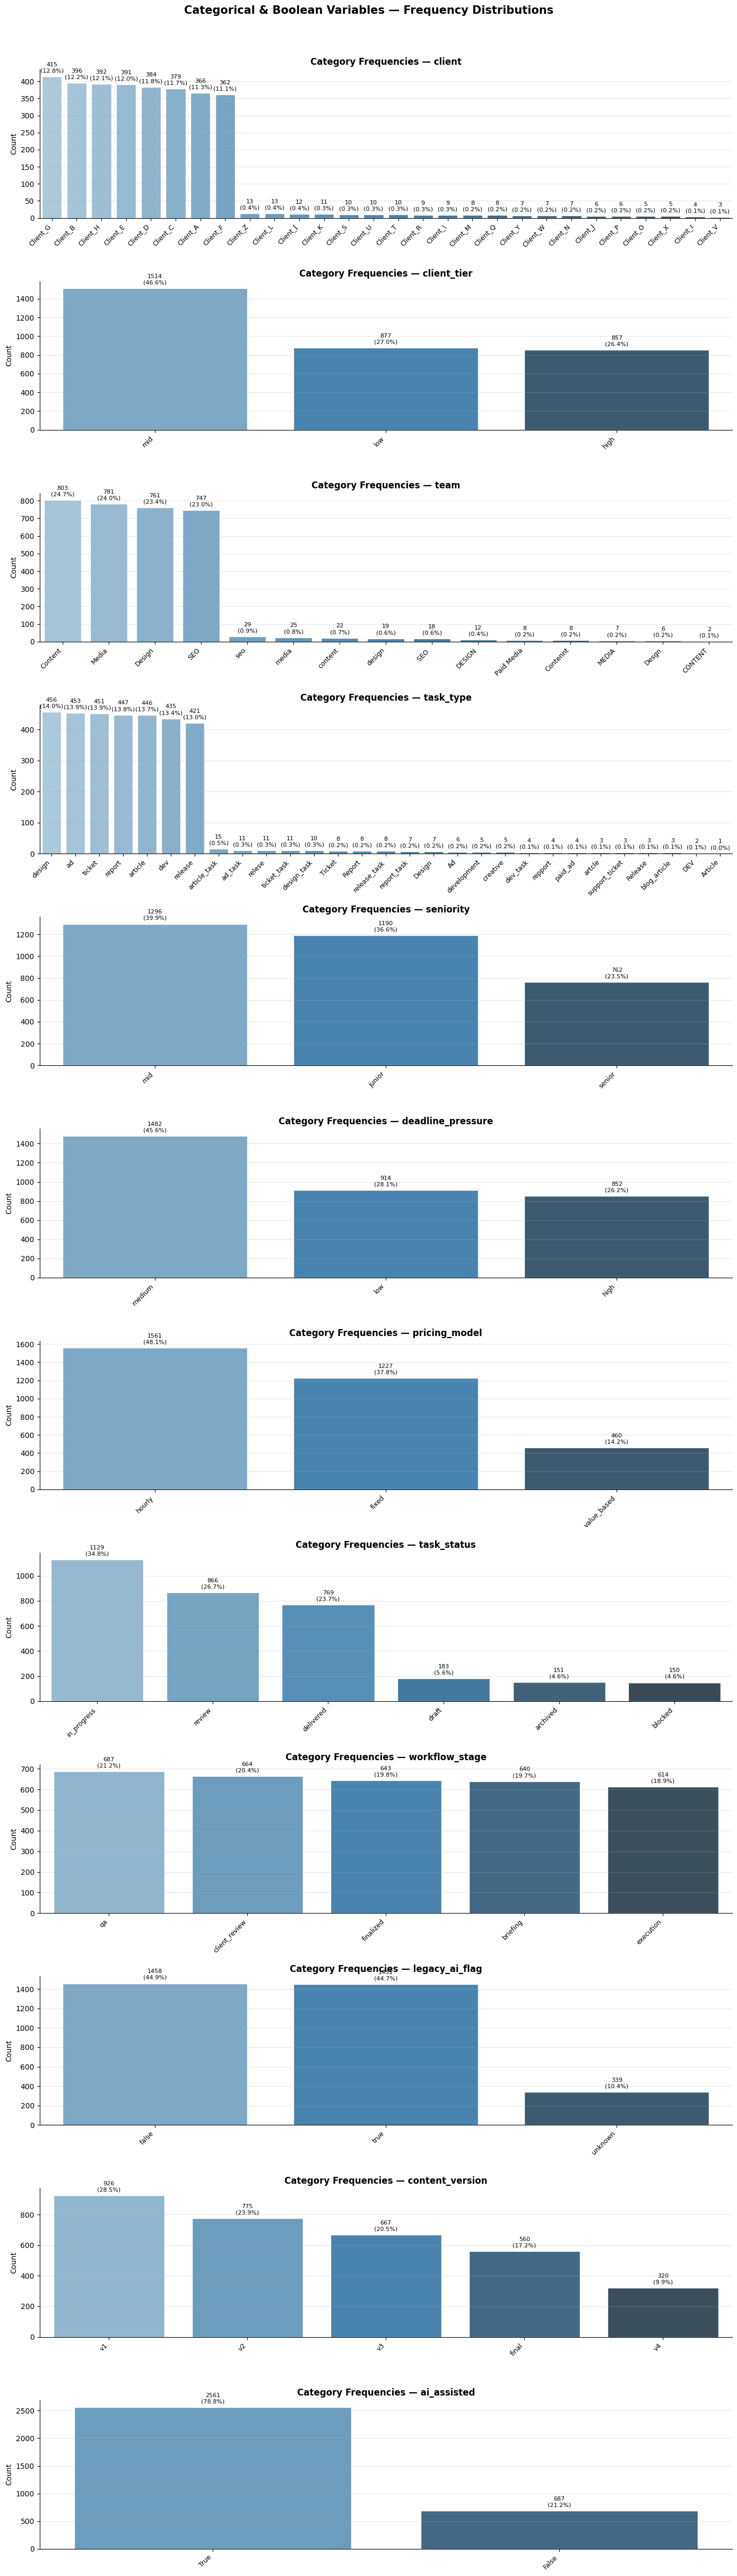

In [14]:
exclude_categories = ["task_id", "project_id", "created_at", "delivered_at", "created_by", "updated_at", "jira_ticket"]
cat_cols_filtered = [col for col in cat_cols if col not in exclude_categories]

cols_to_plot = cat_cols_filtered + bool_cols

fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(14, 4 * len(cols_to_plot)))
sns.despine()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]

    # Build counts
    counts = (
        df_productivity[col]
        .value_counts(dropna=True)          
        .reset_index()
    )

    # Plot as barplot 
    sns.barplot(
        data=counts,
        x=col,
        y='count',
        palette='Blues_d',
        order=counts[col],          # Sorted by frequency (value_counts output)
        ax=ax,
        edgecolor='white',
    )

    # Annotate each bar with count + percentage
    total = counts['count'].sum()
    for bar in ax.patches:
        height = bar.get_height()
        pct = height / total * 100
        ax.annotate(
            f'{int(height)}\n({pct:.1f}%)',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords='offset points',
            ha='center', va='bottom',
            fontsize=8
        )

    ax.set_title(f'Category Frequencies — {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count', fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.set_xticklabels(ax.get_xticklabels(), ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

# Hide any trailing empty axes 
for j in range(len(cols_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical & Boolean Variables — Frequency Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()


### Data Cleaning Summary (Duplicates & Feature Engineering)

Based on the execution of the previous sections, the following data preprocessing and cleaning steps were implemented to ensure consistency and reliability:

#### 1. Deduplication
We identified **48 duplicate observations** sharing the same `task_id`. To resolve this natively, the records were sorted by their `updated_at` timestamp, and the most recent entry was preserved (guaranteeing the latest task status is used). Post-processing confirmed that 0 duplicates remain.

#### 2. Normalization of the `team` and `task_type` Columns
Both columns contained inconsistent casing, formatting variants, and typos. We standardized text by stripping whitespace, lowercasing values, and applying explicit mapping dictionaries to consolidate variants into canonical labels.

For `team`, the cleaned output is exactly **4 categories** with a balanced distribution:
- **Content**: 827 tasks
- **Media**: 805 tasks
- **Design**: 790 tasks
- **SEO**: 778 tasks

For `task_type`, multiple variants (e.g., `ad_task`, `blog_article`, `support_ticket`) and typos (e.g., `artcle`, `relese`, `repport`) were merged into **7 canonical categories**:
- **Ad**
- **Article**
- **Design**
- **Development**
- **Release**
- **Report**
- **Ticket**

This normalization step ensures category consistency for downstream grouped analyses and segmented heatmaps.

#### 3. Date Parsing & Task Duration Calculation
The timestamps `created_at` and `delivered_at` were successfully cast to datetime objects (resulting in 0 missing values for creation dates and 38 `NaT` for delivery).
A new engineered feature, **`duration_days`**, was created to track end-to-end task time. During validity checks, **14 negative durations** were discovered, likely representing data entry errors or misaligned timestamps, and were appropriately replaced with `NaN`. The cleaned `duration_days` feature now correctly spans from 0 to 10 days, with a mean task duration of 4.5 days.

#### 4. Standardizing the `legacy_ai_flag`
This column originally consisted of lowercase, capitalized, and 'unknown' string values. It was standardized into a clean numeric format (1.0 for True, 0.0 for False). The 'unknown' flags were explicitly cast to `NaN` to reflect missing data accurately without skewing analyses. The final distribution shows a balanced historical split: 1,436 tasks categorized as False vs. 1,427 tasks as True (with 337 missing values).

#### 5. Creation of the `ai_indicator`
To further investigate the real adoption of AI, we engineered a binary feature `ai_indicator` based on whether `ai_usage_pct` was strictly greater than 0%. A distinct correlation check between this new indicator and the `legacy_ai_flag` revealed a correlation of **-0.014**, indicating virtually zero relationship. This unexpectedly implies that tasks flagged as historically using 'legacy' AI tools do not necessarily align with current, quantifiable AI engagement levels.

### Duplicates Check

In [15]:
duplicates = df_productivity.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [16]:
dup_count = df_productivity.duplicated(subset='task_id').sum()
print(f"Number of duplicates (task_id): {dup_count}")

Number of duplicates (task_id): 48


In [17]:
df_productivity['updated_at'] = pd.to_datetime(df_productivity['updated_at'])

df_productivity = (
    df_productivity
    .sort_values(['task_id', 'updated_at'])
    .groupby('task_id')
    .tail(1)
    .reset_index(drop=True)
)

In [18]:
dup_count = df_productivity.duplicated(subset='task_id').sum()
print(f"Number of duplicates (task_id): {dup_count}")

Number of duplicates (task_id): 0


#### Normalization of the "team" and "task_type" columns

In [19]:
# --- TEAM normalization ---
df_productivity['team'] = df_productivity['team'].str.strip()

print('Teams BEFORE:', sorted(df_productivity['team'].dropna().unique()))

df_productivity['team'] = df_productivity['team'].str.lower()

team_map = {
    'seo': 'SEO',
    'media': 'Media',
    'paid media': 'Media',
    'content': 'Content',
    'contennt': 'Content',
    'design': 'Design',
    'desgn': 'Design'
}

df_productivity['team'] = df_productivity['team'].replace(team_map)
print('Teams AFTER:', sorted(df_productivity['team'].dropna().unique()))

Teams BEFORE: ['CONTENT', 'Contennt', 'Content', 'DESIGN', 'Desgn', 'Design', 'MEDIA', 'Media', 'Paid Media', 'SEO', 'content', 'design', 'media', 'seo']
Teams AFTER: ['Content', 'Design', 'Media', 'SEO']


In [20]:
# --- TASK TYPE normalization ---
df_productivity['task_type'] = df_productivity['task_type'].str.strip()

print('\nTask types BEFORE:', sorted(df_productivity['task_type'].dropna().unique()))

df_productivity['task_type'] = (
    df_productivity['task_type']
    .str.lower()
    .str.replace(r'[_\-]+', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# Consolidate spelling variants and naming conventions into canonical categories
task_type_map = {
    'ad': 'Ad',
    'ad task': 'Ad',
    'adcopy': 'Ad',
    'ad copy': 'Ad',
    'paid ad': 'Ad',

    'article': 'Article',
    'article task': 'Article',
    'blog article': 'Article',
    'blogpost': 'Article',
    'blog post': 'Article',
    'artcle': 'Article',

    'design': 'Design',
    'design task': 'Design',
    'creative': 'Design',

    'dev': 'Development',
    'dev task': 'Development',
    'development': 'Development',

    'release': 'Release',
    'release task': 'Release',
    'relese': 'Release',

    'report': 'Report',
    'report task': 'Report',
    'repport': 'Report',

    'ticket': 'Ticket',
    'ticket task': 'Ticket',
    'support ticket': 'Ticket',

    'socialpost': 'Social Post',
    'social post': 'Social Post',
    'landingpage': 'Landing Page',
    'landing page': 'Landing Page',
    'emailcampaign': 'Email Campaign',
    'email campaign': 'Email Campaign'
}

df_productivity['task_type'] = df_productivity['task_type'].replace(task_type_map)
df_productivity['task_type'] = df_productivity['task_type'].str.title()

print('Task types AFTER:', sorted(df_productivity['task_type'].dropna().unique()))


Task types BEFORE: ['Ad', 'Article', 'DEV', 'Design', 'Release', 'Report', 'Ticket', 'ad', 'ad_task', 'artcle', 'article', 'article_task', 'blog_article', 'creative', 'design', 'design_task', 'dev', 'dev_task', 'development', 'paid_ad', 'release', 'release_task', 'relese', 'report', 'report_task', 'repport', 'support_ticket', 'ticket', 'ticket_task']
Task types AFTER: ['Ad', 'Article', 'Design', 'Development', 'Release', 'Report', 'Ticket']


In [21]:
print('\nTeam Distribution:')
display(df_productivity['team'].value_counts(dropna=False).to_frame())


Team Distribution:


,count
team,
Content,827
Media,805
Design,790
SEO,778


In [22]:
print('\nTask type Distribution:')
display(df_productivity['task_type'].value_counts(dropna=False).to_frame())


Task type Distribution:


,count
task_type,
Design,472
Ticket,469
Ad,466
Article,460
Report,459
Release,437
Development,437


#### Date Parsing

In [23]:
date_cols = ['created_at', 'delivered_at']
for col in date_cols:
    df_productivity[col] = pd.to_datetime(df_productivity[col], errors='coerce')
    n_nat = df_productivity[col].isna().sum()
    print(f"{col}: {n_nat} values NaT after the conversion")

# Creation of the column "duration_days"
df_productivity['duration_days'] = (
    df_productivity['delivered_at'] - df_productivity['created_at']
).dt.days

# Dealing with negative values of the "duration_days" column
mask_neg = df_productivity['duration_days'] < 0
neg_count = mask_neg.sum()
print(f"\nNegative durations found: {neg_count}")

print("\n-------")
print("Snapshot of the negative 'duration days' values:")

if neg_count > 0:
    print(f"\n{df_productivity.loc[mask_neg, ['task_id', 'created_at', 'delivered_at', 'duration_days']].head()}")
    df_productivity.loc[mask_neg, 'duration_days'] = np.nan

created_at: 0 values NaT after the conversion
delivered_at: 38 values NaT after the conversion

Negative durations found: 14

-------
Snapshot of the negative 'duration days' values:

     task_id created_at delivered_at  duration_days
89    T00089 2025-10-06   2025-10-05           -1.0
403   T00403 2026-02-09   2026-02-08           -1.0
878   T00878 2026-03-29   2026-03-26           -3.0
1083  T01083 2025-11-13   2025-11-12           -1.0
1112  T01112 2025-12-06   2025-12-05           -1.0


In [24]:
print("\nduration_days:")
display(df_productivity['duration_days'].describe().round(1).to_frame())


duration_days:


,duration_days
count,3148.0
mean,4.5
std,1.8
min,0.0
25%,3.0
50%,5.0
75%,6.0
max,10.0


#### Cleaning of the `legacy_ai_flag` column

In [25]:
print("Before cleaning:")
display(df_productivity['legacy_ai_flag'].value_counts(dropna=False).to_frame())

df_productivity['legacy_ai_flag'] = (
    df_productivity['legacy_ai_flag']
    .astype(str)
    .str.strip()
    .str.lower()
)
df_productivity['legacy_ai_flag'] = df_productivity['legacy_ai_flag'].replace('unknown', np.nan)

df_productivity['legacy_ai_flag'] = df_productivity['legacy_ai_flag'].map({
    'true': 1,
    'false': 0
})

print("\nAfter cleaning:")
display(df_productivity['legacy_ai_flag'].value_counts(dropna=False).to_frame())

Before cleaning:


,count
legacy_ai_flag,
false,1436
true,1427
unknown,337



After cleaning:


,count
legacy_ai_flag,
0.0,1436
1.0,1427
NaN,337


#### Creation of the column `ai_indicator`

In [26]:
ai_indicator = (df_productivity['ai_usage_pct'] > 0).astype(int)

correlation = ai_indicator.corr(df_productivity['legacy_ai_flag'])
print(f"\nCorrelation with AI usage indicator: {correlation:.3f}")


Correlation with AI usage indicator: -0.014


### Data Cleaning Summary (Missing Values)

Following the initial feature engineering, we directed our attention to analyzing and handling missing data across the dataset:

#### 1. Missing Value Analysis
We calculated the volume of missing values, observing that `legacy_ai_flag` (~10.5%) and `jira_ticket` (~10.3%) had the highest percentage of missingness. Other numerical features like `ai_usage_pct` (~4.5%) and `outcome_score` (~4.1%) also contained nulls. A missingno matrix was plotted to visually inspect the sparsity and ensure there were no critical monotone missing patterns.

#### 2. Visualizing Distributions
To determine robust imputation strategies, we plotted the exact distributions of task-oriented features (`profit`, `hours_spent`, `rework_hours`, `task_complexity_score`, etc.) for the subset of records where `ai_usage_pct` was missing. This confirmed the data was relatively uniform and allowed us to proceed with standard imputation techniques.

#### 3. Handling NaN Values (Imputation & Dropping)
To optimize the dataset for machine learning without introducing severe bias, the following treatments were applied to the missing records:
- **Dropped Column**: The `jira_ticket` column was dropped entirely. It functions solely as a unique text identifier, and given its high missing rate, it offers no predictive value for modeling.
- **Median Imputation**: For continuous and scoring metrics (`ai_usage_pct`, `outcome_score`, `brief_quality_score`, `sla_days`, `rework_hours`), we applied **median imputation** to fill the `NaN` values. Using the median ensures that the imputed data is robust and not skewed by extreme outliers.
- **Derived Imputation**: Missing values in `billable_hours` were filled using a logical heuristic based on recorded effort. Specifically, we set the missing billable hours to **85% of the `hours_spent`**, reflecting a realistic effective billing rate.

After this phase, the bulk of feature-level missing values were resolved, paving the way for outlier detection and handling.

#### Type Correction — Binary Flags
Two columns (`scope_change_flag` and `sla_breach`) are semantically boolean flags
but were loaded as integers. Converting them to `bool` ensures they are excluded
from numerical outlier analysis and treated correctly downstream.

#### Handling missing values

In [27]:
missing = df_productivity.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame(name= "Missing values"))

,Missing values
legacy_ai_flag,337
jira_ticket,331
ai_usage_pct,143
outcome_score,132
billable_hours,81
rework_hours,72
brief_quality_score,68
duration_days,52
delivered_at,38
sla_days,34


In [28]:
missing_pct = (df_productivity.isnull().sum() / len(df_productivity)) * 100
display(missing_pct.sort_values(ascending=False)[missing_pct > 0].to_frame(name="% Missing"))

,% Missing
legacy_ai_flag,10.53125
jira_ticket,10.34375
ai_usage_pct,4.46875
outcome_score,4.12500
billable_hours,2.53125
rework_hours,2.25000
brief_quality_score,2.12500
duration_days,1.62500
delivered_at,1.18750
sla_days,1.06250


<Axes: >

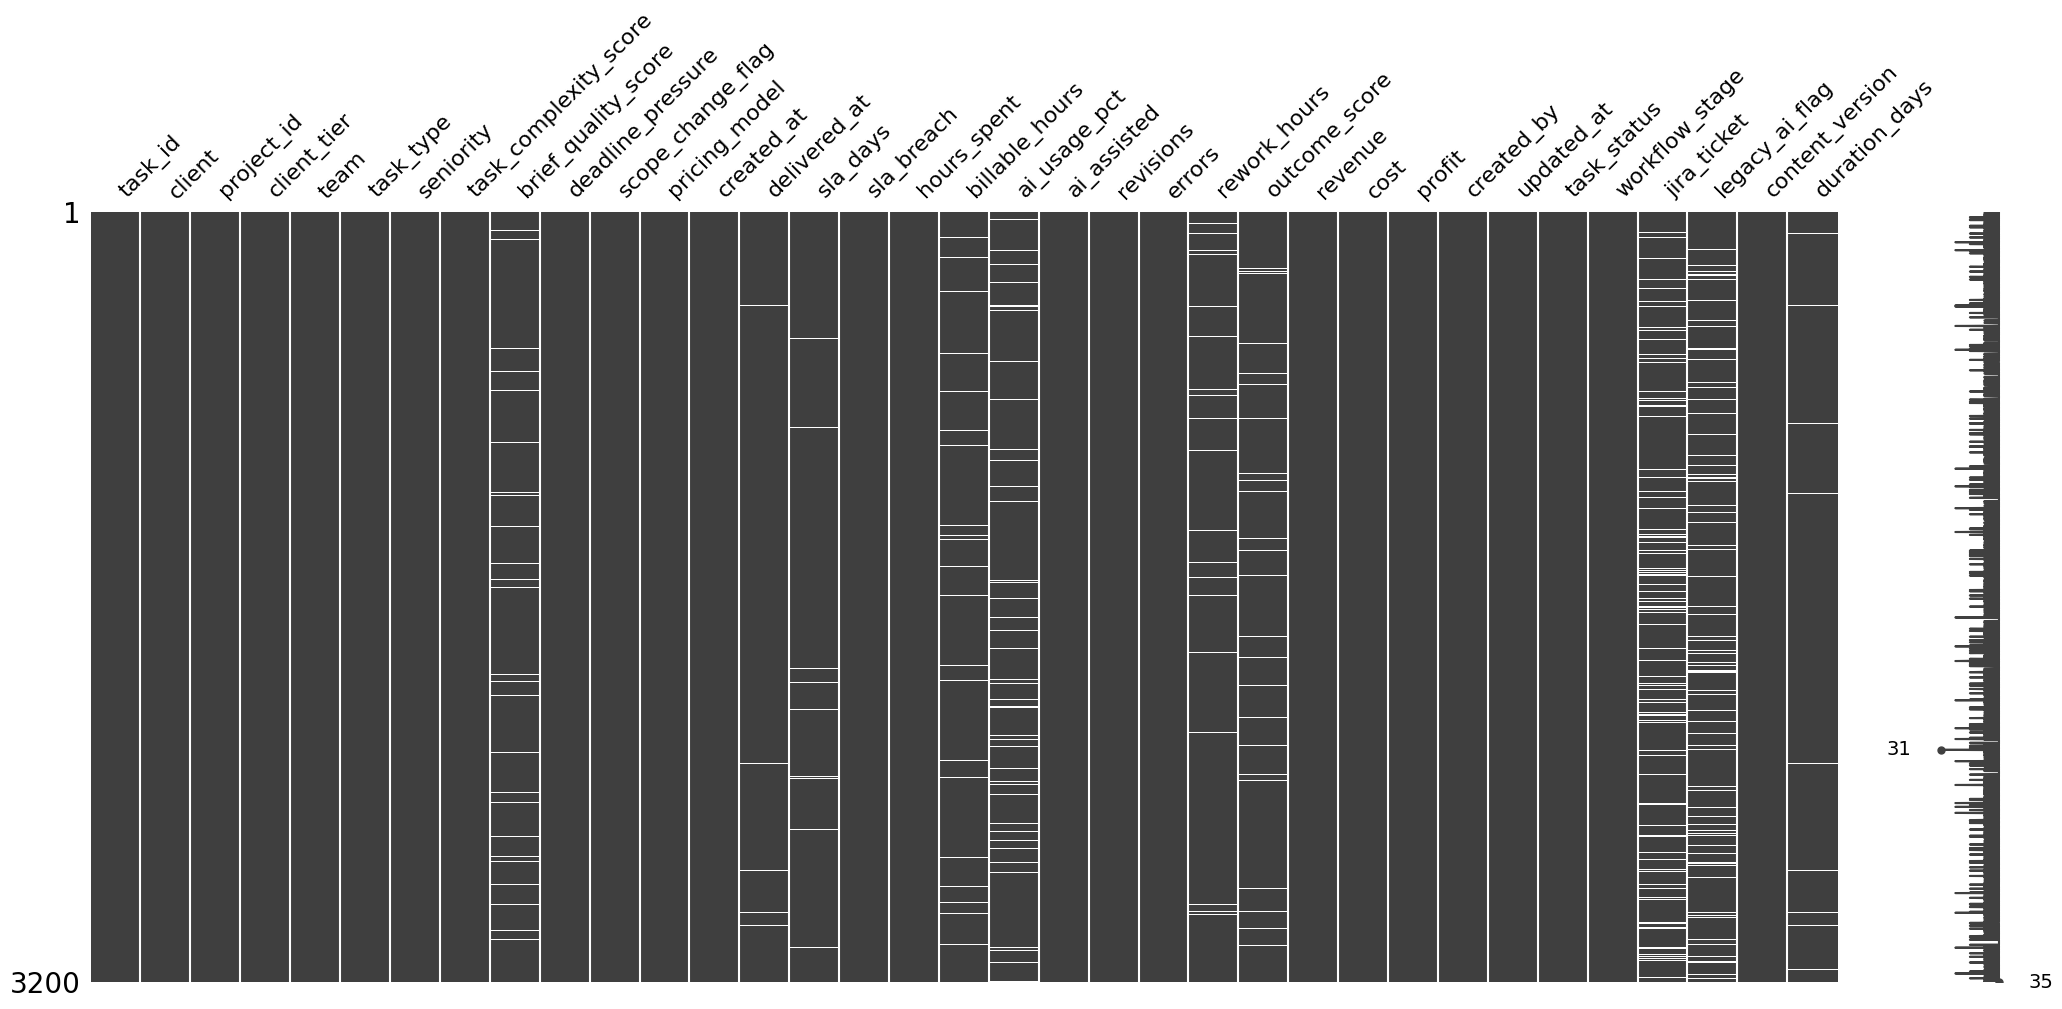

In [29]:
msno.matrix(df_productivity)

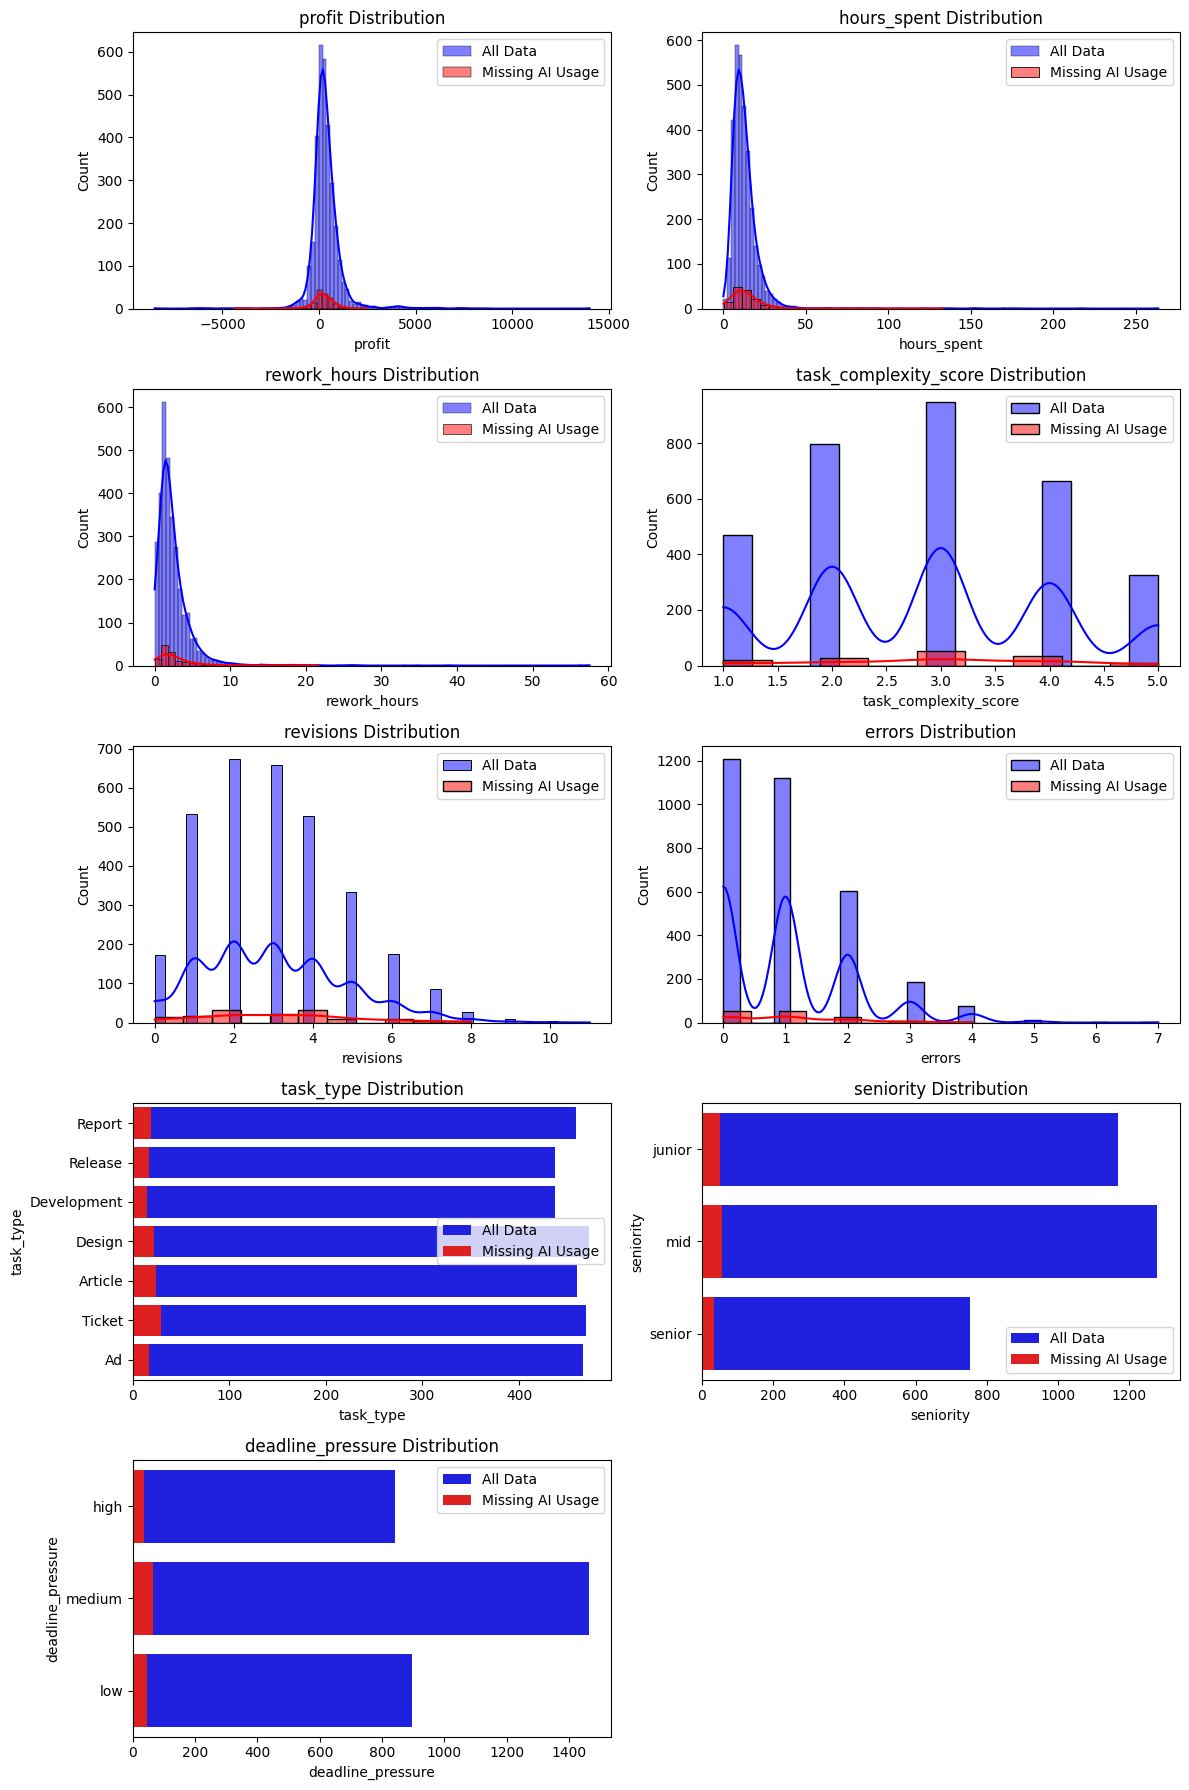

In [30]:
missing_ai_rows = df_productivity[df_productivity['ai_usage_pct'].isnull()]

columns = [
    'profit',
    'hours_spent',
    'rework_hours',
    'task_complexity_score',
    'revisions',
    'errors',
    'task_type',
    'seniority',
    'deadline_pressure'
]

fig, axes = plt.subplots(len(columns) // 2 + 1, 2, figsize=(12, 2 * len(columns)))
axes = axes.flatten()
for i, column in enumerate(columns):
    
    if column in df_productivity.select_dtypes(include=['int64', 'float64']).columns:
        sns.histplot(df_productivity[column], ax=axes[i], kde=True, color='blue', label='All Data')
        sns.histplot(missing_ai_rows[column], ax=axes[i], kde=True, color='red', label='Missing AI Usage')
    else:
        sns.countplot(data=df_productivity, y=column, ax=axes[i], color='blue', label='All Data')
        sns.countplot(data=missing_ai_rows, y=column, ax=axes[i], color='red', label='Missing AI Usage')
        
        axes[i].set_ylabel(column)
        axes[i].set_xlabel('Count')
    
    axes[i].set_title(f'{column} Distribution')
    axes[i].set_xlabel(column)
    axes[i].legend()

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()

#### Taking care of NaN values

In [31]:
df_productivity.loc[
    df_productivity['billable_hours'] < 0, 'billable_hours'
] = np.nan

In [32]:
df_productivity = df_productivity.drop(columns=['jira_ticket'], errors='ignore')

df_productivity['ai_usage_pct'] = df_productivity['ai_usage_pct'].fillna(
    df_productivity['ai_usage_pct'].median())

df_productivity['outcome_score'] = df_productivity['outcome_score'].fillna(
    df_productivity['outcome_score'].median())

df_productivity['brief_quality_score'] = df_productivity['brief_quality_score'].fillna(
    df_productivity['brief_quality_score'].median())

df_productivity['sla_days'] = df_productivity['sla_days'].fillna(
    df_productivity['sla_days'].median())

mask = df_productivity['billable_hours'].isna()
df_productivity.loc[mask, 'billable_hours'] = (
    df_productivity.loc[mask, 'hours_spent'] * 0.85)

df_productivity['rework_hours'] = df_productivity['rework_hours'].fillna(
    df_productivity['rework_hours'].median())

remaining = df_productivity.isnull().sum()
remaining = remaining[remaining > 0]

print("\nRemaining missing values:")
print(remaining)


Remaining missing values:
delivered_at       38
legacy_ai_flag    337
duration_days      52
dtype: int64


In [33]:
df_productivity['scope_change_flag'] = df_productivity['scope_change_flag'].astype(bool)
df_productivity['sla_breach'] = df_productivity['sla_breach'].astype(bool)

# Verify
print(df_productivity[['scope_change_flag', 'sla_breach']].dtypes)
display(df_productivity["scope_change_flag"].value_counts().to_frame())
display(df_productivity["sla_breach"].value_counts().to_frame())


scope_change_flag    bool
sla_breach           bool
dtype: object


,count
scope_change_flag,
False,2757
True,443


,count
sla_breach,
False,1929
True,1271


In [34]:
# Re-define num_cols
num_cols = [col for col in df_productivity.select_dtypes(include=['int64', 'float64']).columns if col != 'legacy_ai_flag']

# We have to exclude the column "legacy_ai_flag" now because after we standardized it, ir counts as a numeric column even if it shouldn't.

### Outlier Analysis

After handling the missing values in the dataset, we turned our attention to identifying and treating extreme values in the numerical variables. The analysis was carried out in three stages.
#### 1. Visual Inspection via Boxplots
All 13 genuinely numerical columns were plotted as boxplots **before any transformation**, providing a first visual assessment of the distributional spread and the presence of extreme values.
#### Outlier Treatment: Decision not to cap
After visual inspection of the boxplots and IQR-based detection, we decided **not to apply winsorization** to any variable. The IQR × 3 rule flags statistically extreme values, but statistical extremity is not the same as an error. In this dataset:
- `hours_spent` reaches 263 hours: long tasks are real and analytically relevant. Capping them would systematically exclude the most complex tasks from the analysis, introducing selection bias.
- `revenue` reaches €14,927: large contracts are real business cases, not data entry errors. Removing them would bias the analysis toward average-sized tasks and underrepresent the high-margin segment.
- `rework_hours` reaches 57 hours: while high, this is plausible for tasks with severe quality issues, which are precisely the cases most relevant to our research question.
- `profit` ranges from €8,510 to +€14,006: the company confirmed that revenue and cost are estimated figures. This means the uncertainty is distributed across the entire dataset, not concentrated in the extremes. Capping the extremes while leaving the rest unchanged would be arbitrary.

For these reasons, we retain all observations as-is and rely on robust statistical methods downstream, specifically Spearman correlation (which is rank-based and less sensitive to extremes) and median-based imputation,rather than removing information from the dataset.

#### Check for outliers

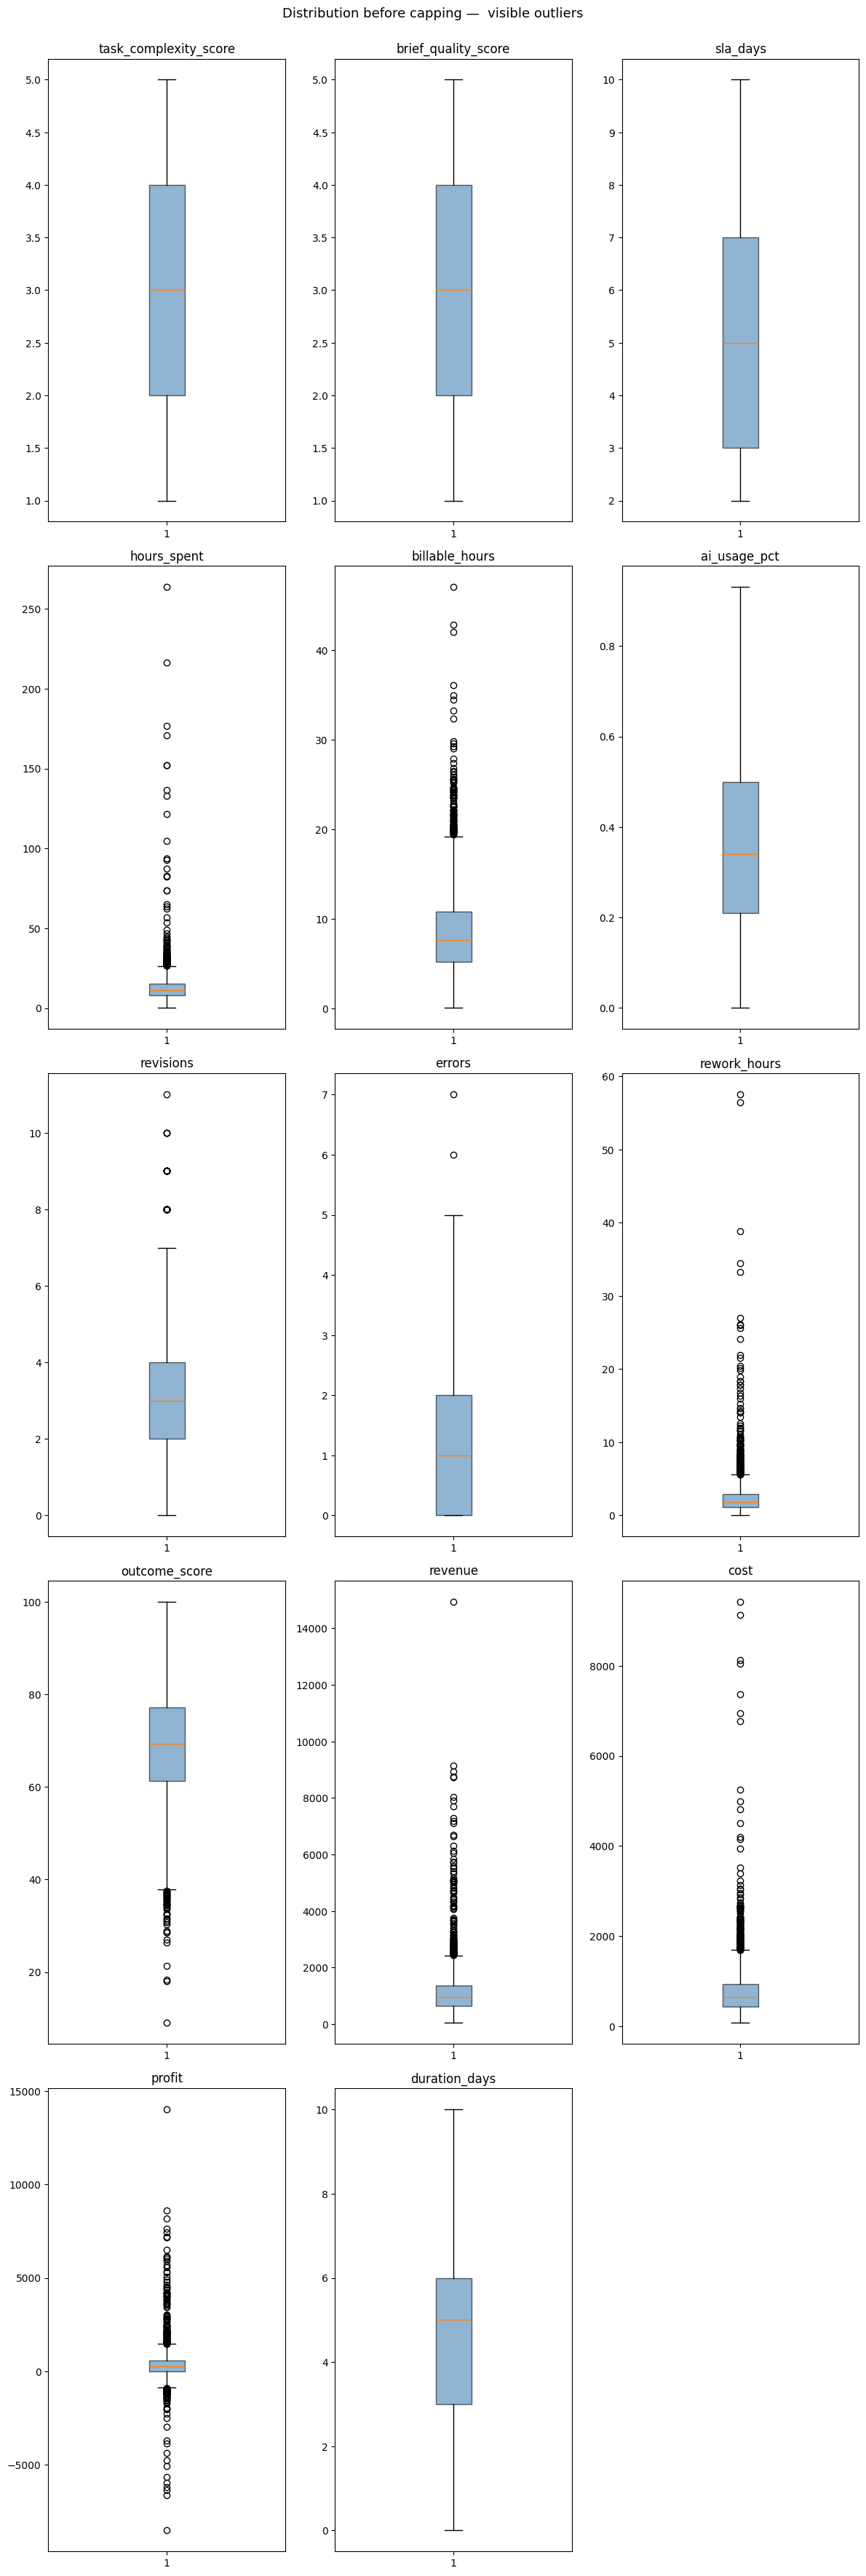

In [35]:
fig, axes = plt.subplots(len(num_cols) // 2 + 1, 3, figsize=(12, 4*len(num_cols)))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df_productivity[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
    
plt.suptitle('Distribution before capping —  visible outliers', fontsize=13, y = 1.0001)
plt.tight_layout()

In [36]:
outlier_summary = []

for col in num_cols:
    Q1 = df_productivity[col].quantile(0.25)
    Q3 = df_productivity[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculate 3x IQR bounds
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    
    n_out = ((df_productivity[col] < lower) | (df_productivity[col] > upper)).sum()
    pct = (n_out / len(df_productivity)) * 100
    
    # Append the results as a new row
    outlier_summary.append({
        'Feature': col,
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Outlier Count': n_out,
        '% Outliers': pct
    })

# Convert to DataFrame
df_outliers = pd.DataFrame(outlier_summary)

# Display with clean formatting (rounds numbers and adds % sign)
display(df_outliers.style.hide(axis='index').format({
    'Lower Bound': '{:.2f}',
    'Upper Bound': '{:.2f}',
    '% Outliers': '{:.1f}%'
}).set_caption("Extreme Outliers (3 × IQR)"))

Feature,Lower Bound,Upper Bound,Outlier Count,% Outliers
task_complexity_score,-4.00,10.00,0,0.0%
brief_quality_score,-4.00,10.00,0,0.0%
sla_days,-9.00,19.00,0,0.0%
hours_spent,-14.37,37.59,38,1.2%
billable_hours,-11.87,27.82,13,0.4%
ai_usage_pct,-0.66,1.37,0,0.0%
revisions,-4.00,10.00,1,0.0%
errors,-6.00,8.00,0,0.0%
rework_hours,-4.28,8.32,71,2.2%
outcome_score,13.81,124.78,1,0.0%


### Correlation Analysis

After handling missing values and deciding not to cap outliers, we explored the linear and monotonic relationships between the 13 genuinely numerical features using two complementary methods. `scope_change_flag` and `sla_breach` were excluded because they are binary flags. Their dtype was already converted to `bool` in the cleaning phase, so they no longer appear in `select_dtypes(include=[np.number])`.

#### Why Two Methods?
- **Pearson** measures *linear* correlations: it assumes the relationship between two variables is a straight line.
- **Spearman** measures *monotonic* (rank-based) correlations: it captures non-linear relationships and is not influenced by outliers. It is the most robust method for this dataset, which contains extreme values that we chose not to cap.

Using both heatmaps together allows us to distinguish genuine associations from artifacts caused by skewed distributions.

---

#### Key Findings: Pearson

| Pair | Pearson r | Interpretation |
|--------|-----------|-----------------|
| `revenue` ↔ `profit` | **+0.77** | Strong: profit scales with revenue (expected) |
| `billable_hours` ↔ `cost` | **+0.55** | Billable hours drive total cost |
| `billable_hours` ↔ `hours_spent` | **+0.47** | Most worked hours are billable |
| `errors` ↔ `outcome_score` | **−0.47** | More errors → significantly lower perceived quality |
| `cost` ↔ `profit` | **−0.41** | For a given revenue, high costs squeeze the margin |
| `brief_quality_score` ↔ `outcome_score` | **+0.34** | Better briefs produce higher quality output |

Pairs involving `ai_usage_pct` show weak correlations with `profit` (r = +0.11), `rework_hours` (r = +0.12), and `outcome_score` (r = −0.02). This does not mean AI is irrelevant: it means its effect is **not linear** — an hypothesis that will be tested in the threshold analysis (Phase 5).

---

#### Key Findings: Spearman

| Pair | Spearman ρ | Interpretation |
|--------|------------|-----------------|
| `billable_hours` ↔ `hours_spent` | **+0.84** | Near-perfect relationship: confirms linearity |
| `cost` ↔ `hours_spent` | **+0.81** | Cost is primarily driven by hours worked |
| `billable_hours` ↔ `cost` | **+0.72** | Consistent with Pearson |
| `revenue` ↔ `profit` | **+0.66** | Stronger than Pearson → partially non-linear relationship |
| `errors` ↔ `outcome_score` | **−0.45** | Confirms Pearson finding — robust to outliers |
| `brief_quality_score` ↔ `rework_hours` | **−0.35** | **Relevant finding**: low-quality briefs → more rework hours |

Spearman is consistently higher than Pearson for pairs involving `hours_spent`, `cost`, and `revenue` — a sign that the skewed distributions of these values attenuated the linear correlation. The rank-based method captures them better.

---

#### Implications for the Research Question

The correlation between `ai_usage_pct` and the outcome variables (`profit`, `rework_hours`, `outcome_score`) is weak **at a linear and global level**. This result is expected and not contradictory: a threshold effect is by definition non-linear — it only appears when segmenting by usage tiers. The threshold analysis in the subsequent phases is therefore motivated by this very finding.

#### Correlation

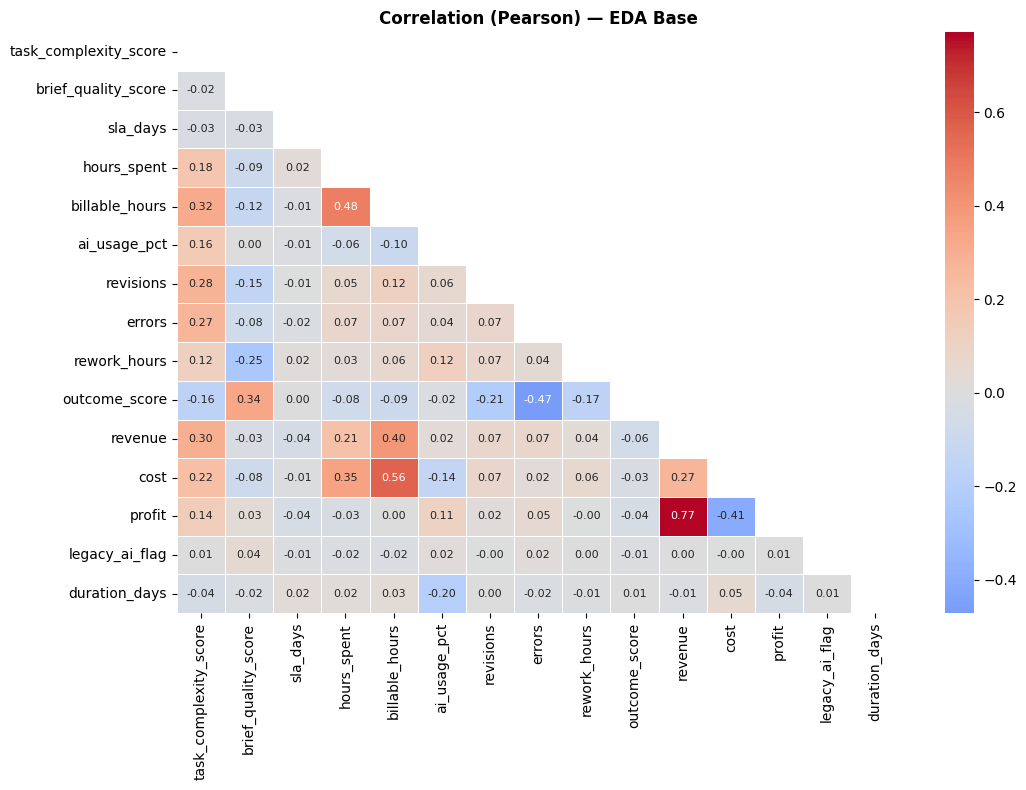

In [37]:
numeric = df_productivity.select_dtypes(include=[np.number])
exclude = ['scope_change_flag', 'sla_breach']
numeric = numeric.drop(columns=[c for c in exclude if c in numeric.columns])

corr = numeric.corr(method='pearson')
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4,
            annot_kws={'size': 8})

plt.title('Correlation (Pearson) — EDA Base', fontweight='bold')
plt.tight_layout()

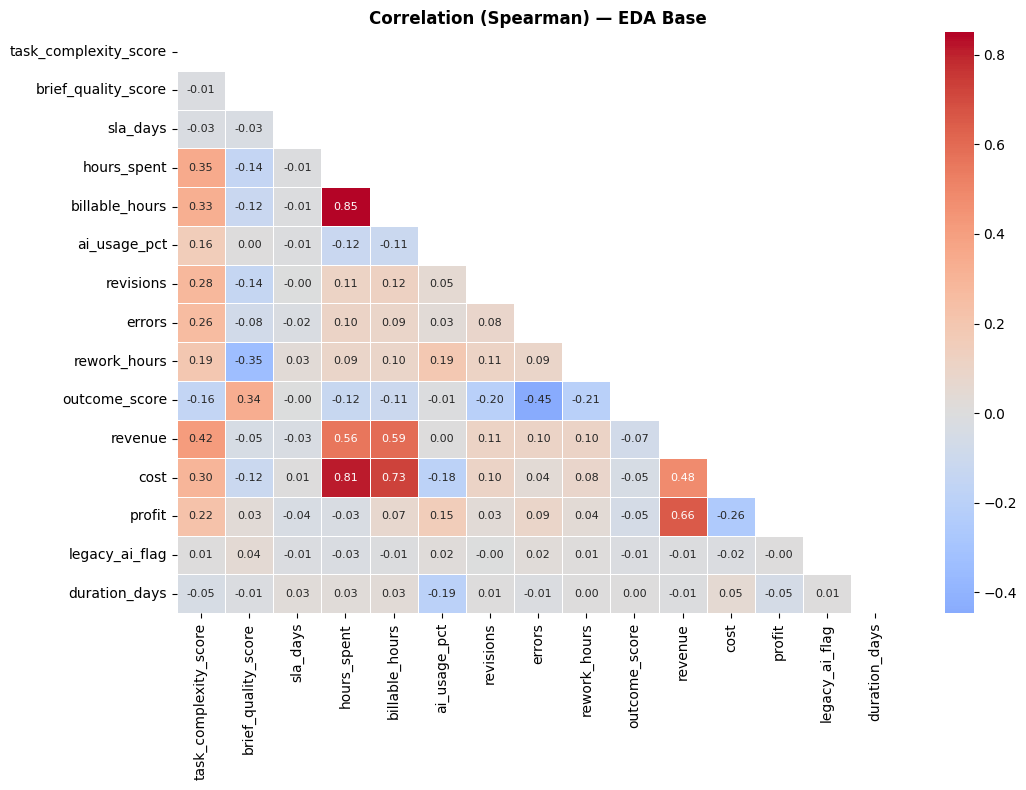

In [38]:
numeric = df_productivity.select_dtypes(include=[np.number])
exclude = ['scope_change_flag', 'sla_breach']
numeric = numeric.drop(columns=[c for c in exclude if c in numeric.columns])

corr = numeric.corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4,
            annot_kws={'size': 8})

plt.title('Correlation (Spearman) — EDA Base', fontweight='bold')
plt.tight_layout()

## `Feature Engineering`

### Feature Engineering: Motivation and Created Variables

In this phase, we construct new variables from the already cleaned original data. The goal is to transform raw data into metrics that directly answer the research question: *beyond what threshold of AI usage does rework destroy the profit margin?*

The original variables (e.g., `profit`, `revenue`, `hours_spent`) are kept intact, they are neither capped nor modified, because they represent real business values. The new features are all **derived** variables calculated from the cleaned dataset.

The created features are:

| # | Variable | Formula | Motivation |
|---|-----------|---------|-------------|
| 1 | `profit_margin` | `profit / revenue × 100` | Normalized margin, comparable across tasks of different sizes |
| 2 | `ai_flag` | `ai_usage_pct > 0` → 0/1 | Distinguishes tasks with and without AI, for binary baseline comparisons |
| 3 | `rework_rate` | `rework_hours / hours_spent` | Proportion of wasted time (the primary hidden cost) |
| 4 | `error_rate` | `errors / hours_spent` | Error density per worked hour |
| 5 | `billable_ratio` | `billable_hours / hours_spent` | Share of work recovered as revenue |
| 6 | `revenue_per_hour` | `revenue / hours_spent` | Hourly revenue efficiency |
| 7 | `cost_per_hour` | `cost / hours_spent` | Hourly cost intensity |
| 8 | `ai_usage_sq` | `ai_usage_pct²` | Quadratic term to capture non-linear effects of AI on the margin |
| 9 | `rework_cost_est` | `rework_hours × median(cost_per_hour)` | Monetary estimate of the rework cost in € |
| 10 | `hidden_cost_ratio` | `rework_cost_est / cost` | Proportion of total cost attributable to rework |
| 11 | `ai_bucket` | bins of `ai_usage_pct` in five 20% intervals | Ordinal grouping for threshold analysis |
| 12 | `is_high_ai` | `ai_usage_pct >= 0.6` → 0/1 | Binary flag for tasks with high AI usage (threshold ≥ 60%) |
| 13 | `budget_bucket` | median of `revenue` → low/high | Segmentation by the economic size of the task |
| 14 | `profit_bucket` | median of `profit` → low/high | Segmentation by task profitability |
| 15 | `complexity_bucket` | tertiles of `task_complexity_score` | Segmentation by operational complexity level |

> **Technical note on ratios:** To avoid division by zero or extreme values caused by tasks with very few logged hours (e.g., 0.02h due to logging errors), the denominator `hours_spent` is clipped to a minimum of 0.1h before calculating all ratios. This does not alter the real values, it applies only to the 0.02% of cases with anomalous hours.

---

### Feature Engineering: Summary

The final dataframe now contains **34 original columns + 15 engineered features** for a total of 49 columns. The most relevant features for the threshold analysis in subsequent phases are:
* `profit_margin`: primary target variable
* `rework_rate` and `rework_cost_est`: mechanism of damage
* `ai_bucket` and `is_high_ai`: AI segmentation variables
* `hidden_cost_ratio`: hidden cost as a percentage of total cost

In [39]:
# -------------------------------------------------------------------
# NOTE: Negative billable_hours are set to NaN BEFORE using this column in ratios. Negative values are logging errors, not real values. 
# This operation happens here and not in the cleaning phase because the column was already imputed in the previous phase.
# -------------------------------------------------------------------

# 1 - Percentage profit margin
df_productivity['profit_margin'] = (
    df_productivity['profit'] / df_productivity['revenue'].replace(0, np.nan)
) * 100

# 2 - Binary flag: did the task use AI?
df_productivity['ai_flag'] = (df_productivity['ai_usage_pct'] > 0).astype(int)

# 3 - Hour-based ratios: using hours_safe to prevent division by near-zero values caused by logging errors (min = 0.1h)
min_hours = 0.1
hours_safe = df_productivity['hours_spent'].clip(lower=min_hours)

df_productivity['rework_rate'] = df_productivity['rework_hours'] / hours_safe
df_productivity['error_rate'] = df_productivity['errors'] / hours_safe
df_productivity['billable_ratio'] = df_productivity['billable_hours'] / hours_safe
df_productivity['revenue_per_hour'] = df_productivity['revenue'] / hours_safe
df_productivity['cost_per_hour'] = df_productivity['cost'] / hours_safe

# 4 - Quadratic term of ai_usage_pct (captures non-linear relationships)
df_productivity['ai_usage_sq'] = df_productivity['ai_usage_pct'] ** 2

# 5 - Monetary estimate of rework cost
# Using the median of cost_per_hour as a proxy for the company's hourly cost
median_cph = df_productivity['cost_per_hour'].median()
df_productivity['rework_cost_est'] = df_productivity['rework_hours'] * median_cph
df_productivity['hidden_cost_ratio'] = (
    df_productivity['rework_cost_est'] / df_productivity['cost'].replace(0, np.nan)
)
print(f"Median cost/hour used for rework_cost_est: €{median_cph:.2f}")

# 6 - AI segmentation into 5 buckets of 20% each
bins   = [0, 0.20, 0.40, 0.60, 0.80, 1.01]
labels = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
df_productivity['ai_bucket'] = pd.cut(
    df_productivity['ai_usage_pct'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# 7 - Binary flag: high AI usage (>= 60%)
df_productivity['is_high_ai'] = (df_productivity['ai_usage_pct'] >= 0.6).astype(int)

# 8 - Segmentation by economic size and complexity
df_productivity['budget_bucket'] = pd.qcut(
    df_productivity['revenue'], q=2,
    labels=['low_budget', 'high_budget']
)
df_productivity['profit_bucket'] = pd.qcut(
    df_productivity['profit'], q=2,
    labels=['low_profit', 'high_profit']
)
df_productivity['complexity_bucket'] = pd.qcut(
    df_productivity['task_complexity_score'], q=3,
    labels=['low', 'medium', 'high']
)

# 9 - Final check: print the newly created columns
new_features = [
    'profit_margin', 'ai_flag', 'rework_rate', 'error_rate',
    'billable_ratio', 'revenue_per_hour', 'cost_per_hour',
    'ai_usage_sq', 'rework_cost_est', 'hidden_cost_ratio',
    'ai_bucket', 'is_high_ai', 'budget_bucket', 'profit_bucket',
    'complexity_bucket'
]
print(f"\nFeatures created: {len(new_features)}")
print(f"Final dataframe shape: {df_productivity.shape}")
print("\nNon-null values for each new feature:")
display(df_productivity[new_features].notna().sum().to_frame(name='non-null count'))

Median cost/hour used for rework_cost_est: €58.07

Features created: 15
Final dataframe shape: (3200, 49)

Non-null values for each new feature:


,non-null count
profit_margin,3200
ai_flag,3200
rework_rate,3200
error_rate,3200
billable_ratio,3200
revenue_per_hour,3200
cost_per_hour,3200
ai_usage_sq,3200
rework_cost_est,3200
hidden_cost_ratio,3200


## `Advanced EDA`

### Analytical Strategy

The feature engineering phase produced all the variables needed to investigate the core research question: *beyond what threshold of AI usage does rework begin to erode profit margin performance?*

This section tests that question through a structured chain of analyses:

**AI -> Performance and Rework**
We first examine how `profit_margin` and `rework_rate` change across the five `ai_bucket` tiers (0-20%, 20-40%, 40-60%, 60-80%, 80-100%). A LOWESS smoother is then applied to the raw AI-profit relationship to reveal non-linear patterns without imposing a rigid functional form.

**Mechanism Checks**
We verify whether higher rework and hidden costs are associated with lower profitability through dedicated mechanism plots (`rework -> profit` and `hidden cost -> profit`).

**Segmentation**
We break the AI-margin relationship down by `budget_bucket` and `complexity_bucket` to test whether the pattern is uniform or concentrated in specific contexts.

**Threshold Readout in Two Steps**
We first report a clean levels table (median `profit_margin`, `rework_rate`, `hidden_cost_ratio`, and `hours_spent` by `ai_bucket`).
We then compute **marginal effects** (`profit_diff`, `rework_diff`, `hidden_diff`) to identify where gains peak and where cost pressure accelerates.

> All line plots use **median** as the estimator (rather than mean) because `profit_margin` is right-skewed, and the mean is sensitive to extreme values retained in the dataset.

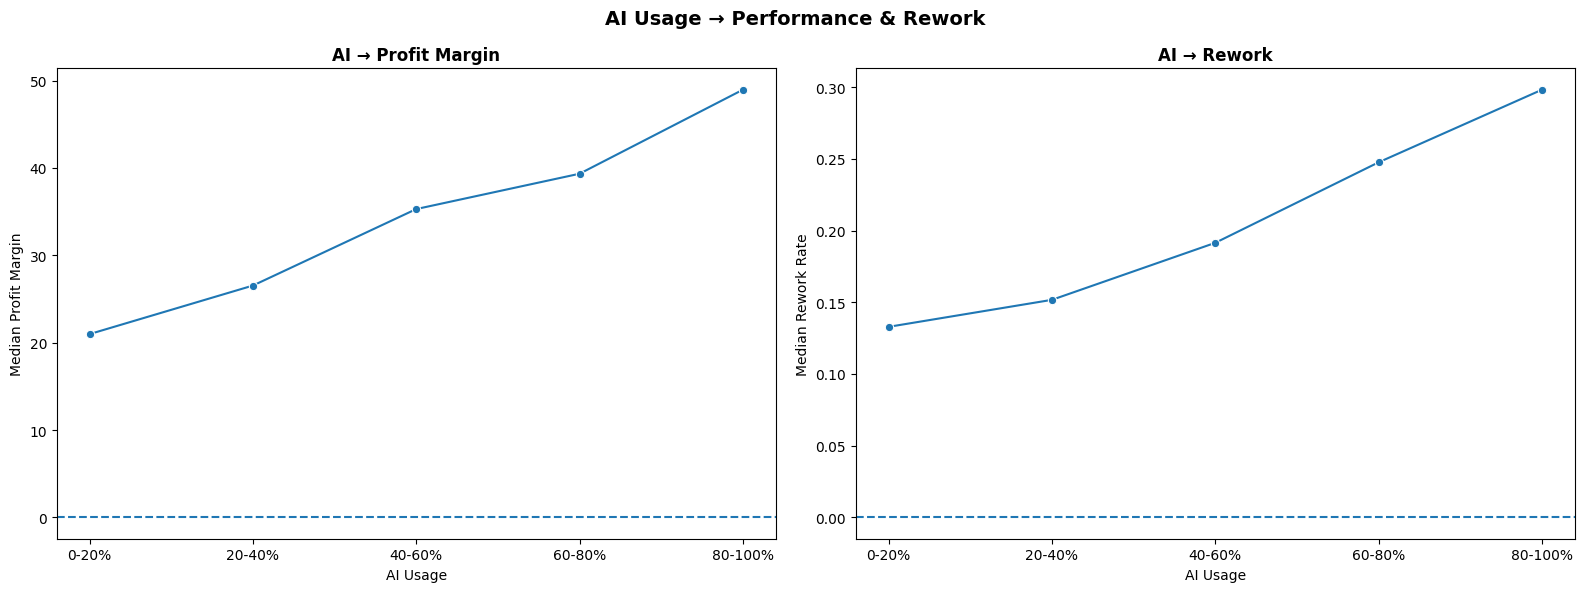

In [40]:
# ── 1. AI → Performance & Rework ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('AI Usage → Performance & Rework', fontsize=14, fontweight='bold')

sns.lineplot(data=df_productivity, x='ai_bucket', y='profit_margin',
             estimator='median', errorbar=None, marker='o', ax=axes[0])
axes[0].axhline(0, linestyle='--')
axes[0].set_title('AI → Profit Margin', fontweight='bold')
axes[0].set_xlabel('AI Usage')
axes[0].set_ylabel('Median Profit Margin')

sns.lineplot(data=df_productivity, x='ai_bucket', y='rework_rate',
             estimator='median', errorbar=None, marker='o', ax=axes[1])
axes[1].axhline(0, linestyle='--')
axes[1].set_title('AI → Rework', fontweight='bold')
axes[1].set_xlabel('AI Usage')
axes[1].set_ylabel('Median Rework Rate')

plt.tight_layout()

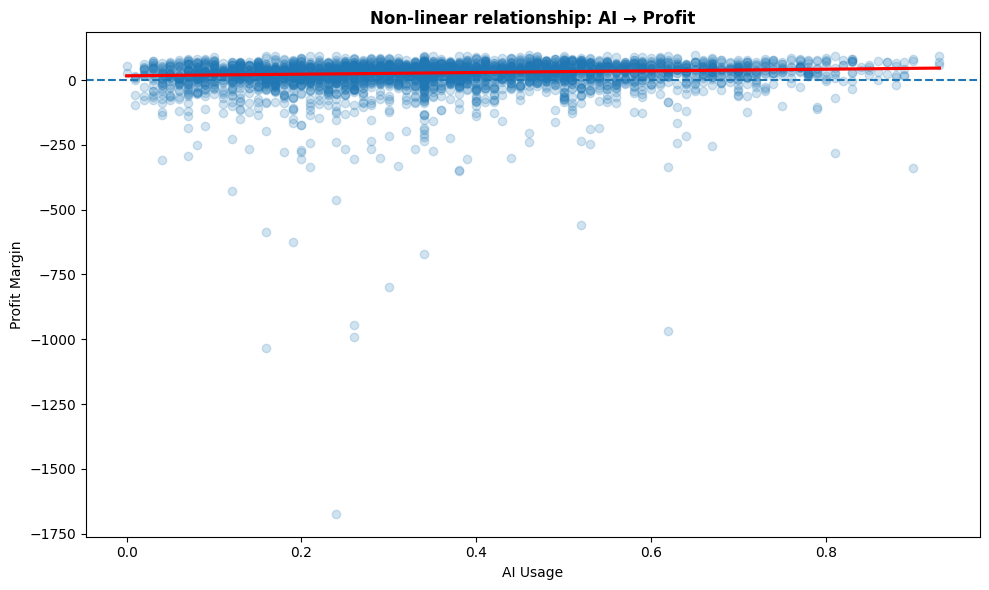

In [41]:
# ── 2. Non-linearity (LOWESS) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=df_productivity, x='ai_usage_pct', y='profit_margin',
            lowess=True,
            scatter_kws={'alpha': 0.2},
            line_kws={'color': 'red'},
            ax=ax)
ax.axhline(0, linestyle='--')
ax.set_title('Non-linear relationship: AI → Profit', fontweight='bold')
ax.set_xlabel('AI Usage')
ax.set_ylabel('Profit Margin')
plt.tight_layout()

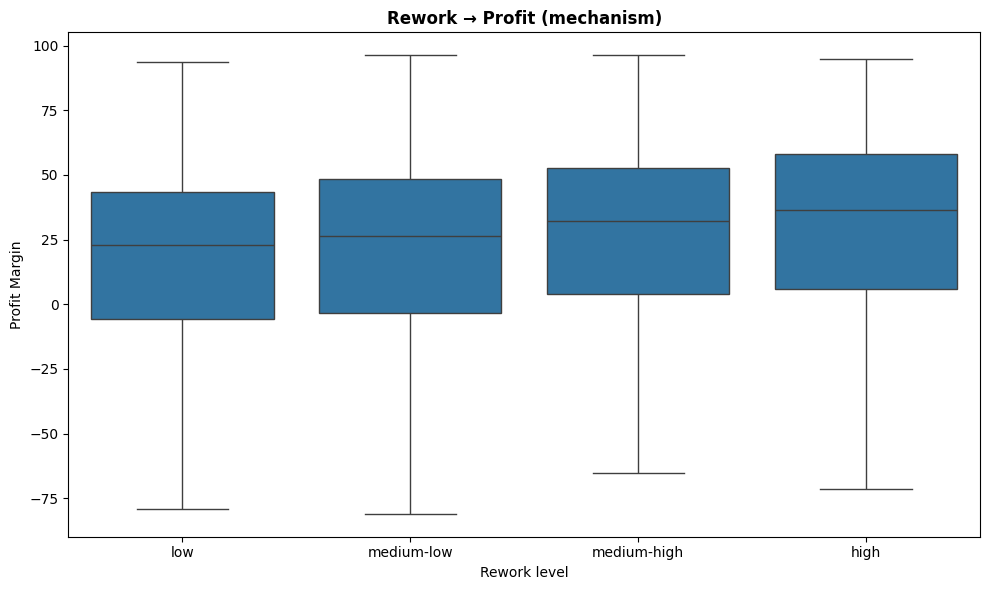

In [42]:
# ── 3. Rework → Profit (core mechanism) ──────────────────────
if 'rework_bin' not in df_productivity.columns:
    df_productivity['rework_bin'] = pd.qcut(
        df_productivity['rework_rate'], q=4,
        labels=['low', 'medium-low', 'medium-high', 'high']
    )

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_productivity, x='rework_bin', y='profit_margin',
            showfliers=False, ax=ax)
ax.set_title('Rework → Profit (mechanism)', fontweight='bold')
ax.set_xlabel('Rework level')
ax.set_ylabel('Profit Margin')
plt.tight_layout()

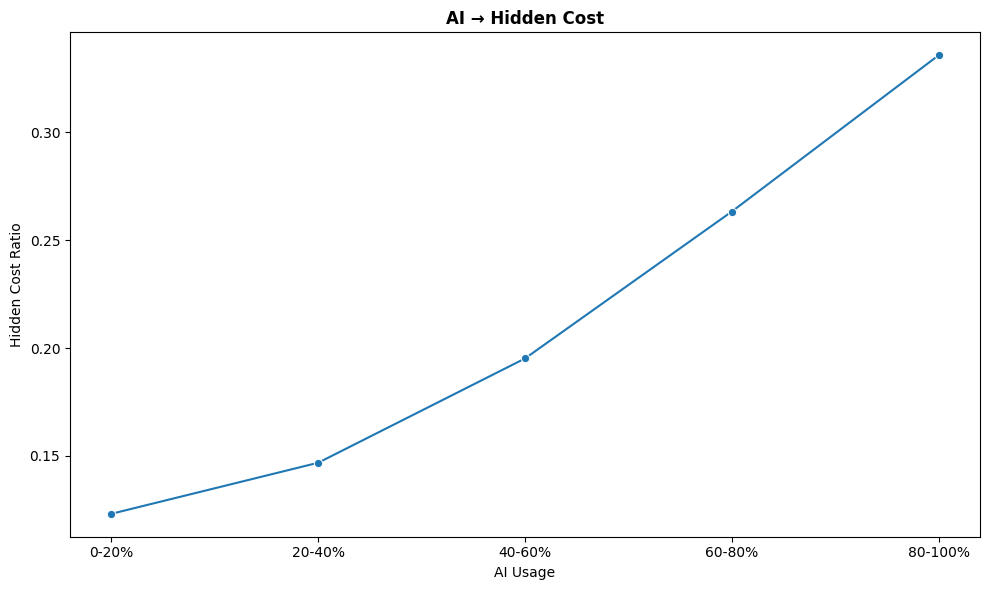

In [43]:
# ── 4. AI → Hidden cost (missing link) ───────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df_productivity, x='ai_bucket', y='hidden_cost_ratio',
             estimator='median', errorbar=None, marker='o', ax=ax)
ax.set_title('AI → Hidden Cost', fontweight='bold')
ax.set_xlabel('AI Usage')
ax.set_ylabel('Hidden Cost Ratio')
plt.tight_layout()

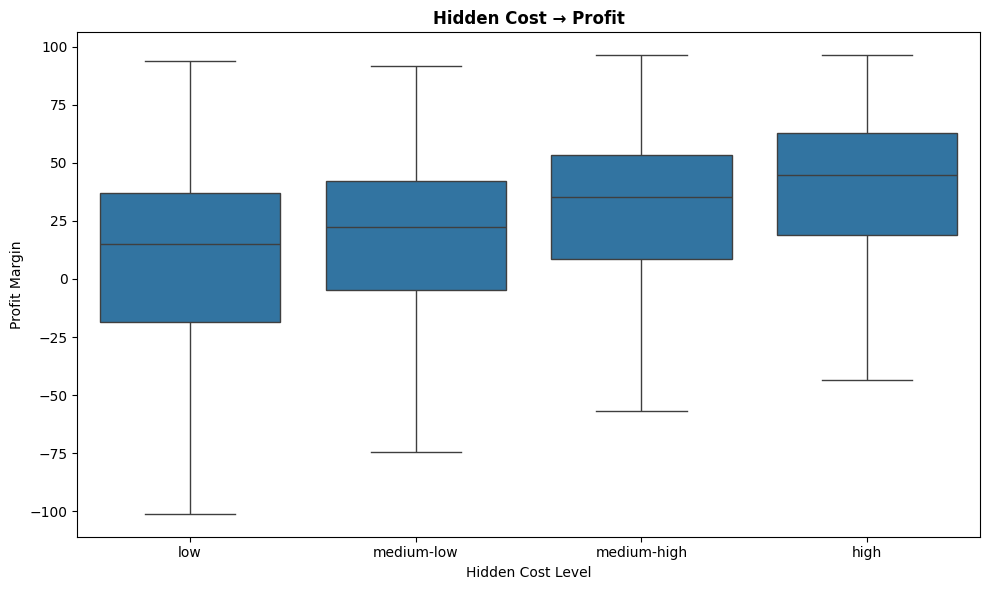

In [44]:
# ── 5. Hidden cost → Profit ───────────────────────────────────
if 'cost_bin' not in df_productivity.columns:
    df_productivity['cost_bin'] = pd.qcut(
        df_productivity['hidden_cost_ratio'], q=4,
        labels=['low', 'medium-low', 'medium-high', 'high']
    )

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_productivity, x='cost_bin', y='profit_margin',
            showfliers=False, ax=ax)
ax.set_title('Hidden Cost → Profit', fontweight='bold')
ax.set_xlabel('Hidden Cost Level')
ax.set_ylabel('Profit Margin')
plt.tight_layout()

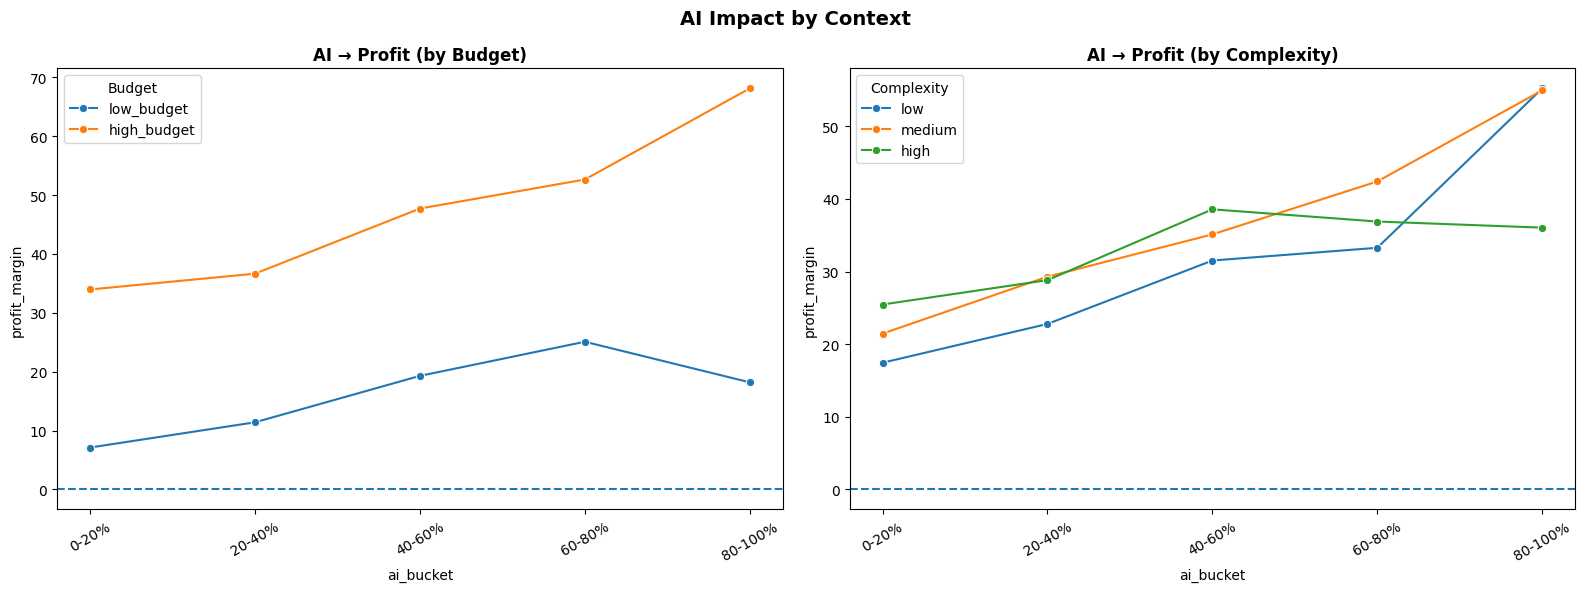

In [45]:
# ── 6. Segmentation: budget and complexity ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('AI Impact by Context', fontsize=14, fontweight='bold')

sns.lineplot(data=df_productivity, x='ai_bucket', y='profit_margin',
             hue='budget_bucket', estimator='median', errorbar=None,
             marker='o', ax=axes[0])
axes[0].axhline(0, linestyle='--')
axes[0].set_title('AI → Profit (by Budget)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

sns.lineplot(data=df_productivity, x='ai_bucket', y='profit_margin',
             hue='complexity_bucket', estimator='median', errorbar=None,
             marker='o', ax=axes[1])
axes[1].axhline(0, linestyle='--')
axes[1].set_title('AI → Profit (by Complexity)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[0].legend(title='Budget')
axes[1].legend(title='Complexity')

plt.tight_layout()

In [46]:
# ── 7. Threshold table (levels only) ───────────────────────────
threshold = df_productivity.groupby('ai_bucket', observed=True)[
    ['profit_margin', 'rework_rate', 'hidden_cost_ratio', 'hours_spent']
].median().round(3)
threshold = pd.DataFrame(threshold).reset_index()

print("=== Threshold Analysis (levels) ===")
display(threshold)

print("\nCounts per AI bucket:")
display(df_productivity['ai_bucket'].value_counts().sort_index().to_frame())

=== Threshold Analysis (levels) ===


,ai_bucket,profit_margin,rework_rate,hidden_cost_ratio,hours_spent
0,0-20%,20.981,0.133,0.123,11.615
1,20-40%,26.538,0.152,0.147,11.705
2,40-60%,35.297,0.191,0.195,10.700
3,60-80%,39.343,0.248,0.263,9.260
4,80-100%,48.963,0.298,0.336,10.240



Counts per AI bucket:


,count
ai_bucket,
0-20%,778
20-40%,1212
40-60%,812
60-80%,350
80-100%,48


### AI vs No AI: Statistical Comparison

The threshold analysis segmented tasks by AI usage intensity. This section steps back and asks the binary question: do tasks that use *any* AI differ systematically from those that use none at all?

We compute mean differences across four outcomes (`profit_margin`, `rework_rate`, `hidden_cost_ratio`, and `hours_spent`) and test statistical significance using **Welch's two-sample t-test** (which does not assume equal variance between the two groups).

The t-test results are particularly informative here. Given the extreme variance in `profit_margin` caused by outlier tasks (some tasks have very large positive or negative margins), we expect the test to reveal whether the observed mean difference is distinguishable from noise. A non-significant result would confirm that the median (used in the threshold analysis) is the more reliable estimator for this dataset, as the mean is dominated by extreme values.

> Welch's t-test is used instead of Student's t-test because the two groups (AI / No AI) have different sizes and likely different variances.

In [47]:
# ── 1. Summary statistics ─────────────────────────────────────
baseline = df_productivity.groupby('ai_flag')[
    ['profit_margin', 'rework_rate', 'hidden_cost_ratio', 'hours_spent']
].mean().round(3)

baseline.index = ['No AI', 'AI used']

baseline = pd.DataFrame(baseline)
print("=== Mean values: AI vs No-AI ===")
display(baseline)


# ── 2. Difference (AI - No AI) ───────────────────────────────
diff = (baseline.loc['AI used'] - baseline.loc['No AI']).round(3)

display(diff.to_frame(name = "Difference (AI - No AI)"))

=== Mean values: AI vs No-AI ===


,profit_margin,rework_rate,hidden_cost_ratio,hours_spent
No AI,42.121,0.227,0.260,8.210
AI used,14.821,0.392,0.242,13.025


,Difference (AI - No AI)
profit_margin,-27.300
rework_rate,0.165
hidden_cost_ratio,-0.018
hours_spent,4.815


In [48]:
no_ai = df_productivity[df_productivity['ai_flag'] == 0]
ai = df_productivity[df_productivity['ai_flag'] == 1]

print("\n=== t-tests ===")

t_test = pd.DataFrame()
for var in ['profit_margin', 'rework_rate', 'hidden_cost_ratio', 'hours_spent']:
    t_stat, p_val = stats.ttest_ind(
        ai[var],
        no_ai[var],
        equal_var=False,
        nan_policy='omit'
    )
    
    sig = '***' if p_val < 0.001 else (
          '**'  if p_val < 0.01  else (
          '*'   if p_val < 0.05  else 'n.s.'))

    t_test[var] = ({
        't-statistic': t_stat,
        'p-value': p_val,
        'Significance': sig
    })


display(t_test.transpose())


=== t-tests ===


,t-statistic,p-value,Significance
profit_margin,-2.084115,0.280603,n.s.
rework_rate,0.822462,0.522044,n.s.
hidden_cost_ratio,-0.083654,0.946856,n.s.
hours_spent,2.58732,0.230058,n.s.


### Nonparametric Confirmation: Mann-Whitney U Test

The Welch's t-tests above operate on *means*. Since we established earlier that `profit_margin` is right-skewed and that the median is the more reliable central estimator for this dataset, consistency requires a complementary nonparametric test that does not assume normality.

The **Mann-Whitney U test** compares the full rank distributions of the two groups (AI vs No-AI) without assuming equal variances or normality. It is the nonparametric equivalent of the t-test and is appropriate when the median is the preferred estimator.


In [52]:
print("=== Mann-Whitney U tests (nonparametric) ===")
print("H₀: the two distributions are identical | α = 0.05")

u_test = pd.DataFrame()
for var in ['profit_margin', 'rework_rate', 'hidden_cost_ratio', 'hours_spent']:
    stat, p_val = mannwhitneyu(
        ai[var].dropna(),
        no_ai[var].dropna(),
        alternative='two-sided'
    )
    sig = '***' if p_val < 0.001 else (
          '**'  if p_val < 0.01  else (
          '*'   if p_val < 0.05  else 'n.s.'))
    
    u_test[var] = ({
        'U-statistic': stat,
        'p-value': p_val,
        'Significance': sig
    })

display(u_test.transpose())

=== Mann-Whitney U tests (nonparametric) ===
H₀: the two distributions are identical | α = 0.05


,U-statistic,p-value,Significance
profit_margin,2254.0,0.49718,n.s.
rework_rate,3283.0,0.948404,n.s.
hidden_cost_ratio,3208.0,0.994195,n.s.
hours_spent,4643.0,0.268775,n.s.


Both t-tests and Mann-Whitney tests are non-significant: the binary AI/No-AI split produces no statistically detectable difference by either method. This confirms that splitting by presence vs. absence of AI is not informative.
The signal lies in the intensity of adoption, as the threshold analysis shows.

### Reconciling the Apparent Contradiction

The two analyses above produce results that initially appear to tell opposite stories:

- **Binary split:** Tasks flagged as AI-used show a *lower* median profit margin (29.1%) than no-AI tasks (42.1%) → AI looks harmful  
- **Intensity split:** As AI usage increases bucket by bucket (0–20%, ..., 80–100%), the median margin rises monotonically from 21% to 49% → AI looks beneficial

These results are **fully compatible** once you look at what the "AI used" group actually contains:

- The binary flag `ai_flag = 1` captures **every** task with any AI involvement, from 0.1% to 93%. That includes the 0–20% intensity bucket (n=778), which has the **lowest median margin of all groups (20.98%)**, worse even than the heavy-AI tasks and almost as bad as tasks with no AI. These low-adoption tasks drag the entire "AI used" average down.

- The no-AI group (`ai_flag = 0`), on the other hand, is made up of tasks where teams consciously chose not to use AI, likely simpler, faster tasks (median 8.2h vs 11.1h), which naturally carry higher margins.

**The correct reading is therefore:**

> The binary comparison is misleading because it merges shallow AI adoption (0–20%) with deep AI adoption (60–100%). The real variable that matters is not *whether* AI was used, but *how intensively*. Partial, low-confidence AI usage is associated with the worst outcomes in the dataset. Deep adoption is associated with the best.

This reframes the research question: the relevant threshold is not **whether** AI is used, but **at what depth of adoption** its effect turns positive.



# Trade-off Analysis


### Speed, Quality, and Value: Decomposing the AI Effect

The threshold table showed that `profit_margin` rises monotonically with AI usage intensity. But a higher margin could stem from two very different mechanisms:

1. **Speed**: AI reduces `hours_spent`, lowering cost and expanding margin.
2. **Quality**: AI reduces errors and rework, improving output quality and client retention.

We examine three separate outcome variables across `ai_bucket` tiers:
- `hours_spent`: proxy for speed (lower = faster)
- `rework_hours`: proxy for quality (lower = fewer corrections needed)
- `profit`: absolute value created

A scatter of `hours_spent` vs `profit` coloured by AI usage tier then shows whether the two dimensions move together or trade off against each other.

> All estimators use **median** to guard against the influence of extreme values.

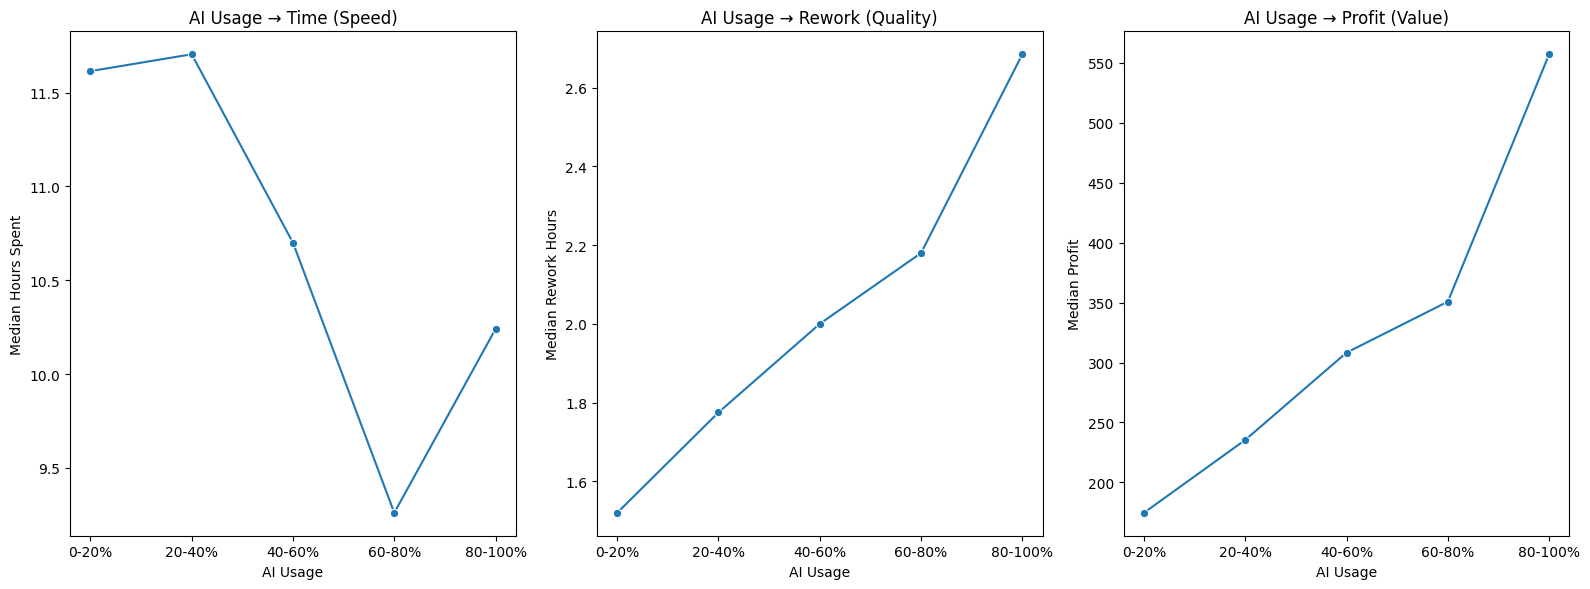

In [53]:
# ── 1. AI → SPEED
fig, ax = plt.subplots(1,3,figsize=(16, 6))

sns.lineplot(
    data=df_productivity,
    x='ai_bucket',
    y='hours_spent',
    estimator='median',
    errorbar=None,
    marker='o',
    ax=ax[0]
)

ax[0].set_title('AI Usage → Time (Speed)')
ax[0].set_xlabel('AI Usage')
ax[0].set_ylabel('Median Hours Spent')
plt.tight_layout()


# ── 2. AI → QUALITY (rework)

sns.lineplot(
    data=df_productivity,
    x='ai_bucket',
    y='rework_hours',
    estimator='median',
    errorbar=None,
    marker='o',
    ax=ax[1]
)

ax[1].set_title('AI Usage → Rework (Quality)')
ax[1].set_xlabel('AI Usage')
ax[1].set_ylabel('Median Rework Hours')
plt.tight_layout()


# ── 3. AI → VALUE (profit)

sns.lineplot(
    data=df_productivity,
    x='ai_bucket',
    y='profit',
    estimator='median',
    errorbar=None,
    marker='o',
    ax=ax[2]
)

ax[2].set_title('AI Usage → Profit (Value)')
ax[2].set_xlabel('AI Usage')
ax[2].set_ylabel('Median Profit')
plt.tight_layout()

### Speed vs. Value: Are Fast Tasks Also Profitable?

The line plot above (AI → Time) showed that hours spent **decrease** as AI usage deepens within the adoption spectrum, from 11.6h at 0–20% down to 9.3h at 60–80%. This means that among tasks where AI is used, higher AI intensity is associated with faster execution.

However, AI-using tasks overall are still slower than no-AI tasks (11.1h vs 8.2h in the binary comparison) suggesting that AI is selectively applied to larger, more complex tasks that inherently take longer, and that deeper AI usage then recovers some of that time.

This scatter plot maps each task by `hours_spent` (x-axis) vs `profit` (y-axis), coloured by AI usage bucket. It asks two questions simultaneously:

1. Is there a speed-value trade-off? (Do slower tasks produce more profit, or less?)
2. Do high-AI tasks occupy a distinct region of the speed-profit space, suggesting AI reshapes the relationship between effort and value?


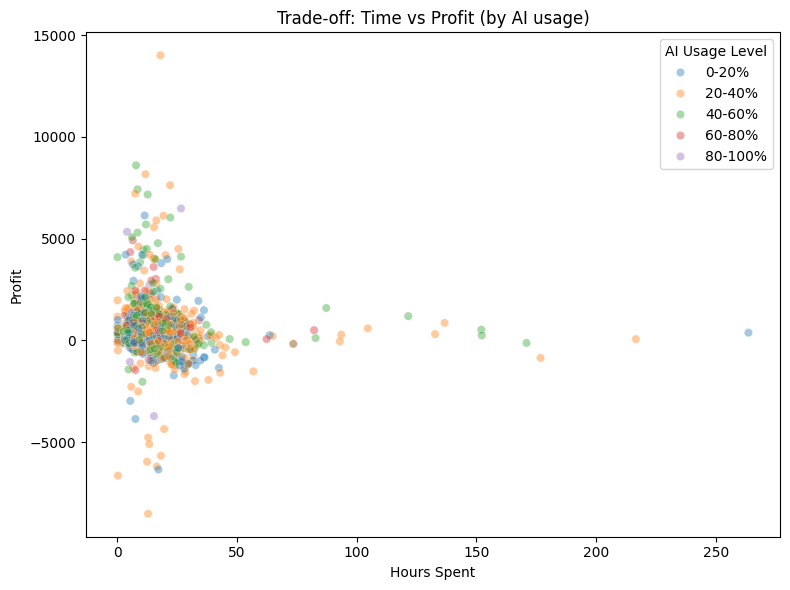

In [54]:
# SPEED vs VALUE

fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=df_productivity,
    x='hours_spent',
    y='profit',
    hue='ai_bucket',
    alpha=0.4,
    ax=ax
)

ax.set_title('Trade-off: Time vs Profit (by AI usage)')
ax.set_xlabel('Hours Spent')
ax.set_ylabel('Profit')
ax.legend(title='AI Usage Level')

plt.tight_layout()

### AI → Reliability: SLA Breach Rate

Beyond speed, quality, and value, a fourth operational dimension is contractual reliability: whether tasks are delivered within the agreed SLA window. With almost 40% of tasks breaching SLA overall, it is worth checking whether AI usage intensity is associated with more or fewer breaches.

A rising breach rate with AI intensity would suggest that AI creates a speed illusion: tasks feel faster to execute but still miss deadlines, possibly because AI-assisted work generates more revision cycles. A falling rate would confirm that AI genuinely improves delivery reliability.


=== SLA Breach Rate by AI Bucket ===


,ai_bucket,sla_breach_rate_pct
0,0-20%,45.37
1,20-40%,41.42
2,40-60%,35.84
3,60-80%,32.00
4,80-100%,27.08


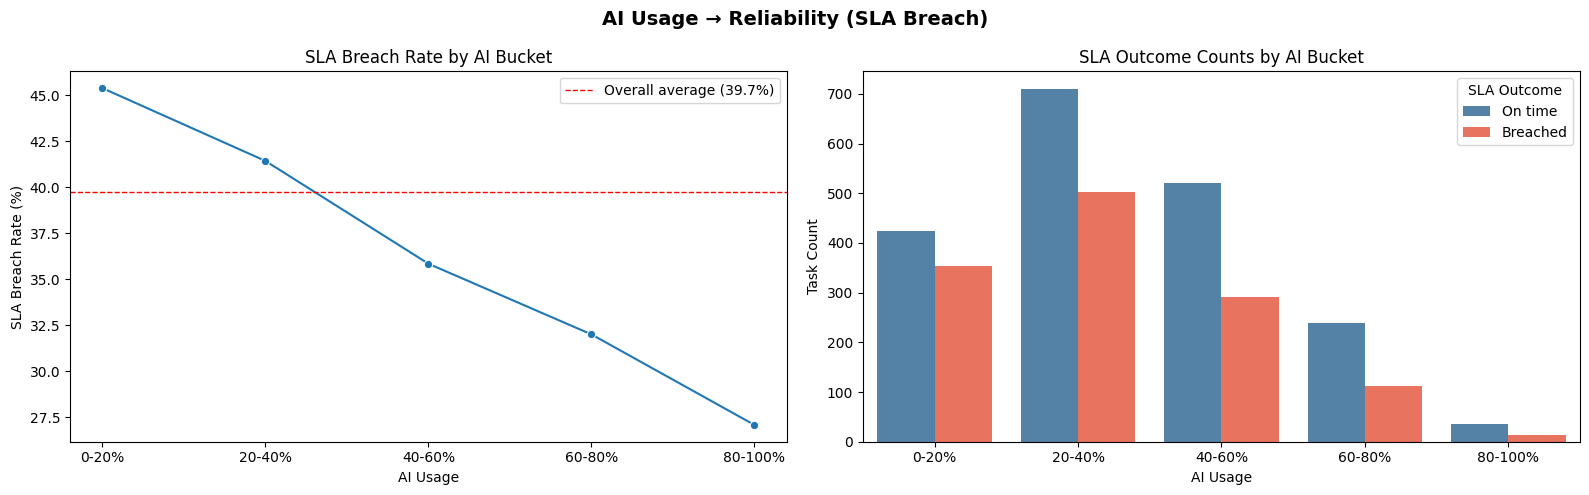

In [55]:
# ── 4. AI → RELIABILITY (SLA breach rate) ─────────────────────

sla_by_bucket = (
    df_productivity
    .groupby('ai_bucket', observed=True)['sla_breach']
    .apply(lambda x: x.astype(int).mean() * 100)
    .reset_index()
    .rename(columns={'sla_breach': 'sla_breach_rate_pct'})
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('AI Usage → Reliability (SLA Breach)', fontsize=14, fontweight='bold')

# Line: breach rate across buckets
sns.lineplot(
    data=sla_by_bucket,
    x='ai_bucket',
    y='sla_breach_rate_pct',
    marker='o',
    ax=axes[0]
)
axes[0].axhline(
    df_productivity['sla_breach'].astype(int).mean() * 100,
    linestyle='--', color='red', linewidth=1,
    label=f'Overall average ({df_productivity["sla_breach"].astype(int).mean()*100:.1f}%)'
)
axes[0].set_title('SLA Breach Rate by AI Bucket')
axes[0].set_xlabel('AI Usage')
axes[0].set_ylabel('SLA Breach Rate (%)')
axes[0].legend()

# Bar: absolute counts of breached vs. not breached per bucket
sla_counts = (
    df_productivity
    .groupby(['ai_bucket', 'sla_breach'], observed=True)
    .size()
    .reset_index(name='count')
)
sla_counts['sla_breach'] = sla_counts['sla_breach'].map(
    {True: 'Breached', False: 'On time'}
)

sns.barplot(
    data=sla_counts,
    x='ai_bucket',
    y='count',
    hue='sla_breach',
    palette={'On time': 'steelblue', 'Breached': 'tomato'},
    ax=axes[1]
)
axes[1].set_title('SLA Outcome Counts by AI Bucket')
axes[1].set_xlabel('AI Usage')
axes[1].set_ylabel('Task Count')
axes[1].legend(title='SLA Outcome')

plt.tight_layout()

print("\n=== SLA Breach Rate by AI Bucket ===")
display(sla_by_bucket.round(2))

# Threshold Detection

### Marginal Effects and the Point of Diminishing Returns

The previous analyses show that `profit_margin` generally increases with AI usage intensity. To make this result operational, we focus on **marginal effects**: the step-by-step change in outcomes when moving from one AI bucket to the next.

This section is organized as follows:

1. A threshold **levels table** summarizes median values by bucket (`profit_median`, `rework_median`, `hidden_median`, `time_median`).
2. First differences are computed (`profit_diff`, `rework_diff`, `hidden_diff`) to quantify incremental gains and costs.
3. A marginal-effects visualization highlights where profit gains are strongest and where rework/hidden costs accelerate.

The tier with the highest `profit_diff` is interpreted as the empirical peak in marginal benefit. If cost-side deltas continue rising after that point, the result indicates a practical diminishing-returns zone rather than a sharp negative threshold.

> The 80-100% bucket contains only 48 tasks, so estimates in that tier should be interpreted with caution.

=== Threshold table with marginal effects ===


,ai_bucket,profit_median,profit_std,n_obs,rework_median,hidden_median,time_median,profit_diff,rework_diff,hidden_diff
0,0-20%,20.981,75.338,778,0.133,0.123,11.615,0.000,0.000,0.000
1,20-40%,26.538,90.728,1212,0.152,0.147,11.705,5.557,0.019,0.024
2,40-60%,35.297,50.876,812,0.191,0.195,10.700,8.759,0.039,0.048
3,60-80%,39.343,72.945,350,0.248,0.263,9.260,4.046,0.057,0.068
4,80-100%,48.963,79.301,48,0.298,0.336,10.240,9.620,0.050,0.073


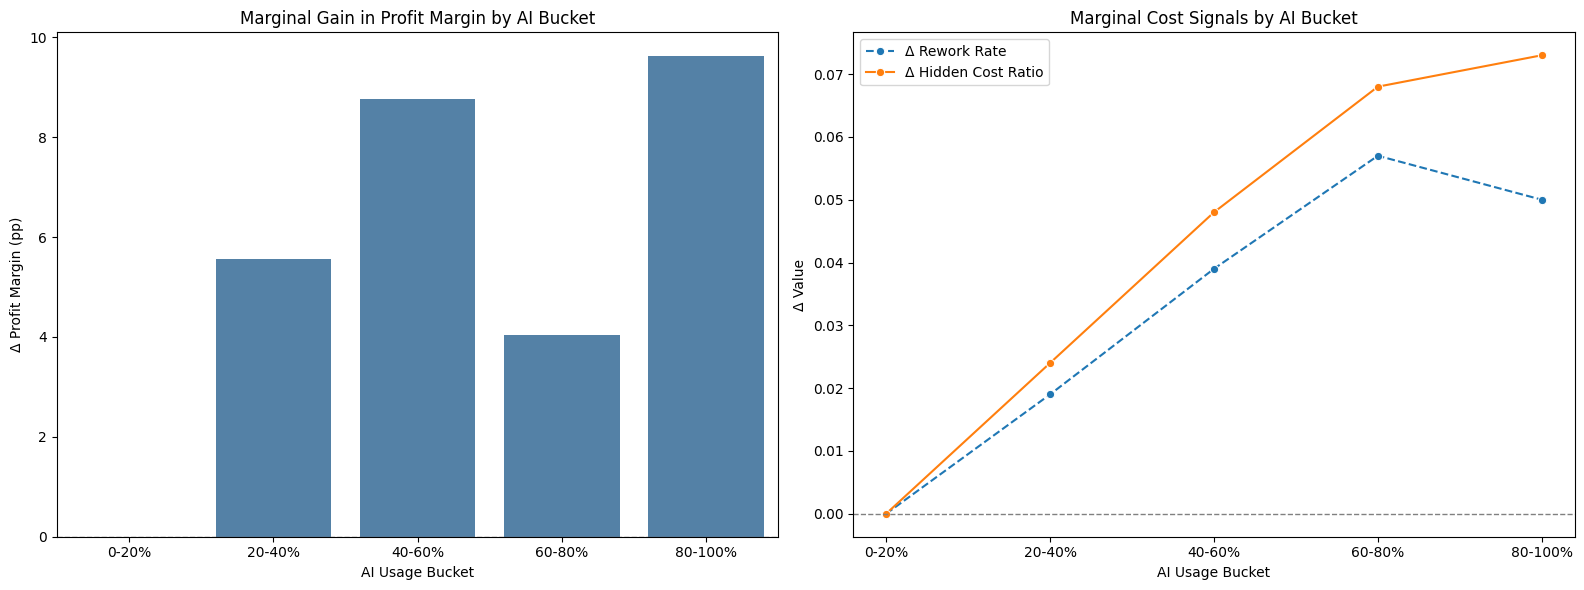

In [56]:
# THRESHOLD DETECTION (marginal effects, no duplicated level plots)

threshold_df = df_productivity.groupby('ai_bucket', observed=True).agg(
    profit_median=('profit_margin', 'median'),
    profit_std=('profit_margin', 'std'),
    n_obs=('profit_margin', 'count'),
    rework_median=('rework_rate', 'median'),
    hidden_median=('hidden_cost_ratio', 'median'),
    time_median=('hours_spent', 'median')
).round(3).reset_index()

threshold_df['profit_diff'] = threshold_df['profit_median'].diff().fillna(0)
threshold_df['rework_diff'] = threshold_df['rework_median'].diff().fillna(0)
threshold_df['hidden_diff'] = threshold_df['hidden_median'].diff().fillna(0)

print("=== Threshold table with marginal effects ===")
display(threshold_df)

# ── Marginal effects plot (new information vs previous cells) ──
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=threshold_df,
    x='ai_bucket',
    y='profit_diff',
    color='steelblue',
    ax=ax[0]
)
ax[0].axhline(0, linestyle='--', linewidth=1, color='gray')
ax[0].set_title('Marginal Gain in Profit Margin by AI Bucket')
ax[0].set_xlabel('AI Usage Bucket')
ax[0].set_ylabel('Δ Profit Margin (pp)')

sns.lineplot(
    data=threshold_df,
    x='ai_bucket',
    y='rework_diff',
    marker='o',
    linestyle='--',
    label='Δ Rework Rate',
    ax=ax[1]
)
sns.lineplot(
    data=threshold_df,
    x='ai_bucket',
    y='hidden_diff',
    marker='o',
    label='Δ Hidden Cost Ratio',
    ax=ax[1]
)
ax[1].axhline(0, linestyle='--', linewidth=1, color='gray')
ax[1].set_title('Marginal Cost Signals by AI Bucket')
ax[1].set_xlabel('AI Usage Bucket')
ax[1].set_ylabel('Δ Value')
ax[1].legend(loc='upper left')

plt.tight_layout()

In [57]:
# Ensure buckets are processed in their categorical order before reading the marginal gain
threshold_df = threshold_df.sort_values('ai_bucket').reset_index(drop=True)

best_idx = threshold_df['profit_diff'].idxmax()
best_bucket = threshold_df.loc[best_idx, 'ai_bucket']
best_value = threshold_df.loc[best_idx, 'profit_diff']

print("\n=== Empirical threshold ===")
print(f"Highest marginal gain: {best_bucket} (Δ = {best_value:.2f})")


=== Empirical threshold ===
Highest marginal gain: 80-100% (Δ = 9.62)


# Loss Analysis 


### Loss Analysis: Rework as the Margin Compression Mechanism

Even if AI does not cause a net margin inversion at the aggregate level, individual tasks can still lose money because of rework. This section isolates the rework-profit mechanism directly, bypassing AI usage as an intermediate variable.

The key question is: does `rework_cost_est` compress `profit_margin` on its own, regardless of what caused the rework? We test this with:

1. **Pearson and Spearman correlations** between `rework_cost_est` and `profit_margin` to detect both linear and monotonic relationships.
2. **A LOWESS smoother** on the scatter to visualize any non-linearity in the relationship.
3. **Quartile segmentation**: tasks are divided into four rework cost levels, and their median `profit_margin` is compared.
4. **The full mechanism table**: `rework_rate` → `rework_cost_est` → `profit_margin` by `ai_bucket`, to confirm whether rework is the channel through which AI usage affects profitability.

If rework cost compresses margins, any intervention that increases rework, AI-related or not, will erode value. This makes rework management the primary lever for improving profitability under any AI adoption strategy.

=== Pearson correlation: Rework Cost vs Profit Margin ===


,rework_cost_est,profit_margin
rework_cost_est,1.000,0.003
profit_margin,0.003,1.000



=== Spearman correlation: Rework Cost vs Profit Margin ===


,rework_cost_est,profit_margin
rework_cost_est,1.000,0.019
profit_margin,0.019,1.000


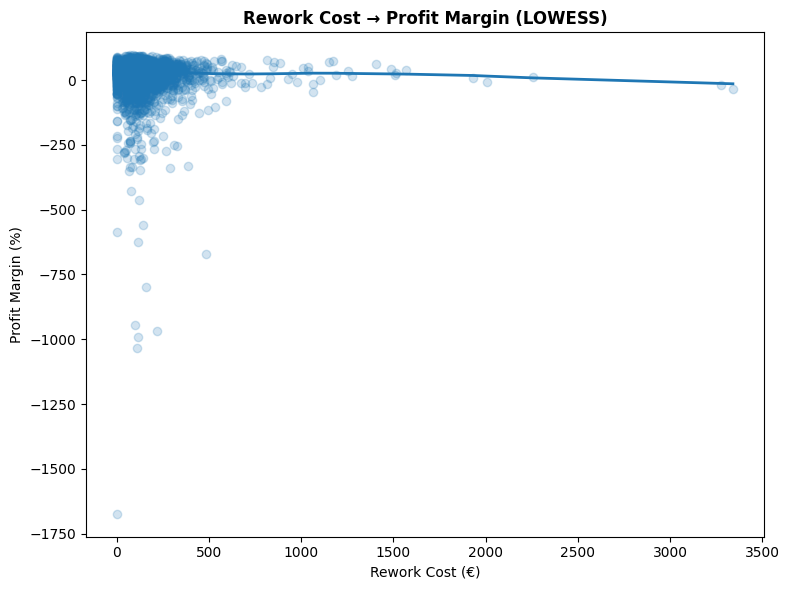

In [58]:
#  Correlation: rework cost vs profit 
corr_pearson = df_productivity[['rework_cost_est', 'profit_margin']].corr().round(3)

print("=== Pearson correlation: Rework Cost vs Profit Margin ===")
display(corr_pearson)

corr_spearman = df_productivity[['rework_cost_est', 'profit_margin']].corr(method='spearman').round(3)

print("\n=== Spearman correlation: Rework Cost vs Profit Margin ===")
display(corr_spearman)



fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    data=df_productivity,
    x='rework_cost_est',
    y='profit_margin',
    lowess=True,
    scatter_kws={'alpha': 0.2},
    line_kws={'linewidth': 2},
    ax=ax
)

ax.set_title('Rework Cost → Profit Margin (LOWESS)', fontweight='bold')
ax.set_xlabel('Rework Cost (€)')
ax.set_ylabel('Profit Margin (%)')

plt.tight_layout()


In [59]:
if 'rework_cost_bin' not in df_productivity.columns:
    df_productivity['rework_cost_bin'] = pd.qcut(
        df_productivity['rework_cost_est'],
        q=4,
        labels=['low', 'medium-low', 'medium-high', 'high']
    )

loss_analysis = df_productivity.groupby(
    'rework_cost_bin', observed=True
)['profit_margin'].median().round(2)

print("\n=== Median Profit Margin by Rework Cost Level ===")
display(loss_analysis.to_frame())


=== Median Profit Margin by Rework Cost Level ===


,profit_margin
rework_cost_bin,
low,27.55
medium-low,28.68
medium-high,29.83
high,31.57



=== Mechanism: AI → Rework → Cost → Profit ===


,rework_rate,rework_cost_est,profit_margin
ai_bucket,,,
0-20%,0.13,88.27,20.98
20-40%,0.15,103.08,26.54
40-60%,0.19,116.14,35.30
60-80%,0.25,126.59,39.34
80-100%,0.30,155.92,48.96


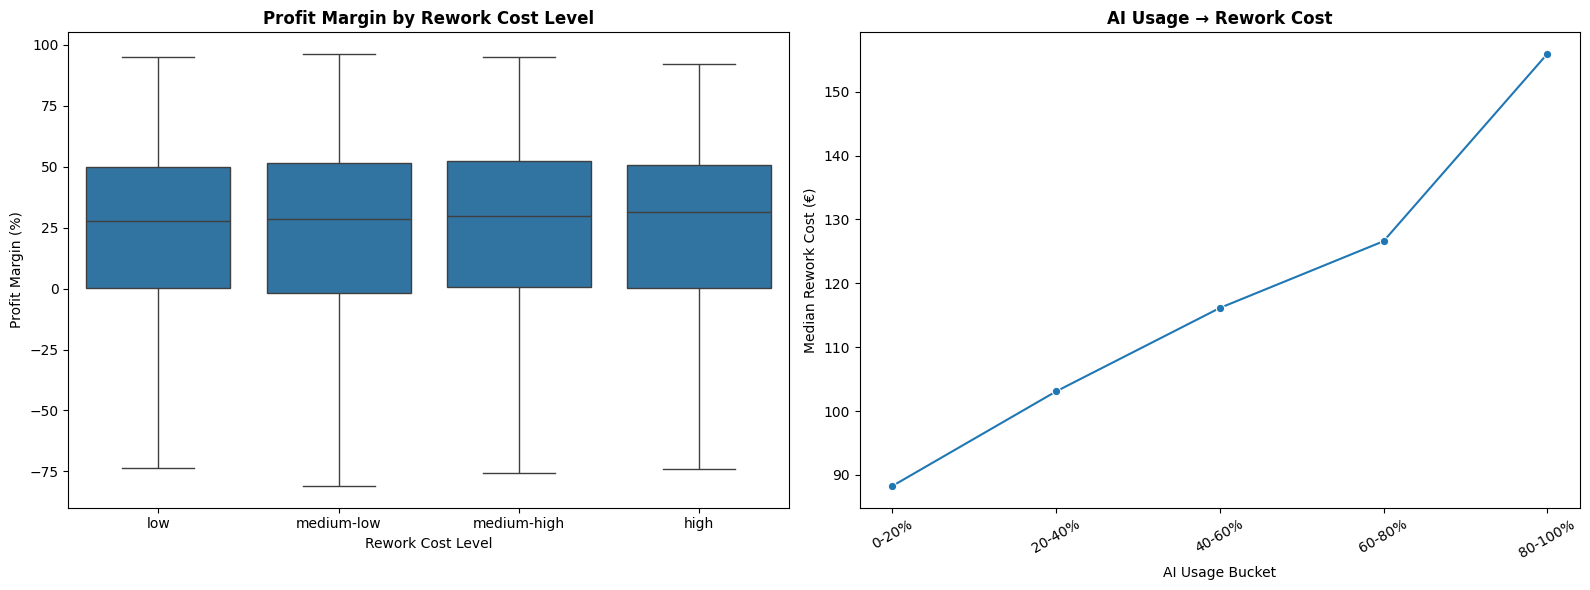

In [60]:
fig, ax = plt.subplots(1,2,figsize=(16, 6))

sns.boxplot(
    data=df_productivity,
    x='rework_cost_bin',
    y='profit_margin',
    showfliers=False,
    ax=ax[0]
)

ax[0].set_title('Profit Margin by Rework Cost Level', fontweight='bold')
ax[0].set_xlabel('Rework Cost Level')
ax[0].set_ylabel('Profit Margin (%)')

plt.tight_layout()

# ── AI → Rework Cost ─────────────────────────────────────────
sns.lineplot(
    data=df_productivity,
    x='ai_bucket',
    y='rework_cost_est',
    estimator='median',
    errorbar=None,
    marker='o',
    ax=ax[1]
)

ax[1].set_title('AI Usage → Rework Cost', fontweight='bold')
ax[1].set_xlabel('AI Usage Bucket')
ax[1].set_ylabel('Median Rework Cost (€)')
ax[1].tick_params(axis='x', rotation=30)

plt.tight_layout()

mechanism = df_productivity.groupby('ai_bucket', observed=True)[
    ['rework_rate', 'rework_cost_est', 'profit_margin']
].median().round(2)

print("\n=== Mechanism: AI → Rework → Cost → Profit ===")
display(mechanism)

### The Rework Paradox: Why Higher Rework Does Not Destroy Margins

The analysis above produces a counter-intuitive result that contradicts the original hypothesis.

**What we expected:** higher `rework_cost_est` → lower `profit_margin` (rework eats into profit)  
**What the data shows:** median profit margin *increases* with rework level, from 27.6% (low rework) to 31.6% (high rework). The mechanism table confirms the same pattern: the 80-100% AI bucket has the highest rework rate (0.30) *and* the highest profit margin (49%).

**The probable mechanism: the complexity premium**

Tasks that use AI intensively tend to be larger, more complex, and higher-revenue. The same characteristics that make a task complex (ambiguous brief, multiple stakeholders, iterative deliverables) also generate more rework. But these same tasks command significantly higher revenue, and the revenue premium outpaces the rework cost.

In other words: rework is a *symptom of complexity*, not an independent cost driver. For a given task, more rework does compress the margin. But across the dataset, high-rework tasks also happen to be high-revenue tasks. The correlation between rework and margin is positive because both co-vary with a third variable: task size and complexity.

**The implication for the research question:**

Rework is *not* the mechanism through which AI destroys margins because in this dataset, AI does not destroy margins at all at the aggregate level. The real trade-off is subtler: AI raises both revenue (by enabling more ambitious deliverables) and rework (by increasing the complexity of what gets attempted). Whether a specific task benefits depends on whether the revenue premium exceeds the rework cost, which the segmented analysis in the next section will investigate by team and task type.

## `Segmented Analysis`

### Where Does AI Actually Help? Breaking Down the Effect by Team, Task Type, and Pricing Model

The aggregate threshold analysis confirmed that higher AI usage is associated with higher median margins across the full dataset. But this average obscures potential structural differences: AI may be systematically beneficial for some teams and neutral (or harmful) for others, and the type of work — and how it is billed — may matter as much as the team itself.

This section disaggregates the AI-margin relationship along three dimensions:

1. **Team** (Content, Media, Design, SEO): each team operates on different deliverables, different revision cycles, and different baseline familiarity with AI tools.
2. **Task type**: different categories of work may respond differently to AI assistance: structured or repetitive tasks may benefit more than creative or judgment-intensive ones.
3. **Pricing model**: the commercial structure of the contract determines whether AI efficiency gains are captured as profit or transferred to the client. Under hourly billing, fewer hours means less revenue; under fixed-price or value-based contracts, the same gain flows directly to margin.

For the first two dimensions we compute the **median `profit_margin`** per `ai_bucket` and display it as a heatmap. A row that rises from left (low AI) to right (high AI) indicates a segment where deeper AI adoption consistently pays off. A flat or declining row indicates a segment where AI provides little marginal benefit. A companion count heatmap is shown alongside each margin heatmap to flag cells with fewer than 20 tasks, where the median estimate is less reliable.

For the pricing model dimension we use a line chart rather than a heatmap, since the number of pricing categories is small and the trajectory across buckets is more readable as a continuous profile than as a grid.


=== Median Profit Margin by Team × AI Bucket ===


ai_bucket,0-20%,20-40%,40-60%,60-80%,80-100%
team,,,,,
Content,18.7,29.0,36.2,40.7,50.6
Design,18.6,23.9,30.1,38.8,49.2
Media,21.4,30.1,38.8,38.0,51.9
SEO,22.2,21.6,35.4,41.5,25.0


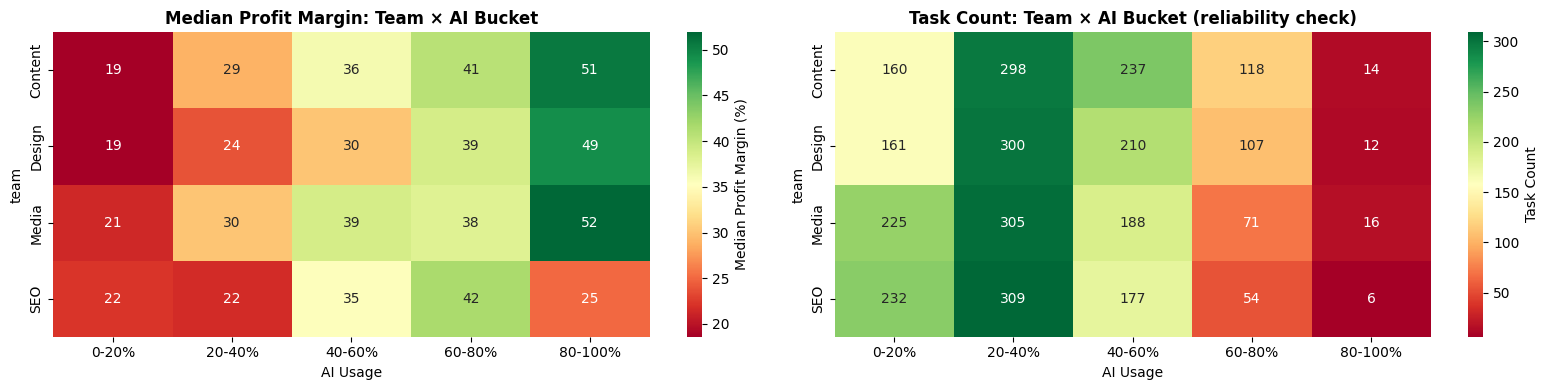

In [61]:
# ── Segmented Analysis: Team × AI Bucket ─────────────────────

team_margin = df_productivity.pivot_table(
    values='profit_margin', index='team',
    columns='ai_bucket', aggfunc='median'
).round(1)

team_counts = df_productivity.pivot_table(
    values='profit_margin', index='team',
    columns='ai_bucket', aggfunc='count'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.heatmap(team_margin, annot=True,
            cmap='RdYlGn', ax=axes[0], cbar_kws={'label': 'Median Profit Margin (%)'})
axes[0].set_title('Median Profit Margin: Team × AI Bucket', fontweight='bold')
axes[0].set_xlabel('AI Usage')

sns.heatmap(team_counts, annot=True, fmt='.0f',
            cmap='RdYlGn', ax=axes[1], cbar_kws={'label': 'Task Count'})
axes[1].set_title('Task Count: Team × AI Bucket (reliability check)', fontweight='bold')
axes[1].set_xlabel('AI Usage')

plt.tight_layout()

print("\n=== Median Profit Margin by Team × AI Bucket ===")
display(team_margin)



=== Median Profit Margin by Task Type × AI Bucket ===


ai_bucket,0-20%,20-40%,40-60%,60-80%,80-100%
task_type,,,,,
Ad,23.0,30.5,29.2,41.2,25.2
Article,25.4,30.0,36.2,30.5,46.4
Design,22.2,29.2,39.4,44.4,56.9
Development,19.8,28.9,37.3,39.0,70.8
Release,16.3,20.1,35.2,50.5,39.6
Report,19.3,28.9,36.6,39.7,60.2
Ticket,11.3,17.5,31.1,21.4,58.7


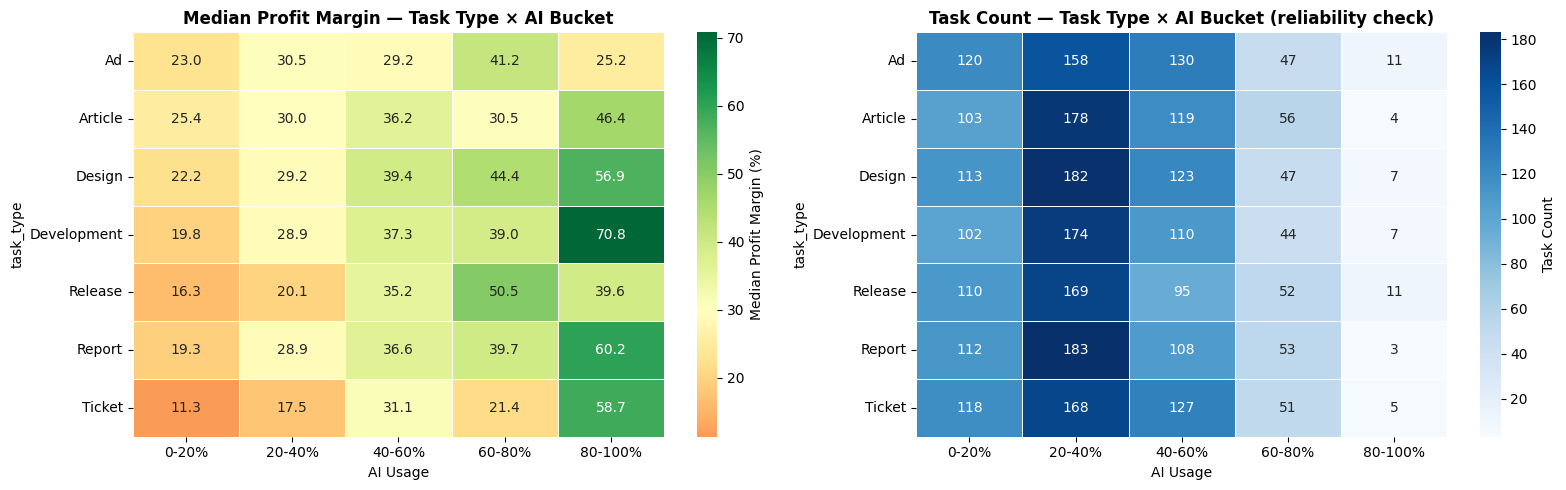

In [62]:
# ── Segmented Analysis: Task Type × AI Bucket ─────────────────

task_margin = df_productivity.pivot_table(
    values='profit_margin', index='task_type',
    columns='ai_bucket', aggfunc='median'
).round(1)

task_counts = df_productivity.pivot_table(
    values='profit_margin', index='task_type',
    columns='ai_bucket', aggfunc='count'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(task_margin, annot=True, fmt='.1f',
            cmap='RdYlGn', center=30, linewidths=0.5,
            ax=axes[0], cbar_kws={'label': 'Median Profit Margin (%)'})
axes[0].set_title('Median Profit Margin — Task Type × AI Bucket', fontweight='bold')
axes[0].set_xlabel('AI Usage')

sns.heatmap(task_counts, annot=True, fmt='.0f',
            cmap='Blues', linewidths=0.5,
            ax=axes[1], cbar_kws={'label': 'Task Count'})
axes[1].set_title('Task Count — Task Type × AI Bucket (reliability check)', fontweight='bold')
axes[1].set_xlabel('AI Usage')

plt.tight_layout()

print("\n=== Median Profit Margin by Task Type × AI Bucket ===")
display(task_margin)


=== Median Profit Margin by Pricing Model × AI Bucket ===


ai_bucket,0-20%,20-40%,40-60%,60-80%,80-100%
pricing_model,,,,,
fixed,23.2,33.7,44.4,52.5,70.2
hourly,13.3,16.2,21.4,26.3,19.5
value_based,38.6,46.8,58.3,62.8,68.1


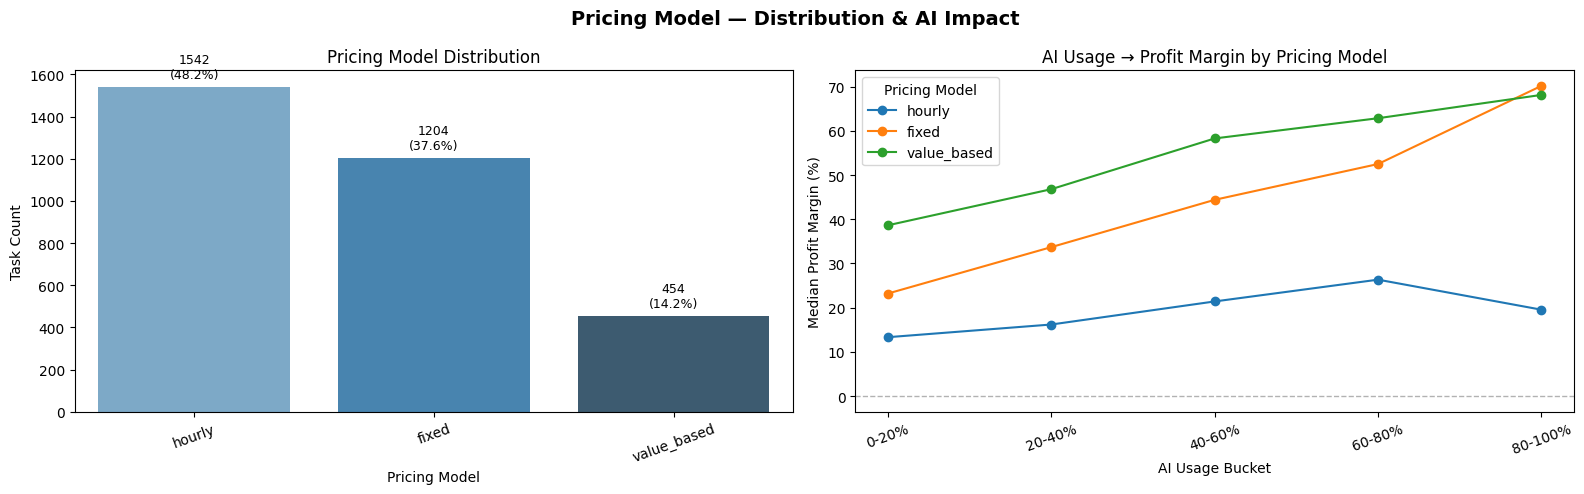

In [63]:
# ── Segmented Analysis: Pricing Model × AI Bucket ────────────

# 1. Pricing model distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Pricing Model — Distribution & AI Impact', fontsize=14, fontweight='bold')

pricing_counts = (
    df_productivity['pricing_model']
    .value_counts(dropna=True)
    .reset_index()
)

sns.barplot(
    data=pricing_counts,
    x='pricing_model',
    y='count',
    palette='Blues_d',
    ax=axes[0]
)
total = pricing_counts['count'].sum()
for bar in axes[0].patches:
    height = bar.get_height()
    axes[0].annotate(
        f'{int(height)}\n({height/total*100:.1f}%)',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4), textcoords='offset points',
        ha='center', va='bottom', fontsize=9
    )
axes[0].set_title('Pricing Model Distribution')
axes[0].set_xlabel('Pricing Model')
axes[0].set_ylabel('Task Count')
axes[0].tick_params(axis='x', rotation=20)

# 2. AI → Profit Margin by pricing model
ai_order = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']

for pricing in df_productivity['pricing_model'].dropna().unique():
    subset = df_productivity[df_productivity['pricing_model'] == pricing]
    median_by_bucket = (
        subset.groupby('ai_bucket', observed=True)['profit_margin']
        .median()
        .reindex(ai_order)
    )
    axes[1].plot(
        median_by_bucket.index,
        median_by_bucket.values,
        marker='o',
        label=pricing
    )

axes[1].axhline(0, color='grey', linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_title('AI Usage → Profit Margin by Pricing Model')
axes[1].set_xlabel('AI Usage Bucket')
axes[1].set_ylabel('Median Profit Margin (%)')
axes[1].legend(title='Pricing Model')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()

# 3. Summary table
pricing_margin = df_productivity.pivot_table(
    values='profit_margin',
    index='pricing_model',
    columns='ai_bucket',
    aggfunc='median',
    observed=True
).round(1)

print("\n=== Median Profit Margin by Pricing Model × AI Bucket ===")
display(pricing_margin)

### Segmented Analysis Findings

The segmented heatmaps show that the relationship between AI intensity and profitability is **not uniform** across the organization.

At the aggregate level, higher AI usage is associated with higher margins, but this effect is driven by specific segments rather than all segments equally:

- Some **teams** display a clear upward trend in median `profit_margin` as AI usage moves from lower to higher buckets.
- Other teams appear flatter, indicating weaker marginal benefits from deeper AI adoption.
- A similar pattern appears across **task types**: certain categories benefit consistently from higher AI intensity, while others remain neutral or more volatile.

The pricing model dimension reveals the sharpest structural divide in the dataset. Three distinct profiles emerge:

- **Value-based contracts** deliver the highest margins at every AI intensity level, rising from 38.6% at 0-20% AI usage to 68.1% at 80-100%. The efficiency gains from AI flow almost entirely to the bottom line, since billing is decoupled from hours worked.
- **Fixed-price contracts** show a similarly clean upward trend, from 23.2% to 70.2%, confirming that AI productivity gains are captured as profit when the revenue side is locked in advance.
- **Hourly contracts**, which represent the majority of tasks (48.2%), tell a fundamentally different story. Margin rises only modestly from 13.3% to a peak of 26.3% at 60-80% AI usage, then **reverses to 19.5% at 80–100%**. This is the only pricing model where the highest AI intensity is associated with *lower* margin than the tier below it. The mechanism is direct: as AI makes execution faster, billable hours fall, and under hourly billing that means revenue falls with them.

This heterogeneity supports a targeted adoption strategy:

1. Prioritize deeper AI rollout where the heatmap shows a stable positive trend, particularly for fixed-price and value-based contracts.
2. Treat hourly-billed tasks as a structural constraint: AI can still improve margins up to the 60-80% tier, but pushing beyond that threshold without repricing the contract erodes rather than creates value.
3. Use the companion **count heatmaps** as a reliability filter: cells with low volume should be interpreted cautiously and validated with additional data.

Overall, the segmented view confirms that the key managerial question is not whether AI works on average, but **under which commercial structure** deeper AI usage produces consistent economic value. The pricing model is the primary moderator, a finding that the formal modelling in the next section will corroborate quantitatively.

## `Modelling`
### What do observable task attributes tell us about profit margin?

This section estimates the relationship between AI usage intensity and `profit_margin` using the cleaned dataset produced in the previous phases. The target variable is defined as `profit / revenue × 100`.

The analysis is structured in two parts:

1. **Base models**: Lasso for feature selection, Linear Regression on the retained features, Random Forest with grid search, and SHAP feature importance;
2. **Log-transformed models**: same pipeline rerun after applying `log1p` to right-skewed features, with a direct metric comparison to the base results.

Boolean columns `sla_breach`, `scope_change_flag`, and `ai_assisted` are remapped to 0/1 integer on load so that the ColumnTransformer can treat them
as numeric features without requiring a separate encoding step.


In [64]:
for col in ['sla_breach', 'scope_change_flag', 'ai_assisted']:
    df_productivity[col] = df_productivity[col].astype(int)

### Feature Exclusion

Before any modelling, variables that are logically inadmissible are removed. Lasso cannot detect these exclusions: it would exploit leakage silently or absorb identifiers that happen to correlate by chance.

- **Leakage** (algebraically derived from the target, `profit_margin = profit / revenue × 100`): `profit`, `revenue`, `cost`, `revenue_per_hour`, `cost_per_hour`, `profit_bucket`, `budget_bucket`, `hidden_cost_ratio`, `rework_cost_est`, `rework_bin`, `cost_bin`, `rework_cost_bin`.

- **Identifiers** (no signal by construction): `task_id`, `project_id`, `client`, `created_by`.

- **Raw timestamps** (`duration_days` already encodes elapsed time): `created_at`, `delivered_at`, `updated_at`.

- **Post-hoc flags** (not available at prediction time): `task_status`, `workflow_stage`.

Everything else enters Lasso as a candidate feature. The purpose of this first step is to let the data decide what is redundant or irrelevant among the remaining candidates, rather than excluding variables manually.

In [65]:
EXCLUDE = {
    # Leakage
    'profit', 'revenue', 'cost', 'revenue_per_hour', 'cost_per_hour',
    'profit_bucket', 'budget_bucket', 'hidden_cost_ratio', 'rework_cost_est',
    'rework_bin', 'cost_bin', 'rework_cost_bin',
    # Identifiers
    'task_id', 'project_id', 'client', 'created_by',
    # Raw timestamps
    'created_at', 'delivered_at', 'updated_at',
    # Post-hoc flags
    'task_status', 'workflow_stage',
    # Target
    'profit_margin',
}

TARGET = 'profit_margin'
CANDIDATE_FEATURES = [c for c in df_productivity.columns if c not in EXCLUDE]

NUM_FEATURES = df_productivity[CANDIDATE_FEATURES].select_dtypes(include='number').columns.tolist()
CAT_FEATURES = df_productivity[CANDIDATE_FEATURES].select_dtypes(exclude='number').columns.tolist()

feature_table = pd.DataFrame({
    'Feature'    : NUM_FEATURES + CAT_FEATURES,
    'Numeric'    : ['✓'] * len(NUM_FEATURES) + [''] * len(CAT_FEATURES),
    'Categorical': [''] * len(NUM_FEATURES) + ['✓'] * len(CAT_FEATURES),
})

summary = pd.DataFrame({
    'Feature'    : [f'Total: {len(CANDIDATE_FEATURES)}'],
    'Numeric'    : [str(len(NUM_FEATURES))],
    'Categorical': [str(len(CAT_FEATURES))],
})

display(pd.concat([feature_table, summary], ignore_index=True))

,Feature,Numeric,Categorical
0,task_complexity_score,✓,
1,brief_quality_score,✓,
2,scope_change_flag,✓,
3,sla_days,✓,
4,sla_breach,✓,
5,hours_spent,✓,
6,billable_hours,✓,
7,ai_usage_pct,✓,
8,ai_assisted,✓,
9,revisions,✓,


### Preprocessing Pipeline and Train/Test Split

A `ColumnTransformer` is built with two branches:

- **Numeric**: median imputation followed by `StandardScaler`
- **Categorical**: most-frequent imputation followed by `OneHotEncoder` with `handle_unknown='ignore'`

The same `build_preprocessor` function is reused across both sections to ensure identical preprocessing logic. The train/test split is 80/20.

In [66]:
def build_preprocessor(num_cols, cat_cols):
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer([
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols),
    ])


def get_feature_names(preprocessor, num_cols, cat_cols):
    cat_names = (
        preprocessor.named_transformers_['cat']
        .named_steps['ohe']
        .get_feature_names_out(cat_cols)
        .tolist()
    ) if cat_cols else []
    return list(num_cols) + cat_names


def eval_model(pipe, X_tr, X_te, y_tr, y_te, cv=5):
    y_pred = pipe.predict(X_te)
    r2 = r2_score(y_te, y_pred)
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    cv_r2 = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring='r2').mean()
    return r2, mae, rmse, cv_r2


# ── Train / test split ─────────────────────────────────────────────────────
X = df_productivity[CANDIDATE_FEATURES]
y = df_productivity[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

display(pd.DataFrame({
    'Set'  : ['Train', 'Test'],
    'Rows' : [X_train.shape[0], X_test.shape[0]],
    'Share': ['80%', '20%'],
}))

,Set,Rows,Share
0,Train,2560,80%
1,Test,640,20%


### Step 1: Lasso for Feature Selection

`LassoCV` with 5-fold cross-validation selects the regularisation strength (alpha) that minimises held-out MSE. With `max_iter=10000` the solver has enough iterations to converge on the full candidate set.

Lasso is used here only as a **feature selector**, not as a predictive model. Its output is the set of features with non-zero coefficients, which feeds the Linear Regression in Step 2. For this reason, Lasso is not included in the final model comparison table.

The bar chart below shows all retained features sorted by absolute coefficient magnitude. Blue bars indicate a positive association with `profit_margin`; red bars indicate a negative one.

,Metric,Value
0,Best alpha (LassoCV),0.5697
1,Features retained,32 / 57
2,Features zeroed out,25 / 57


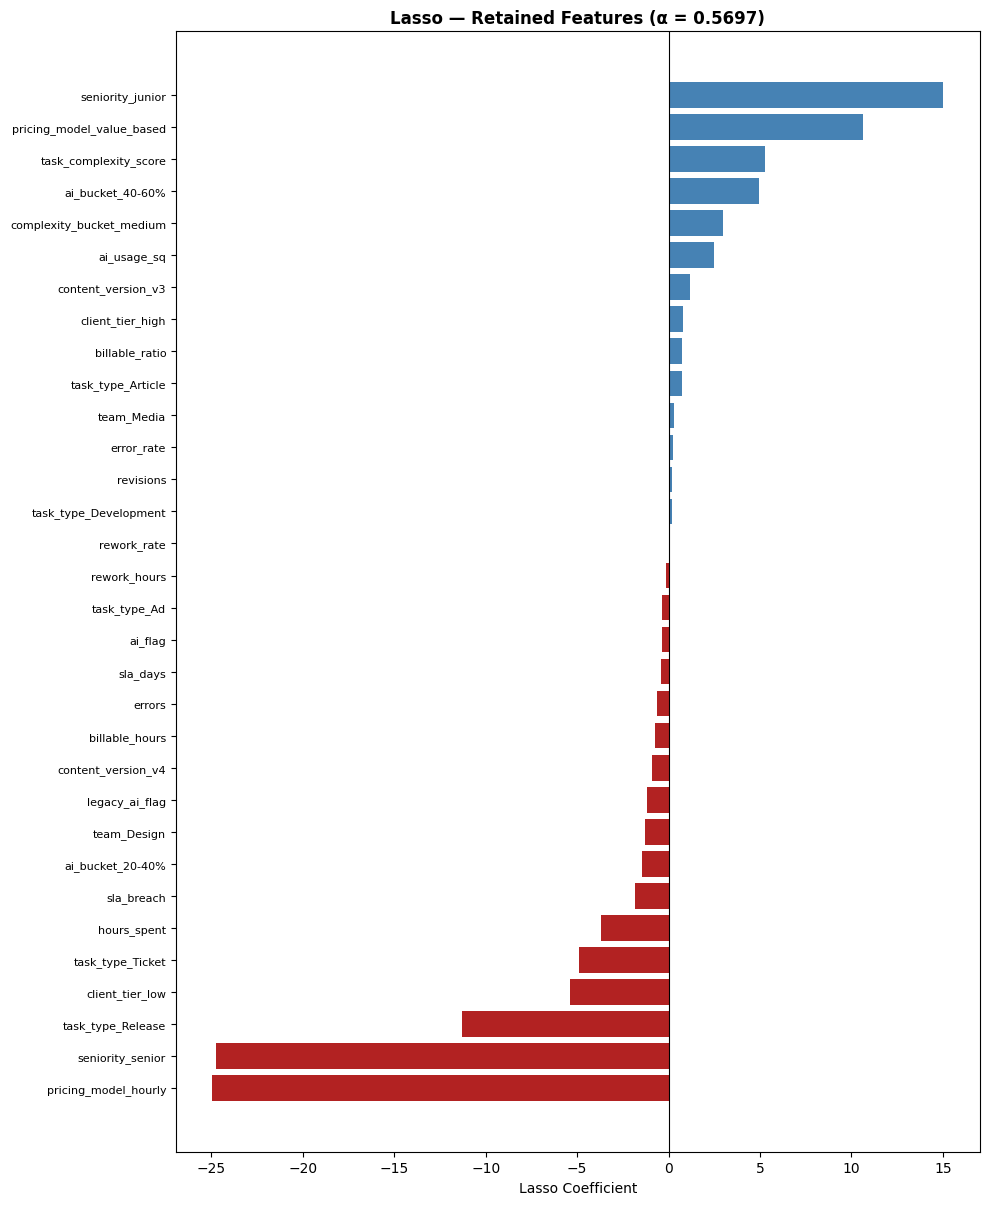

In [67]:
# ── Lasso feature selection ────────────────────────────────────────────────
preprocessor_full = build_preprocessor(NUM_FEATURES, CAT_FEATURES)

lasso_pipe = Pipeline([
    ('pre', preprocessor_full),
    ('lasso', LassoCV(cv=5, max_iter=10000, random_state=42)),
])
lasso_pipe.fit(X_train, y_train)

all_names_full = get_feature_names(lasso_pipe.named_steps['pre'], NUM_FEATURES, CAT_FEATURES)
lasso_coef = lasso_pipe.named_steps['lasso'].coef_
best_alpha = lasso_pipe.named_steps['lasso'].alpha_

nonzero_mask = lasso_coef != 0
retained_names = [n for n, m in zip(all_names_full, nonzero_mask) if m]
zeroed_names = [n for n, m in zip(all_names_full, nonzero_mask) if not m]
retained_coefs = lasso_coef[nonzero_mask]

display(pd.DataFrame({
    'Metric': [
        'Best alpha (LassoCV)',
        'Features retained',
        'Features zeroed out',
    ],
    'Value': [
        f'{best_alpha:.4f}',
        f'{nonzero_mask.sum()} / {len(lasso_coef)}',
        f'{len(zeroed_names)} / {len(lasso_coef)}',
    ]
}))

# ── Coefficient plot ───────────────────────────────────────────────────────
sort_idx = np.argsort(retained_coefs)
s_names = [retained_names[i] for i in sort_idx]
s_coefs = retained_coefs[sort_idx]
s_colors = ['steelblue' if c > 0 else 'firebrick' for c in s_coefs]

fig, ax = plt.subplots(figsize=(10, max(5, len(s_names) * 0.38)))
ax.barh(range(len(s_names)), s_coefs, color=s_colors)
ax.set_yticks(range(len(s_names)))
ax.set_yticklabels(s_names, fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lasso Coefficient')
ax.set_title(f'Lasso — Retained Features (α = {best_alpha:.4f})', fontweight='bold')
plt.tight_layout()
plt.savefig('images/lasso_coefficients_s1.png', dpi=150, bbox_inches='tight')

### Step 2: Linear Regression on Lasso-Selected Features

Lasso returns non-zero coefficients for a subset of the encoded (one-hot) features. Those encoded features are mapped back to their original column names so that the preprocessor can be rebuilt on the reduced feature set. Linear Regression is then fitted on this reduced set.

- **R², MAE, RMSE** on the held-out test set measure predictive accuracy on unseen data
- **5-fold CV R²** on the training set gives a less optimistic estimate of generalisation

The coefficient plot shows the 10 strongest positive and 10 strongest negative associations with `profit_margin`.

In [72]:
# ── Map encoded features back to original column names ────────────────────
retained_base = set()
for name in retained_names:
    if name in NUM_FEATURES:
        retained_base.add(name)
    else:
        for cat in CAT_FEATURES:
            if name.startswith(cat + '_'):
                retained_base.add(cat)
                break

lr_num  = [f for f in NUM_FEATURES if f in retained_base]
lr_cat  = [f for f in CAT_FEATURES if f in retained_base]
lr_cols = lr_num + lr_cat

# build aligned columns to avoid unequal-length lists error
features = lr_num + lr_cat
numeric_col = ['Numeric'] * len(lr_num) + [''] * len(lr_cat)
categorical_col = [''] * len(lr_num) + ['Categorical'] * len(lr_cat)

display(pd.DataFrame({
    'Numeric': numeric_col,
    'Categorical': categorical_col,
    'Feature': features,
}))

# ── Fit Linear Regression on reduced feature set ───────────────────────────
preprocessor_lr = build_preprocessor(lr_num, lr_cat)
lr_pipe = Pipeline([
    ('pre', preprocessor_lr),
    ('lr',  LinearRegression()),
])
lr_pipe.fit(X_train[lr_cols], y_train)

lr_r2, lr_mae, lr_rmse, lr_cv_r2 = eval_model(
    lr_pipe, X_train[lr_cols], X_test[lr_cols], y_train, y_test
)

display(pd.DataFrame({
    'Metric': ['Test R²', 'Test MAE (pp)', 'Test RMSE (pp)', '5-fold CV R²'],
    'Value' : [f'{lr_r2:.4f}', f'{lr_mae:.2f}', f'{lr_rmse:.2f}', f'{lr_cv_r2:.4f}'],
}).set_index('Metric'))

,Numeric,Categorical,Feature
0,Numeric,,task_complexity_score
1,Numeric,,sla_days
2,Numeric,,sla_breach
3,Numeric,,hours_spent
4,Numeric,,billable_hours
5,Numeric,,revisions
6,Numeric,,errors
7,Numeric,,rework_hours
8,Numeric,,legacy_ai_flag
9,Numeric,,ai_flag


,Value
Metric,
Test R²,0.2048
Test MAE (pp),32.06
Test RMSE (pp),48.55
5-fold CV R²,0.0832


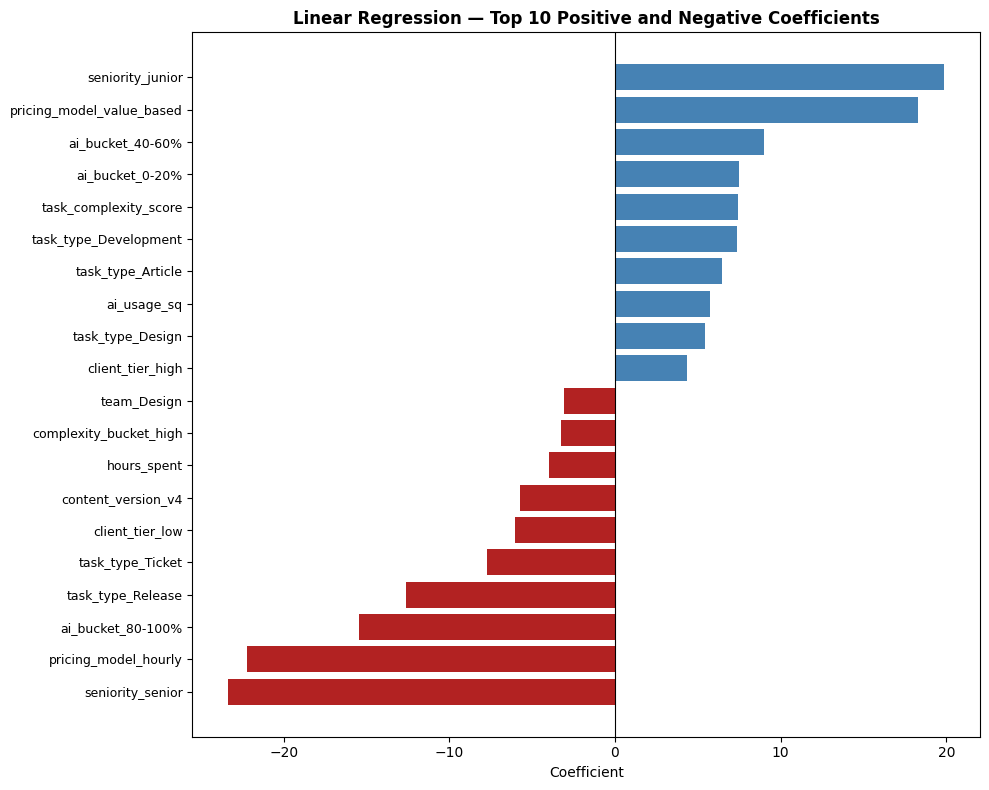

In [69]:
# ── Coefficient plot ───────────────────────────────────────────────────────
lr_feature_names = get_feature_names(lr_pipe.named_steps['pre'], lr_num, lr_cat)
coef_df = pd.DataFrame({
    'feature': lr_feature_names,
    'coef'   : lr_pipe.named_steps['lr'].coef_,
})
plot_df = pd.concat([
    coef_df.nlargest(10, 'coef'),
    coef_df.nsmallest(10, 'coef'),
]).drop_duplicates().sort_values('coef')

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['steelblue' if c > 0 else 'firebrick' for c in plot_df['coef']]
ax.barh(range(len(plot_df)), plot_df['coef'].values, color=colors)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['feature'].values, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient')
ax.set_title('Linear Regression — Top 10 Positive and Negative Coefficients', fontweight='bold')
plt.tight_layout()
plt.savefig('images/lr_coefficients_s1.png', dpi=150, bbox_inches='tight')

### Step 3: Random Forest with Grid Search

Random Forest is trained on the **full candidate feature set**, not the Lasso-reduced set. Including all candidates allows the forest to capture interactions and non-linearities that Lasso penalises to zero under L1 regularisation.

`GridSearchCV` with 5-fold CV searches over the following hyperparameters:

- `n_estimators`: 100, 200, 300
- `max_depth`: 4, 6, 8, or unconstrained
- `min_samples_leaf`: 10, 20, 40

The `min_samples_leaf` grid guards against overfitting to small leaf nodes on a dataset of this size. The best CV R² from `GridSearchCV` is reported alongside the test R² — the former is the more conservative estimate of generalisation performance.

In [73]:
# ── Random Forest with GridSearchCV ───────────────────────────────────────
preprocessor_rf = build_preprocessor(NUM_FEATURES, CAT_FEATURES)

rf_param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [4, 6, 8, None],
    'rf__min_samples_leaf': [10, 20, 40],
}

rf_pipe_base = Pipeline([
    ('pre', preprocessor_rf),
    ('rf',  RandomForestRegressor(random_state=42)),
])

rf_gs = GridSearchCV(
    rf_pipe_base, rf_param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=0,
)
rf_gs.fit(X_train, y_train)

best_rf = rf_gs.best_estimator_
rf_r2, rf_mae, rf_rmse, rf_cv_r2 = eval_model(
    best_rf, X_train, X_test, y_train, y_test
)
rf_cv_r2 = rf_gs.best_score_


In [74]:
best_params = rf_gs.best_params_
display(pd.DataFrame({
    'Parameter': ['n_estimators', 'max_depth', 'min_samples_leaf'],
    'Value'    : [
        best_params['rf__n_estimators'],
        best_params['rf__max_depth'],
        best_params['rf__min_samples_leaf'],
    ],
}).set_index('Parameter'))

display(pd.DataFrame({
    'Metric': ['Test R²', 'Test MAE (pp)', 'Test RMSE (pp)', '5-fold CV R²', 'Δ R² vs Linear Regression'],
    'Value' : [
        f'{rf_r2:.4f}',
        f'{rf_mae:.2f}',
        f'{rf_rmse:.2f}',
        f'{rf_cv_r2:.4f}',
        f'{rf_r2 - lr_r2:+.4f}',
    ],
}).set_index('Metric'))

,Value
Parameter,
n_estimators,300.0
max_depth,NaN
min_samples_leaf,10.0


,Value
Metric,
Test R²,0.3445
Test MAE (pp),27.64
Test RMSE (pp),44.08
5-fold CV R²,0.1844
Δ R² vs Linear Regression,+0.1396


### Model Comparison

The two models operate on different feature sets by design. Linear Regression uses only the features Lasso retained; Random Forest uses the full candidate set. This makes the comparison more informative than a head-to-head on identical inputs: the R² gap captures both the gain from non-linearity and the gain from features Lasso penalised to zero under its linear-additive assumption.

If Random Forest substantially outperforms Linear Regression, two explanations are possible: the data contains non-linear structure, or there are predictive features that Lasso discarded. The SHAP analysis below helps distinguish between them.

,Test R²,Test MAE (pp),Test RMSE (pp),5-fold CV R²
Model,,,,
Linear Regression,0.2048,32.0612,48.5523,0.0832
Random Forest,0.3445,27.6398,44.0835,0.1844


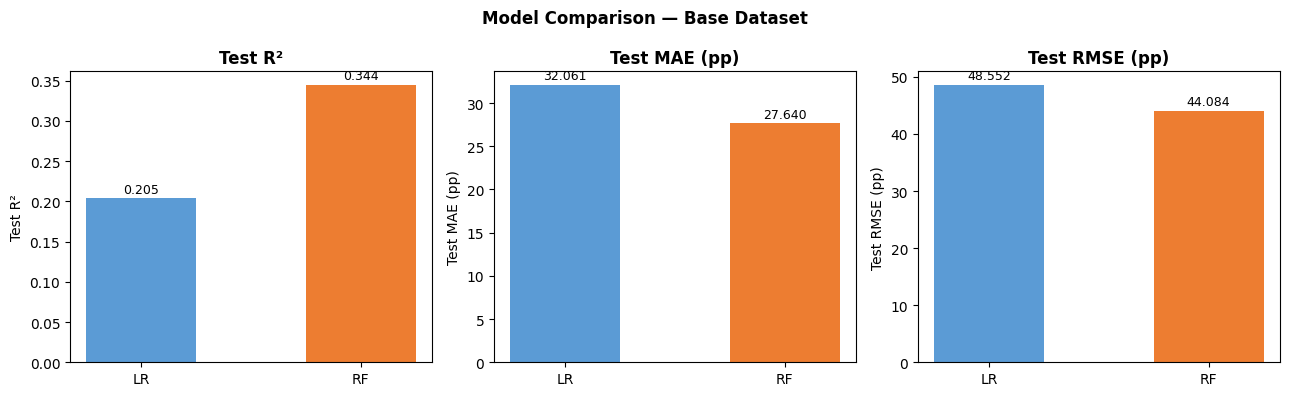

In [ ]:
# ── Model comparison table ─────────────────────────────────────────────────
s1_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'Test R²': [lr_r2,    rf_r2],
    'Test MAE (pp)': [lr_mae,   rf_mae],
    'Test RMSE (pp)': [lr_rmse,  rf_rmse],
    '5-fold CV R²': [lr_cv_r2, rf_cv_r2],
})
display(s1_results.set_index('Model').round(4))

# ── Bar chart ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics = ['Test R²', 'Test MAE (pp)', 'Test RMSE (pp)']

for ax, metric in zip(axes, metrics):
    vals = s1_results[metric].values
    bars = ax.bar(['LR', 'RF'], vals, color=['#5b9bd5', '#ed7d31'], width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9
        )
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)

plt.suptitle('Model Comparison — Base Dataset', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('images/model_comparison_s1.png', dpi=150, bbox_inches='tight')

## SHAP Analysis: Random Forest (Section 1)

`shap.TreeExplainer` computes exact Shapley values for tree-based models.
The beeswarm plot shows the 15 features with the highest mean absolute SHAP value.
Each point is one test observation; colour encodes the feature value (red = high, blue = low).

The dependence plot for `ai_usage_pct` shows how the model's output shifts across
the range of AI usage, with point colour indicating the value of the feature
that SHAP identifies as most interactive with `ai_usage_pct`.

After the plots, a cross-check against the Lasso-selected features identifies
which predictors are supported by both methods.


### SHAP Analysis: Interpretation

The beeswarm plot and ranking table identify **pricing model, billable ratio, and seniority** as the dominant drivers of `profit_margin`, collectively accounting for the three highest mean absolute SHAP values. `ai_usage_pct` ranks 14th out of all features, confirming that AI usage intensity has a statistically detectable but relatively modest direct contribution to margin in the context of the full feature set.

**Key findings by feature:**

- **`pricing_model_hourly`** (rank 1, mean |SHAP| = 15.23): the single strongest predictor. Tasks billed on an hourly basis are associated with large negative SHAP values, meaning hourly pricing systematically compresses `profit_margin`. This is structurally expected: under hourly billing, productivity gains from AI reduce billable hours and therefore revenue, rather than expanding margin;
- **`billable_ratio`** (rank 2, mean |SHAP| = 12.49): tasks where a higher share of hours are billable show higher margins, as expected;
- **`seniority_senior` / `seniority_junior`** (ranks 3 and 5): senior workers are associated with higher margins, junior workers with lower ones, likely reflecting differences in task complexity, revision rates, and billing rates;
- **`hours_spent`** (rank 4): longer tasks are associated with lower margins, consistent with cost overruns on fixed-price or value-based contracts;
- **`ai_usage_pct`** (rank 14, mean |SHAP| = 0.70): a positive directional effect is visible in the dependence plot. SHAP values for `ai_usage_pct` rise as AI usage increases, confirming the threshold finding from the EDA. However, the magnitude is small relative to structural factors such as pricing model and seniority

**Dependence plot for `ai_usage_pct`:** the SHAP values for `ai_usage_pct` show a clear upward trend from roughly −1 to +2 on the x-axis, indicating that higher AI usage is associated with a progressively more positive contribution to predicted margin. The interaction colour (pink = hourly pricing, blue = non-hourly) reveals that the positive effect is more pronounced for non-hourly tasks. Under hourly billing, in fact, the margin benefit of AI usage is substantially attenuated, reinforcing the pricing model interaction identified in the EDA.

ai_usage_pct SHAP rank: 14 / 57


,Feature,Mean |SHAP|
1,pricing_model_hourly,15.2346
2,billable_ratio,12.4893
3,seniority_senior,10.1451
4,hours_spent,7.1973
5,seniority_junior,3.5964
6,task_complexity_score,3.1197
7,task_type_Ad,1.3961
8,billable_hours,1.3137
9,seniority_mid,1.1302
10,rework_rate,1.0913


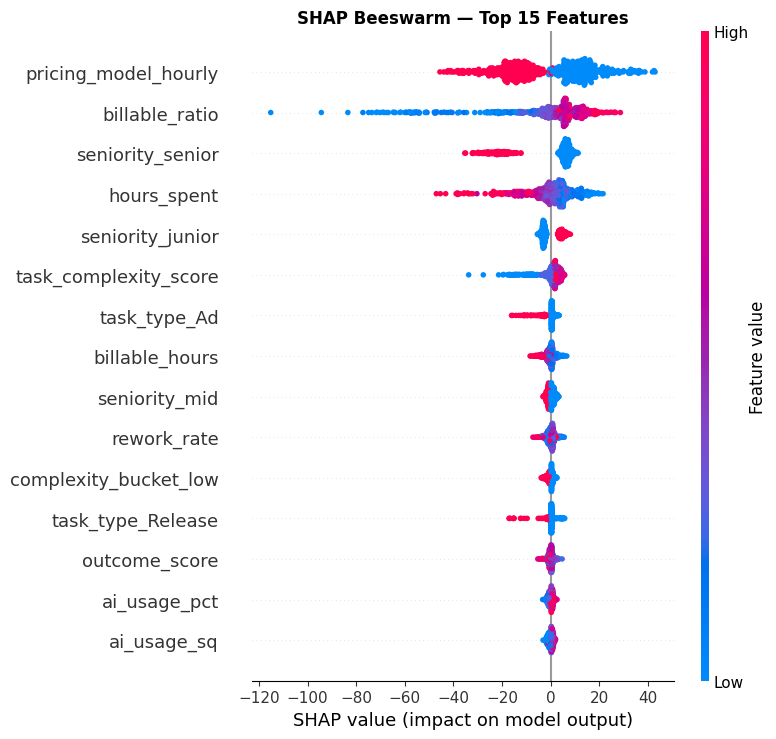

<Figure size 800x500 with 0 Axes>

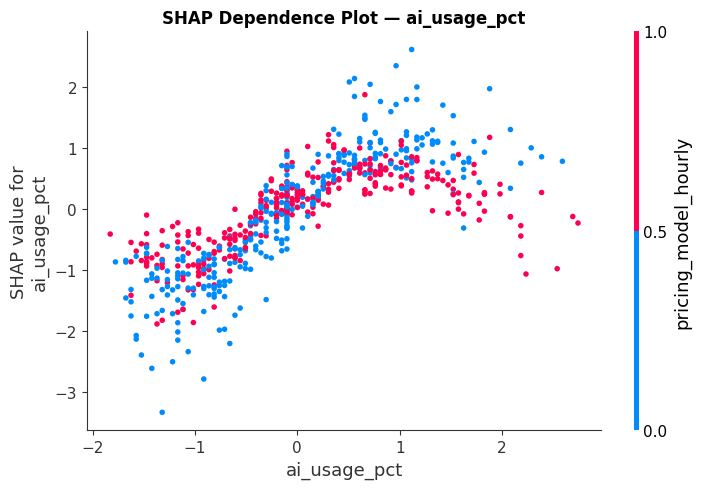

In [ ]:
# ── SHAP values ────────────────────────────────────────────────────────────
X_test_tr = best_rf.named_steps['pre'].transform(X_test)
rf_feature_names = get_feature_names(best_rf.named_steps['pre'], NUM_FEATURES, CAT_FEATURES)

explainer = shap.TreeExplainer(best_rf.named_steps['rf'])
shap_values = explainer.shap_values(X_test_tr)

mean_abs = np.abs(shap_values).mean(axis=0)
shap_rank_df = (
    pd.DataFrame({'Feature': rf_feature_names, 'Mean |SHAP|': mean_abs})
    .sort_values('Mean |SHAP|', ascending=False)
    .reset_index(drop=True)
)
shap_rank_df.index += 1

ai_rank = shap_rank_df[shap_rank_df['Feature'] == 'ai_usage_pct'].index[0]
print(f'ai_usage_pct SHAP rank: {ai_rank} / {len(rf_feature_names)}')
display(shap_rank_df.head(15).round(4))

# ── Beeswarm plot ──────────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_tr,
    feature_names=rf_feature_names,
    max_display=15, show=False
)
plt.title('SHAP Beeswarm: Top 15 Features', fontweight='bold')
plt.tight_layout()
plt.savefig('images/shap_beeswarm_s1.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Dependence plot ────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
shap.dependence_plot(
    'ai_usage_pct', shap_values, X_test_tr,
    feature_names=rf_feature_names, show=False
)
plt.title('SHAP Dependence Plot: ai_usage_pct', fontweight='bold')
plt.tight_layout()
plt.savefig('images/shap_dependence_ai_s1.png', dpi=150, bbox_inches='tight')

### SHAP vs Lasso Cross-Check

Lasso retained features based on a linear, regularised model. SHAP ranks features by their average marginal contribution to the Random Forest's predictions, capturing both linear and non-linear effects.
The cross-check confirms strong agreement between the two methods:
- **11 out of 15 SHAP top features were also retained by Lasso**, indicating that the dominant margin drivers are robust across both linear and non-linear assumptions.
- The four features in SHAP top 15 but zeroed by Lasso (`ai_usage_pct`, `outcome_score`, `complexity_bucket_low`, and `seniority_mid`) contribute to the Random Forest's predictions through non-linear or interaction effects that L1 penalisation cannot capture. Notably, `ai_usage_pct` falls into this category, which is consistent with the threshold pattern identified in the EDA: its relationship with `profit_margin` is non-linear and therefore invisible to a linear selector.
- The 21 features retained by Lasso but ranking outside the SHAP top 15 carry redundant linear signal that the forest distributes across correlated features: they are not meaningless, but their individual marginal contribution is small once the dominant predictors are accounted for.

In [ ]:
# ── SHAP vs Lasso Cross-Check ──────────────────────────────────────────────
shap_top15 = set(shap_rank_df.head(15)['Feature'])
lasso_retained = set(retained_names)

both = shap_top15 & lasso_retained
shap_only = shap_top15 - lasso_retained
lasso_only = lasso_retained - shap_top15

cross_check = pd.DataFrame({
    'Feature': sorted(both) + sorted(shap_only) + sorted(lasso_only),
    'SHAP Top 15': ['✓'] * len(both) + ['✓'] * len(shap_only) + [''] * len(lasso_only),
    'Lasso Retained': ['✓'] * len(both) + [''] * len(shap_only) + ['✓'] * len(lasso_only),
    'Category': ['High rank in both'] * len(both) +
                     ['High SHAP, zeroed by Lasso'] * len(shap_only) +
                     ['Retained by Lasso, low SHAP'] * len(lasso_only),
})

display(cross_check.set_index('Feature'))

,SHAP Top 15,Lasso Retained,Category
Feature,,,
ai_usage_sq,✓,✓,High rank in both
billable_hours,✓,✓,High rank in both
billable_ratio,✓,✓,High rank in both
hours_spent,✓,✓,High rank in both
pricing_model_hourly,✓,✓,High rank in both
rework_rate,✓,✓,High rank in both
seniority_junior,✓,✓,High rank in both
seniority_senior,✓,✓,High rank in both
task_complexity_score,✓,✓,High rank in both


### Log-transformed Features

Several numeric features in this dataset have strongly right-skewed distributions: a small number of tasks with very high hours, rework, or revenue pull the tail far from the median. Applying `np.log1p` compresses the long tail, brings the distribution closer to symmetric, and improves the linearity assumption that OLS and Lasso rely on.

The transformation is applied only to features where the interpretation is preserved after compression: `hours_spent`, `billable_hours`, `rework_hours`, `revenue`, `cost`, `errors`, `revisions`. 

All other features, including engineered ratios, boolean flags, and categorical variables, are left unchanged. The target variable `profit_margin` is not transformed, as it contains negative values.

> **Note:** Random Forest makes no linearity assumption and is invariant to monotonic feature transformations. Any difference in RF performance between the two sections is expected to be negligible. The log transform is a diagnostic for the linear models only, so RF is included purely as a methodological control.

In [81]:
# ── Log-transform selected features ───────────────────────────────────────
LOG_COLS = ['hours_spent', 'billable_hours', 'rework_hours', 'revenue', 'cost',
            'errors', 'revisions']

df_log = df_productivity.copy()
df_log[LOG_COLS] = np.log1p(df_log[LOG_COLS])

### Visual Verification of Log-transform Effect

Before fitting models on `df_log`, we visually confirm that the transformation achieved its intended effect on each feature's distribution. The statistical justification for log-transforming, reducing right skew, must be verified empirically, not simply assumed. A feature that was already approximately symmetric would not benefit from the transform and could be left in its original scale without loss.

The grid below shows, for each transformed feature, the original distribution (left, blue) and the log-transformed distribution (right, green). Skewness values are reported in each subplot title.

The plots confirm that `log1p` substantially reduced right skew across all seven features, with the largest improvements in `hours_spent` (9.95 → 0.03), `rework_hours` (7.76 → 0.44), `cost` (5.54 → 0.16), and `revenue` (4.72 → −0.20). These four features had the most extreme original distributions and are therefore where OLS was most constrained by scale.
`billable_hours` (1.59 → −0.04) and `errors` (1.06 → 0.17) were already moderately skewed before the transform and reached near-symmetry after it. `revisions` (0.56 → −0.64) was the closest to symmetric before transformation and shows the smallest benefit: the transform slightly over-corrects it toward a mild left skew, though the magnitude is not large enough to warrant concern.

Notably, `errors` and `revisions` are discrete count variables, which explains the comb-like histogram shape visible both before and after the transform. The KDE overlay is less informative for these two features, but the skewness reduction is still real and the log scale brings the sparse high-count observations closer to the bulk of the data.

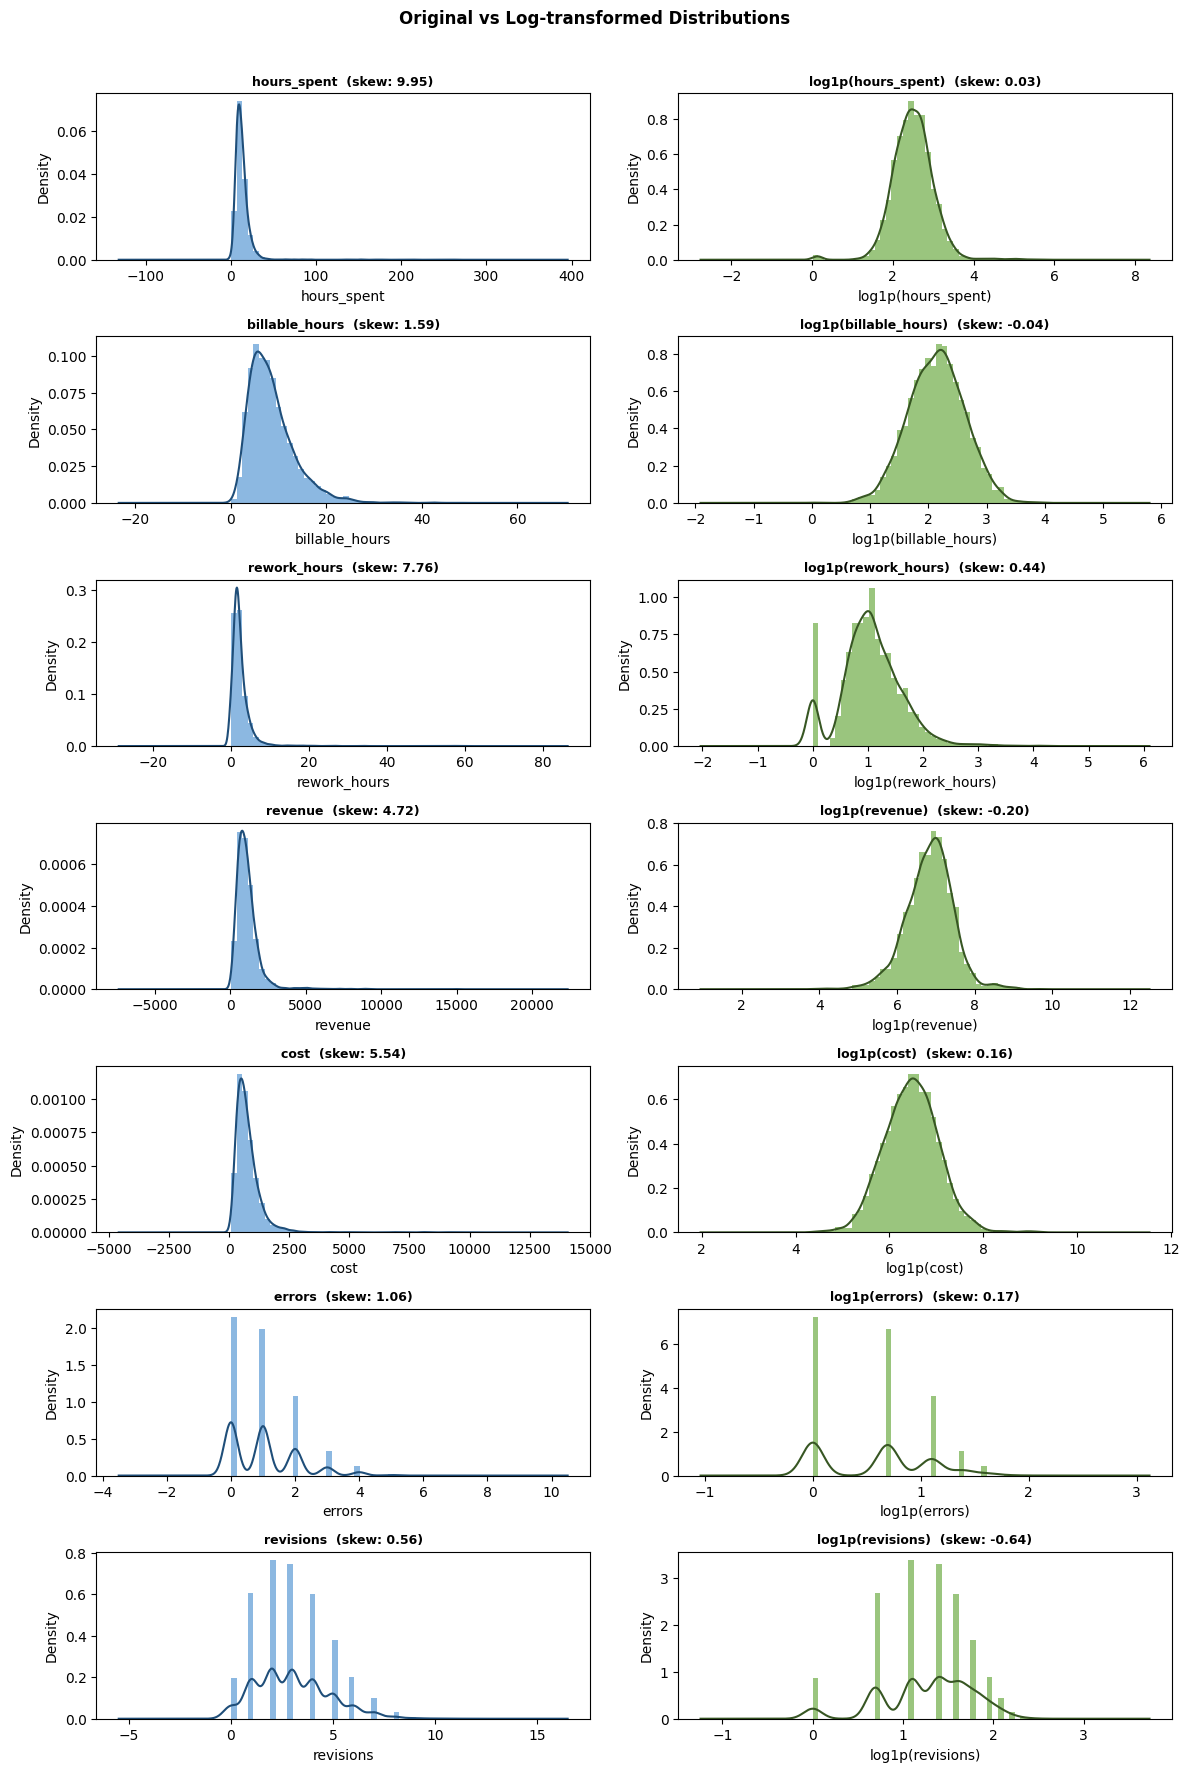

In [83]:
# ── Distribution comparison: original vs log-transformed ──────────────────
fig, axes = plt.subplots(len(LOG_COLS), 2, figsize=(12, len(LOG_COLS) * 2.5))

for row, col in enumerate(LOG_COLS):
    skew_orig = df_productivity[col].skew()
    skew_log  = df_log[col].skew()

    # ── Original ───────────────────────────────────────────────────────────
    ax_orig = axes[row, 0]
    ax_orig.hist(df_productivity[col].dropna(), bins=40, color='#5b9bd5', alpha=0.7, density=True)
    df_productivity[col].dropna().plot.kde(ax=ax_orig, color='#1f4e79', linewidth=1.5)
    ax_orig.set_title(f'{col}  (skew: {skew_orig:.2f})', fontsize=9, fontweight='bold')
    ax_orig.set_xlabel(col)
    ax_orig.set_ylabel('Density')

    # ── Log-transformed ────────────────────────────────────────────────────
    ax_log = axes[row, 1]
    ax_log.hist(df_log[col].dropna(), bins=40, color='#70ad47', alpha=0.7, density=True)
    df_log[col].dropna().plot.kde(ax=ax_log, color='#375623', linewidth=1.5)
    ax_log.set_title(f'log1p({col})  (skew: {skew_log:.2f})', fontsize=9, fontweight='bold')
    ax_log.set_xlabel(f'log1p({col})')
    ax_log.set_ylabel('Density')

plt.suptitle('Original vs Log-transformed Distributions', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/log_distribution_comparison.png', dpi=150, bbox_inches='tight')

### Train / Test Split

The same 80/20 split is applied to `df_log`.

In [84]:
# ── Train / test split ─────────────────────────────────────────────────────
X_log = df_log[CANDIDATE_FEATURES]
y_log = df_log[TARGET]

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
)

display(pd.DataFrame({
    'Set'  : ['Train', 'Test'],
    'Rows' : [X_train_log.shape[0], X_test_log.shape[0]],
    'Share': ['80%', '20%'],
}))

,Set,Rows,Share
0,Train,2560,80%
1,Test,640,20%


### Step 1: Lasso Feature Selection + Linear Regression

`LassoCV` selects the feature subset on the log-transformed training data. If skew correction improves the linear signal, we expect Lasso to retain more features or assign larger coefficients to the transformed numeric variables, and LR test R² to increase relative to Section 1.
The log-transformed Lasso selects **28 features** at α = 0.6109, retaining the same core predictors identified in Section 1. The performance metrics confirm the expected improvement: LR test R² rises from 0.2048 to **0.2487** (+0.0439), with a corresponding reduction in MAE from 32.06 to 30.65 pp.

The coefficient plots are consistent with Section 1 in terms of directionality:

- **`pricing_model_hourly`** and **`seniority_senior`** remain the strongest negative predictors: hourly billing and senior worker assignment are both associated with lower margins, the former because AI productivity gains reduce billable hours under this pricing structure;
- **`seniority_junior`**, **`billable_hours`**, and **`pricing_model_value_based`** are the strongest positive predictors, with `seniority_junior` showing the largest positive coefficient in both sections;
- **`hours_spent`** retains a large negative coefficient, confirming that longer tasks compress margins regardless of AI usage;

One notable difference from Section 1 is that `ai_bucket_40-60%` and `ai_bucket_0-20%` now appear among the top positive coefficients in the LR plot, suggesting that after log-transforming the scale-dominated features, the AI usage signal becomes more visible to the linear model. This is consistent with the SHAP finding that `ai_usage_pct` was contributing through non-linear effects that OLS previously could not isolate.

,Value
Metric,
Best alpha (LassoCV),0.6109
Features retained,27 / 57
Features zeroed out,30 / 57


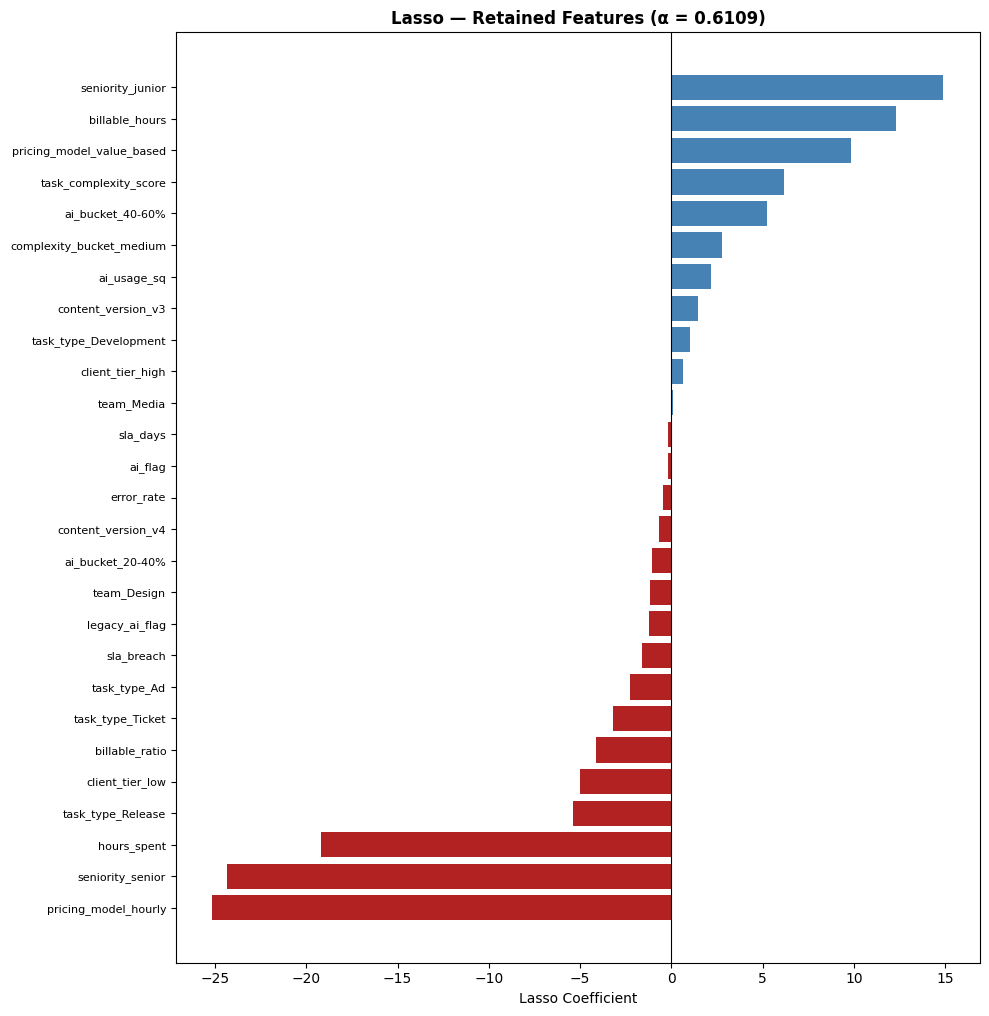

In [85]:
# ── Lasso feature selection ────────────────────────────────────────────────
preprocessor_full_log = build_preprocessor(NUM_FEATURES, CAT_FEATURES)

lasso_pipe_log = Pipeline([
    ('pre',   preprocessor_full_log),
    ('lasso', LassoCV(cv=5, max_iter=10000, random_state=42)),
])
lasso_pipe_log.fit(X_train_log, y_train_log)

all_names_log = get_feature_names(lasso_pipe_log.named_steps['pre'], NUM_FEATURES, CAT_FEATURES)
lasso_coef_log = lasso_pipe_log.named_steps['lasso'].coef_
best_alpha_log = lasso_pipe_log.named_steps['lasso'].alpha_
nonzero_mask_log = lasso_coef_log != 0
retained_names_log = [n for n, m in zip(all_names_log, nonzero_mask_log) if m]
retained_coefs_log = lasso_coef_log[nonzero_mask_log]

display(pd.DataFrame({
    'Metric': ['Best alpha (LassoCV)', 'Features retained', 'Features zeroed out'],
    'Value' : [
        f'{best_alpha_log:.4f}',
        f'{nonzero_mask_log.sum()} / {len(lasso_coef_log)}',
        f'{(~nonzero_mask_log).sum()} / {len(lasso_coef_log)}',
    ],
}).set_index('Metric'))

# ── Lasso coefficient plot ─────────────────────────────────────────────────
sort_idx_log = np.argsort(retained_coefs_log)
s_names_log = [retained_names_log[i] for i in sort_idx_log]
s_coefs_log = retained_coefs_log[sort_idx_log]
s_colors_log = ['steelblue' if c > 0 else 'firebrick' for c in s_coefs_log]

fig, ax = plt.subplots(figsize=(10, max(5, len(s_names_log) * 0.38)))
ax.barh(range(len(s_names_log)), s_coefs_log, color=s_colors_log)
ax.set_yticks(range(len(s_names_log)))
ax.set_yticklabels(s_names_log, fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lasso Coefficient')
ax.set_title(f'Lasso — Retained Features (α = {best_alpha_log:.4f})', fontweight='bold')
plt.tight_layout()
plt.savefig('images/lasso_coefficients_s2.png', dpi=150, bbox_inches='tight')

,Type,Feature
0,Numeric,task_complexity_score
1,Numeric,sla_days
2,Numeric,sla_breach
3,Numeric,hours_spent
4,Numeric,billable_hours
5,Numeric,legacy_ai_flag
6,Numeric,ai_flag
7,Numeric,error_rate
8,Numeric,billable_ratio
9,Numeric,ai_usage_sq


,Value
Metric,
Test R²,0.2487
Test MAE (pp),30.65
Test RMSE (pp),47.19
5-fold CV R²,0.1069
Δ R² vs Section 1 LR,+0.0439


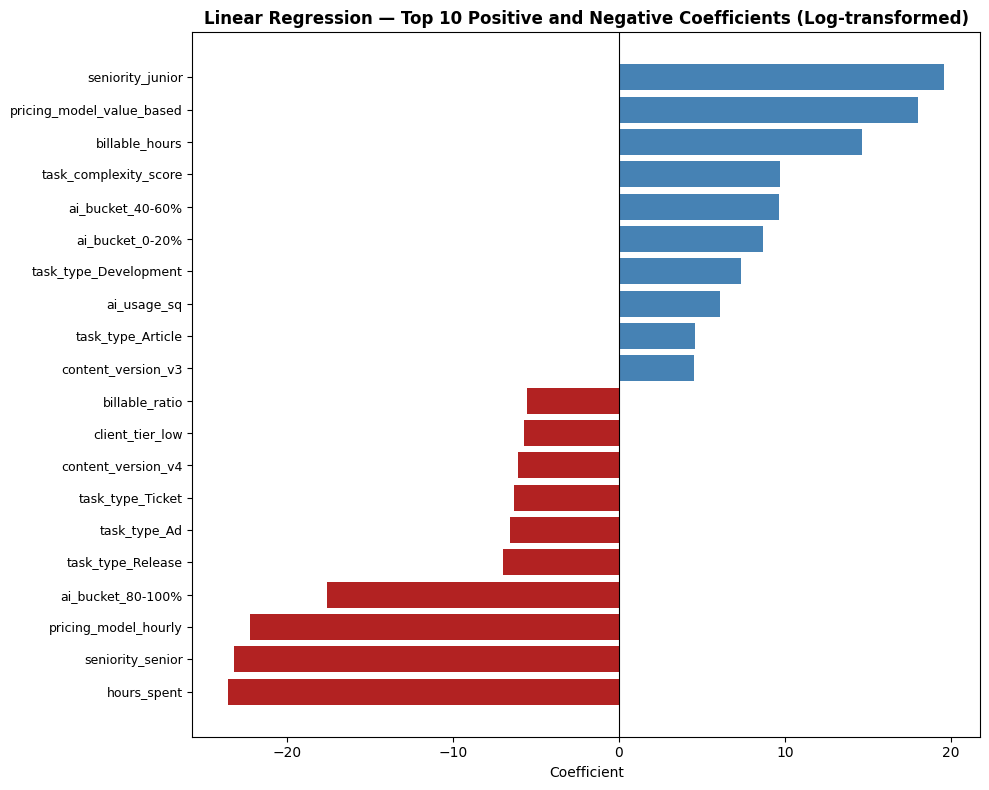

In [ ]:
# ── LR on Lasso-selected features ─────────────────────────────────────────
retained_base_log = set()
for name in retained_names_log:
    if name in NUM_FEATURES:
        retained_base_log.add(name)
    else:
        for cat in CAT_FEATURES:
            if name.startswith(cat + '_'):
                retained_base_log.add(cat)
                break

lr_num_log = [f for f in NUM_FEATURES if f in retained_base_log]
lr_cat_log  = [f for f in CAT_FEATURES if f in retained_base_log]
lr_cols_log = lr_num_log + lr_cat_log

display(pd.DataFrame({
    'Type'   : ['Numeric'] * len(lr_num_log) + ['Categorical'] * len(lr_cat_log),
    'Feature': lr_num_log + lr_cat_log,
}))

preprocessor_lr_log = build_preprocessor(lr_num_log, lr_cat_log)
lr_pipe_log = Pipeline([
    ('pre', preprocessor_lr_log),
    ('lr',  LinearRegression()),
])
lr_pipe_log.fit(X_train_log[lr_cols_log], y_train_log)

lr_r2_log, lr_mae_log, lr_rmse_log, lr_cv_r2_log = eval_model(
    lr_pipe_log, X_train_log[lr_cols_log], X_test_log[lr_cols_log], y_train_log, y_test_log
)

display(pd.DataFrame({
    'Metric': ['Test R²', 'Test MAE (pp)', 'Test RMSE (pp)', '5-fold CV R²', 'Δ R² vs Section 1 LR'],
    'Value' : [
        f'{lr_r2_log:.4f}',
        f'{lr_mae_log:.2f}',
        f'{lr_rmse_log:.2f}',
        f'{lr_cv_r2_log:.4f}',
        f'{lr_r2_log - lr_r2:+.4f}',
    ],
}).set_index('Metric'))

# ── LR coefficient plot ────────────────────────────────────────────────────
lr_feature_names_log = get_feature_names(lr_pipe_log.named_steps['pre'], lr_num_log, lr_cat_log)
coef_df_log = pd.DataFrame({
    'feature': lr_feature_names_log,
    'coef'   : lr_pipe_log.named_steps['lr'].coef_,
})
plot_df_log = pd.concat([
    coef_df_log.nlargest(10, 'coef'),
    coef_df_log.nsmallest(10, 'coef'),
]).drop_duplicates().sort_values('coef')

fig, ax = plt.subplots(figsize=(10, 8))
colors_log = ['steelblue' if c > 0 else 'firebrick' for c in plot_df_log['coef']]
ax.barh(range(len(plot_df_log)), plot_df_log['coef'].values, color=colors_log)
ax.set_yticks(range(len(plot_df_log)))
ax.set_yticklabels(plot_df_log['feature'].values, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient')
ax.set_title('Linear Regression — Top 10 Positive and Negative Coefficients (Log-transformed)', fontweight='bold')
plt.tight_layout()
plt.savefig('images/lr_coefficients_s2.png', dpi=150, bbox_inches='tight')

### Step 2: Random Forest on Log-transformed Features

Random Forest splits are based on rank order rather than absolute values, so any monotonic transformation — including `log1p` — leaves the optimal split thresholds and resulting predictions unchanged in expectation. The RF is included here not to improve performance but to **confirm the invariance empirically**: the test R² should be within rounding noise of the Section 1 result (0.3445), serving as a built-in methodological control for the experiment.

The Random Forest on the log-transformed dataset produces a test R² of **0.3445**, identical to Section 1. MAE and RMSE are likewise unchanged at 27.64 pp and 44.08 pp respectively. The best hyperparameters are also consistent with Section 1: 300 estimators, unconstrained depth, and a minimum leaf size of 10.

This result is the expected outcome and serves as empirical confirmation of the invariance property: `log1p` is a monotonic transformation, so the rank ordering of any feature's values is preserved and the forest finds identical split boundaries. The zero delta provides a clean methodological control: any difference in overall model performance between Section 1 and Section 2 is attributable entirely to the log transform's effect on the **linear models**, not to any change in the data's underlying structure.

In [ ]:
# ── Random Forest on log-transformed features (GridSearchCV) ──────────────
preprocessor_rf_log = build_preprocessor(NUM_FEATURES, CAT_FEATURES)

rf_pipe_base_log = Pipeline([
    ('pre', preprocessor_rf_log),
    ('rf',  RandomForestRegressor(random_state=42)),
])

rf_gs_log = GridSearchCV(
    rf_pipe_base_log, rf_param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=0,
)
rf_gs_log.fit(X_train_log, y_train_log)

best_rf_log  = rf_gs_log.best_estimator_
rf_r2_log, rf_mae_log, rf_rmse_log, rf_cv_r2_log = eval_model(
    best_rf_log, X_train_log, X_test_log, y_train_log, y_test_log
)
rf_cv_r2_log = rf_gs_log.best_score_

In [ ]:
best_params_log = rf_gs_log.best_params_
display(pd.DataFrame({
    'Parameter': ['n_estimators', 'max_depth', 'min_samples_leaf'],
    'Value'    : [
        best_params_log['rf__n_estimators'],
        best_params_log['rf__max_depth'],
        best_params_log['rf__min_samples_leaf'],
    ],
}).set_index('Parameter'))

display(pd.DataFrame({
    'Metric': ['Test R²', 'Test MAE (pp)', 'Test RMSE (pp)', '5-fold CV R²', 'Δ R² vs Section 1 RF'],
    'Value' : [
        f'{rf_r2_log:.4f}',
        f'{rf_mae_log:.2f}',
        f'{rf_rmse_log:.2f}',
        f'{rf_cv_r2_log:.4f}',
        f'{rf_r2_log - rf_r2:+.4f}',
    ],
}).set_index('Metric'))

,Value
Parameter,
n_estimators,300.0
max_depth,NaN
min_samples_leaf,10.0


,Value
Metric,
Test R²,0.3445
Test MAE (pp),27.64
Test RMSE (pp),44.08
5-fold CV R²,0.1843
Δ R² vs Section 1 RF,-0.0000


### SHAP Analysis: Random Forest (Log-transformed)

`shap.TreeExplainer` is applied to the Random Forest fitted on `df_log` using the same procedure as Section 1. The beeswarm and dependence plots are regenerated on the log-transformed test set.

Because Random Forest is invariant to monotonic feature transformations, we expect the feature importance rankings to be **stable** between Section 1 and Section 2. Large rank changes would indicate that a feature's apparent importance in Section 1 was an artefact of scale rather than a genuine relationship — a finding that would call the Section 1 SHAP interpretation into question.

### Findings
The SHAP rankings on the log-transformed dataset are **identical to Section 1** across all 15 positions: same features, same order, and mean |SHAP| values matching to four decimal places. 
`pricing_model_hourly` (15.23), `billable_ratio` (12.49), and `seniority_senior` (10.15) remain the top three predictors, and `ai_usage_pct` holds rank 14 at 0.70.

This result directly confirms the invariance property: the Random Forest learned the same relationships from the log-transformed data as from the original data, because the rank ordering of all feature values is preserved under `log1p`. No feature's importance shifted as a result of the transformation, ruling out scale artefacts as a confound in the Section 1 SHAP interpretation.

The dependence plot for `ai_usage_pct` is likewise unchanged: SHAP values rise progressively with AI usage intensity, and the pricing model interaction (pink = hourly, blue = non-hourly) shows the same pattern where the margin benefit of higher AI adoption is attenuated under hourly billing, while more pronounced under fixed or value-based contracts. The stability of this plot across both sections confirms that the positive AI-margin relationship identified in the EDA is a genuine signal, not an artefact of the original feature scale.

ai_usage_pct SHAP rank: 14 / 57


,Feature,Mean |SHAP|
1,pricing_model_hourly,15.2320
2,billable_ratio,12.4893
3,seniority_senior,10.1460
4,hours_spent,7.1981
5,seniority_junior,3.5966
6,task_complexity_score,3.1206
7,task_type_Ad,1.3961
8,billable_hours,1.3137
9,seniority_mid,1.1301
10,rework_rate,1.0911


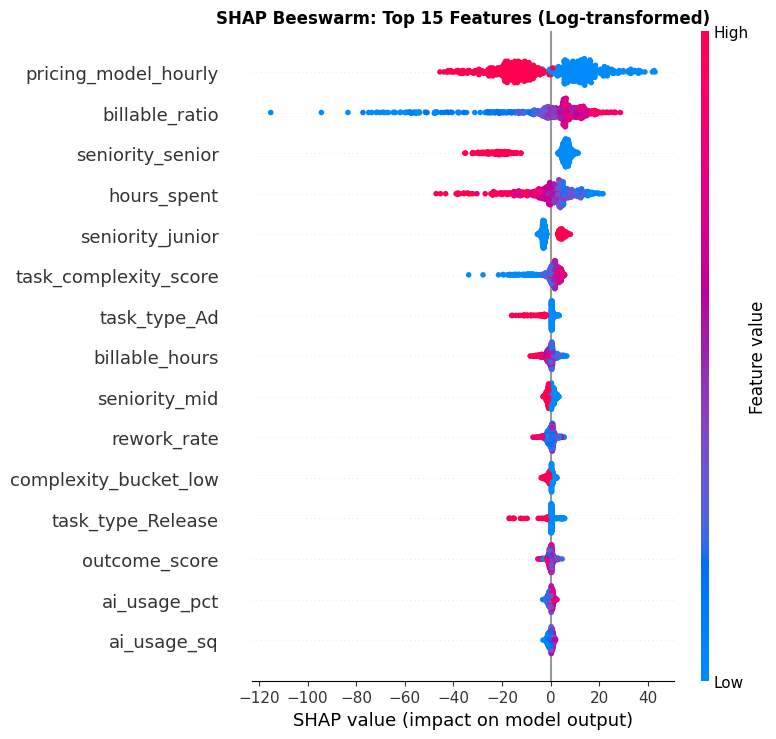

<Figure size 800x500 with 0 Axes>

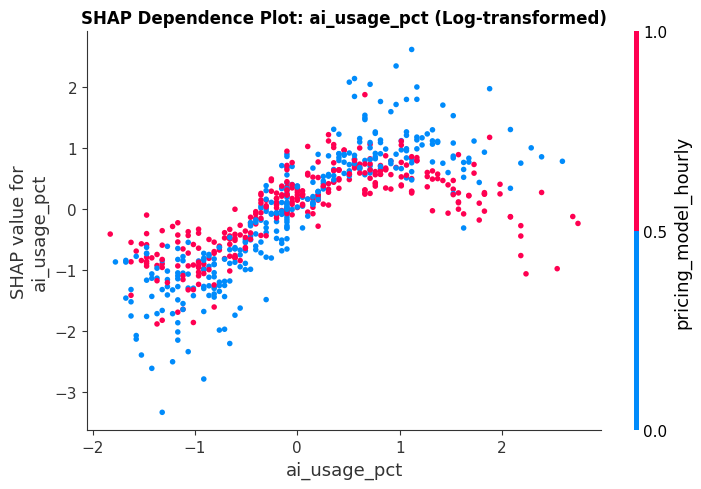

In [90]:
# ── SHAP values (log-transformed) ─────────────────────────────────────────
X_test_tr_log = best_rf_log.named_steps['pre'].transform(X_test_log)
rf_feature_names_log = get_feature_names(best_rf_log.named_steps['pre'], NUM_FEATURES, CAT_FEATURES)

explainer_log = shap.TreeExplainer(best_rf_log.named_steps['rf'])
shap_values_log = explainer_log.shap_values(X_test_tr_log)

mean_abs_log = np.abs(shap_values_log).mean(axis=0)
shap_rank_df_log = (
    pd.DataFrame({'Feature': rf_feature_names_log, 'Mean |SHAP|': mean_abs_log})
    .sort_values('Mean |SHAP|', ascending=False)
    .reset_index(drop=True)
)
shap_rank_df_log.index += 1

ai_rank_log = shap_rank_df_log[shap_rank_df_log['Feature'] == 'ai_usage_pct'].index[0]
print(f'ai_usage_pct SHAP rank: {ai_rank_log} / {len(rf_feature_names_log)}')
display(shap_rank_df_log.head(15).round(4))

# ── Beeswarm plot ──────────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_log, X_test_tr_log,
    feature_names=rf_feature_names_log,
    max_display=15, show=False
)
plt.title('SHAP Beeswarm: Top 15 Features (Log-transformed)', fontweight='bold')
plt.tight_layout()
plt.savefig('images/shap_beeswarm_s2.png', dpi=150, bbox_inches='tight')

# ── Dependence plot ────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
shap.dependence_plot(
    'ai_usage_pct', shap_values_log, X_test_tr_log,
    feature_names=rf_feature_names_log, show=False
)
plt.title('SHAP Dependence Plot: ai_usage_pct (Log-transformed)', fontweight='bold')
plt.tight_layout()
plt.savefig('images/shap_dependence_ai_s2.png', dpi=150, bbox_inches='tight')

### Model Comparison: Section 1 vs Section 2

The table below places all four model configurations side by side. 
- A meaningful improvement in LR R² confirms that right-skew was a binding constraint on OLS;
- A negligible change in RF R² confirms the invariance expectation;
- The delta columns make the differences explicit.

### Interpretation

The log transform produced a LR R² gain of **+0.0439** (from 0.2048 to 0.2487), with a corresponding MAE reduction of 1.41 pp (from 32.06 to 30.65). This confirms that right-skewed feature distributions were a binding constraint on OLS: the extreme values in `hours_spent`, `rework_hours`, `revenue`, and `cost` were pulling the least-squares solution away from the underlying linear signal, and compressing those tails via `log1p` partially restores it.

The RF R² delta is exactly **0.0000** (0.3445 in both sections), with MAE and RMSE likewise unchanged to two decimal places. This is the methodological validation of the experiment: because Random Forest is theoretically invariant to monotonic feature transformations, a zero delta confirms the RF is acting as a built-in control. The LR improvement can therefore be attributed entirely to the distributional correction, not to any data artefact or information leak introduced during the transformation.

The remaining gap between LR (0.2487) and RF (0.3445) after the transform shows that non-linear interactions persist in the data that OLS cannot capture regardless of input scale. Log-transforming closes part of the gap but not all of it: the feature-margin relationship is non-linear beyond the scale correction, and a flexible model is needed to capture the full signal available in the dataset.

In [91]:
# ── Comparison table ───────────────────────────────────────────────────────
comparison_log = pd.DataFrame({
    'Dataset'       : ['Base', 'Base', 'Log-transformed', 'Log-transformed'],
    'Model'         : ['Linear Regression', 'Random Forest',
                       'Linear Regression', 'Random Forest'],
    'Test R²'       : [lr_r2,   rf_r2,   lr_r2_log,   rf_r2_log],
    'Test MAE (pp)' : [lr_mae,  rf_mae,  lr_mae_log,  rf_mae_log],
    'Test RMSE (pp)': [lr_rmse, rf_rmse, lr_rmse_log, rf_rmse_log],
})
display(comparison_log.set_index(['Dataset', 'Model']).round(4))

delta_log = pd.DataFrame({
    'Model'                  : ['Linear Regression', 'Random Forest'],
    'Δ R² (Log − Base)'      : [lr_r2_log  - lr_r2,  rf_r2_log  - rf_r2],
    'Δ MAE (Log − Base) (pp)': [lr_mae_log - lr_mae, rf_mae_log - rf_mae],
})
display(delta_log.set_index('Model').round(4))

Test R²  Test MAE (pp)  Test RMSE (pp)
Dataset         Model                                                    
Base            Linear Regression   0.2048        32.0612         48.5523
                Random Forest       0.3445        27.6398         44.0835
Log-transformed Linear Regression   0.2487        30.6535         47.1942
                Random Forest       0.3445        27.6425         44.0842

,Δ R² (Log − Base),Δ MAE (Log − Base) (pp)
Model,,
Linear Regression,0.0439,-1.4076
Random Forest,-0.0000,0.0027


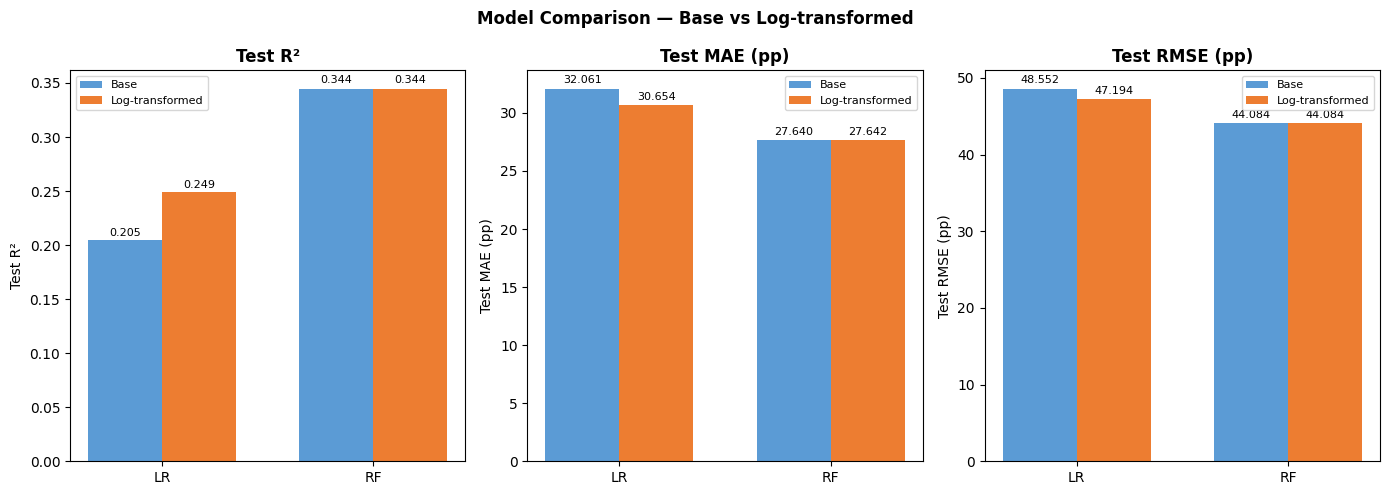

In [93]:
# ── Bar chart ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics_map_log = {
    'Test R²': ([lr_r2, rf_r2], [lr_r2_log, rf_r2_log]),
    'Test MAE (pp)': ([lr_mae,  rf_mae], [lr_mae_log,  rf_mae_log]),
    'Test RMSE (pp)': ([lr_rmse, rf_rmse], [lr_rmse_log, rf_rmse_log]),
}
x = np.arange(2)
w = 0.35

for ax, (metric, (base_vals, log_vals)) in zip(axes, metrics_map_log.items()):
    b1 = ax.bar(x - w/2, base_vals, w, label='Base', color='#5b9bd5')
    b2 = ax.bar(x + w/2, log_vals,  w, label='Log-transformed', color='#ed7d31')
    ax.set_xticks(x)
    ax.set_xticklabels(['LR', 'RF'])
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.legend(fontsize=8)
    for bar in list(b1) + list(b2):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8
        )

plt.suptitle('Model Comparison — Base vs Log-transformed', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('images/model_comparison_s2.png', dpi=150, bbox_inches='tight')

## `Business Narrative`

### Three Key Insights

**1. AI adoption intensity is the signal, not AI presence.**
Tasks split simply into "used AI" vs "did not use AI" show no statistically significant difference in profit margin, confirmed by both Welch's t-test and Mann-Whitney U. The signal only becomes visible above roughly 40-60% AI usage intensity, where margins rise consistently with each bucket. Teams operating at 80–100% AI intensity show median margins approximately 28 percentage points higher than those below 20%. Presence without intensity is not adoption.

**2. Pricing model is the primary structural moderator and it interacts directly with AI.**
`pricing_model_hourly` is the single strongest predictor of `profit_margin` in both the SHAP analysis (mean |SHAP| = 15.23) and the Lasso selection. Under hourly billing, productivity gains from AI reduce billable hours rather than expanding marginL: the value flows to the client, not the business. Fixed-price and value-based contracts capture the same productivity gain as profit. The SHAP dependence plot for `ai_usage_pct` confirms this interaction directly: the positive AI-margin effect is substantially attenuated for hourly-billed tasks and amplified for non-hourly ones.

**3. The feature-margin relationship is real but partially non-linear.**
After correcting for right-skewed features via `log1p`, Linear Regression explains 24.9% of margin variance, with a meaningful gain of +4.4 percentage points over the base model. The Random Forest reaches 34.5% regardless of the transformation, confirming that non-linear interactions persist beyond scale correction. The remaining ~65% of variance is driven by factors outside the dataset: client pricing power, competitive dynamics, and individual worker skill. Aggregate margin improvement from AI is measurable; individual task outcomes will always carry substantial noise.

### Concrete Business Decision

Two levers need to move together for AI adoption to convert into profit. First, teams currently operating below 40% AI usage intensity should be prioritised for structured adoption support: the data shows they are systematically leaving margin on the table relative to high-intensity adopters. 

Second, any adoption push applied to hourly-billed teams must be paired with a contract renegotiation: shifting repeatable, high-AI tasks to fixed-price or retainer structures is the mechanism through which the productivity gain converts to margin rather than being absorbed as a billing reduction. Adopting AI without repricing is, in the current data, revenue-neutral at best.